# EV model fitting — presentation figures

Visualize steps of the EV demand pipeline under the current scenario config
(`utils/EVs/configs/md_2024.yaml`). Later cells can swap charging policies.

1. **Adoption** — NREL conditional P(EV) by FPL / building type / tenure, then Bernoulli sample on ResStock
2. **Profile matching** — NHTS household-first → one inventory vehicle, match-tier fallbacks, and how profiles differ by urban/rural, income, occupants, weekday/weekend. Driven days must **touch home** and **start or end at home** (one-sided open days are kept; both-ends-open and never-home days are dropped as non-EV home-charging patterns). Idle (no-trip-record) vehicle-days are included only when `sampling.include_zero_driving_days_in_match_pool` is true
3. **Annual driving** — replay matched weekday/weekend templates over the config year with time/miles noise; synthetic seam trips reconcile open home/away boundaries and restore missing discharge between adjacent travel days (idle templates → stay-home days)
4. **Battery assignment** — stock-conditional draws sized on **full** temperature-scaled duty miles (same as `ev_demand.py`)
5. **Home-charging fraction** — RECS `Electric_Vehicle_Charge_At_Home` bins → midpoint scalars; scales residential discharge only (Speake et al. 2025 §3.5)
6. **Charger assignment** — ResStock L1 vs L2 from RECS-conditioned TSV among levels that cover **home-attributed** discharge; powers from config (default 1.6 / 7.2 kW)
7. **Charging policies** — single-building charge/discharge, then fleet aggregate hourly load (first week of July), using per-vehicle charger power and home-scaled discharge


In [1]:
import logging
import sys
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

BSF_ROOT = Path("/ebs/home/lily_switch_box/buildstock-fetch")
if str(BSF_ROOT) not in sys.path:
    sys.path.insert(0, str(BSF_ROOT))

from utils.EVs.EVAdoptionSampler import EVAdoptionSampler
from utils.EVs.EVBatteryAssigner import EVBatteryAssigner
from utils.EVs.EVChargerAssigner import (
    EVChargerAssigner,
    RESSTOCK_LEVEL1_CHARGER_KW,
    RESSTOCK_LEVEL2_CHARGER_KW,
)
from utils.EVs.EVHomeChargingFractionAssigner import (
    CHARGE_AT_HOME_BIN_TO_FRACTION,
    CHARGE_AT_HOME_BINS,
    EVHomeChargingFractionAssigner,
)
from utils.EVs.ChargingSimulator import ChargingSimulator
from utils.EVs.NHTSProfileSampler import (
    NHTSProfileSampler,
    VehicleProfile,
    summarize_nhts_match_catalog,
)
from utils.EVs.TripScheduleGenerator import TripScheduleGenerator, iter_travel_day_starts
from utils.EVs.charging import (
    DEFAULT_SOC_MIN_FRACTION,
    DEFAULT_SOC_SAFETY_BUFFER_FRACTION,
    build_hours_base,
)
from utils.EVs.ev_demand import EVDemandCalculator, load_ev_demand_config

from utils.EVs.ev_utils import (
    load_ev_autonomie_params,
    load_ev_battery_lookup,
    load_ev_charge_at_home_lookup,
    load_ev_charger_lookup,
    load_ev_ownership_lookup,
    load_hourly_temp_f_for_buildings,
    load_metadata,
    load_nhts_data,
    load_station_temps_for_buildings,
    load_weather_station_map,
    state_ev_ownership_rate,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

# Presentation colors
COLOR_PINK = "#D86ECC"
COLOR_GREEN = "#3B7D23"


In [2]:
# Scenario config — change this path to compare other states / charging policies later
CONFIG_PATH = BSF_ROOT / "utils/EVs/configs/md_2024.yaml"

config = load_ev_demand_config(CONFIG_PATH)
STATE = config.state
SEED = config.random_state

print(f"state={STATE}  release={config.release}  seed={SEED}")
print(f"ev_assignment={config.ev_assignment}  match_on_vehicles={config.match_on_vehicles}")
print(
    f"include_zero_driving_days_in_match_pool="
    f"{config.include_zero_driving_days_in_match_pool}"
)
print(
    f"nhts_daily_miles_percentile="
    f"{config.nhts_daily_miles_percentile_low:.0f}–"
    f"{config.nhts_daily_miles_percentile_high:.0f}"
)
print(f"charging_strategy={config.charging_strategy}")
print(f"charger_assignment={config.charger_assignment}")
if config.charger_assignment == "resstock":
    print(
        f"level1_charger_power_kw={config.level1_charger_power_kw}  "
        f"level2_charger_power_kw={config.level2_charger_power_kw}  "
        f"charger_buffer_fraction={config.charger_buffer_fraction}"
    )
else:
    print(f"charger_power_kw={config.charger_power_kw}")
print(f"ev_charger: {config.ev_charger_path}")
print(
    f"home_charging_fraction_assignment={config.home_charging_fraction_assignment}"
)
print(f"ev_charge_at_home: {config.ev_charge_at_home_path}")
print(f"temperature_adjustment={config.temperature_adjustment}")
print(f"weather_dir={config.weather_dir}")
print(f"metadata: {config.metadata_path}")
print(f"ev_ownership: {config.ev_ownership_path}")
print(f"nhts: {config.nhts_path}")


state=MD  release=res_2024_tmy3_2  seed=42
ev_assignment=resstock_adoption  match_on_vehicles=False
include_zero_driving_days_in_match_pool=False
nhts_daily_miles_percentile=0–95
charging_strategy=off_peak_immediate
charger_assignment=resstock
level1_charger_power_kw=1.6  level2_charger_power_kw=7.2  charger_buffer_fraction=0.2
ev_charger: /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/resstock_ev_reference/Electric_Vehicle_Charger.tsv
home_charging_fraction_assignment=resstock
ev_charge_at_home: /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/resstock_ev_reference/Electric_Vehicle_Charge_At_Home.tsv
temperature_adjustment=resstock
weather_dir=/ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/res_2024_tmy3_2/weather/MD
metadata: /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/res_2024_tmy3_2/metadata/MD/metadata.parquet
ev_ownership: /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/resstoc

In [3]:
# Core inputs for adoption + NHTS matching (battery tables loaded in §6)
assert config.metadata_path is not None
assert config.ev_ownership_path is not None

metadata_df = load_metadata(config.metadata_path, STATE)
ev_lookup = load_ev_ownership_lookup(config.ev_ownership_path, STATE)
state_rate = state_ev_ownership_rate(ev_lookup, STATE)

print(f"Metadata buildings: {metadata_df.height:,}")
print(f"Occupied: {metadata_df.filter(~pl.col('is_vacant')).height:,}")
print(f"EV lookup rows ({STATE}): {ev_lookup.height:,}")
print(f"PUMS-weighted statewide P(EV): {state_rate:.4f} ({state_rate:.2%})")


Metadata buildings: 9,001
Occupied: 9,001
EV lookup rows (MD): 4,620
PUMS-weighted statewide P(EV): 0.0178 (1.78%)


## Plot helpers

Bar charts of mean P(EV) by FPL / building type / tenure. For each category we show:

- **weighted** — weight-weighted mean (lookup `source_weight`, or ResStock `weight`)
- **unweighted** — simple mean across lookup segments or buildings


In [4]:
FPL_ORDER = ["0-100%", "100-150%", "150-200%", "200-300%", "300-400%", "400%+"]
PLOT_CATEGORIES = ["fpl", "building_type", "tenure"]
PLOT_CATEGORY_LABELS = {
    "fpl": "Federal poverty level",
    "building_type": "Building type",
    "tenure": "Tenure",
}


def ev_prob_summaries(
    df: pl.DataFrame,
    category: str,
    weight_col: str,
    prob_col: str = "ev_ownership_probability",
) -> pl.DataFrame:
    """Conditional = weight-weighted mean P(EV); categorical = unweighted mean."""
    data = df.filter(
        (pl.col("tenure") != "Not Available")
        & (pl.col("fpl") != "Not Available")
        & (pl.col(category) != "Not Available")
    )
    prob = pl.col(prob_col).cast(pl.Float64)
    return data.group_by(category).agg(
        ((prob * pl.col(weight_col)).sum() / pl.col(weight_col).sum()).alias("conditional_p_ev"),
        prob.mean().alias("categorical_p_ev"),
        pl.col(weight_col).sum().alias("total_weight"),
        pl.len().alias("n"),
    )


def ev_distribution_summaries(
    df: pl.DataFrame,
    category: str,
    weight_col: str,
    *,
    has_ev_col: str = "has_ev",
) -> pl.DataFrame:
    """Share of sampled EVs in each category (composition of the EV fleet).

    Includes every category present in the eligible building stock, with
    zero height / n_evs=0 when no EVs were assigned to that category.
    """
    eligible = df.filter(
        (pl.col("tenure") != "Not Available")
        & (pl.col("fpl") != "Not Available")
        & (pl.col(category) != "Not Available")
    )
    # Keep FPL axis stable even if a bin is missing from this sample
    if category == "fpl":
        all_cats = pl.DataFrame({category: FPL_ORDER})
    else:
        all_cats = eligible.select(category).unique()

    evs = eligible.filter(pl.col(has_ev_col).cast(pl.Boolean))
    total_n = evs.height
    total_w = float(evs[weight_col].sum()) if total_n else 0.0
    summary = evs.group_by(category).agg(
        pl.len().alias("n_evs"),
        pl.col(weight_col).sum().alias("ev_weight"),
    )
    summary = all_cats.join(summary, on=category, how="left").with_columns(
        pl.col("n_evs").fill_null(0),
        pl.col("ev_weight").fill_null(0.0),
    )
    if total_n == 0:
        return summary.with_columns(
            pl.lit(0.0).alias("share_unweighted"),
            pl.lit(0.0).alias("share_weighted"),
        )
    return summary.with_columns(
        (pl.col("n_evs") / total_n).alias("share_unweighted"),
        (pl.col("ev_weight") / total_w).alias("share_weighted"),
    )


def _sort_summary(summary: pl.DataFrame, category: str) -> pl.DataFrame:
    if category == "fpl":
        order = {v: i for i, v in enumerate(FPL_ORDER)}
        return summary.sort(pl.col(category).replace(order))
    return summary.sort(category)


def plot_ev_probs_by_category(
    df: pl.DataFrame,
    *,
    weight_col: str,
    title: str,
    prob_col: str = "ev_ownership_probability",
    color: str = "#D86ECC",
) -> None:
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, y=1.01)

    for row, category in enumerate(PLOT_CATEGORIES):
        summary = _sort_summary(ev_prob_summaries(df, category, weight_col, prob_col), category)
        labels = summary[category].to_list()
        x = range(len(labels))

        panels = [
            ("conditional_p_ev", f"P(EV | {PLOT_CATEGORY_LABELS[category]}) — weighted"),
            ("categorical_p_ev", f"P(EV | {PLOT_CATEGORY_LABELS[category]}) — unweighted mean"),
        ]
        for col, (metric, subtitle) in enumerate(panels):
            ax = axes[row, col]
            vals = summary[metric].to_numpy()
            bars = ax.bar(x, vals, color=color)
            ax.set_ylabel("P(EV)")
            ax.set_title(subtitle, fontsize=10)
            ax.set_xticks(list(x))
            ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
            for bar, val in zip(bars, vals, strict=False):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{val:.1%}",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

    fig.tight_layout()
    plt.show()


def plot_ev_distribution_by_category(
    df: pl.DataFrame,
    *,
    weight_col: str,
    title: str,
    has_ev_col: str = "has_ev",
    color: str = "#D86ECC",
) -> None:
    """Bar charts of EV fleet composition by FPL / building type / tenure."""
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(title, fontsize=14, y=1.01)

    for row, category in enumerate(PLOT_CATEGORIES):
        summary = _sort_summary(
            ev_distribution_summaries(df, category, weight_col, has_ev_col=has_ev_col),
            category,
        )
        labels = summary[category].to_list()
        x = range(len(labels))

        panels = [
            ("share_weighted", f"Share of EVs by {PLOT_CATEGORY_LABELS[category]} — weighted"),
            ("share_unweighted", f"Share of EVs by {PLOT_CATEGORY_LABELS[category]} — unweighted"),
        ]
        for col, (metric, subtitle) in enumerate(panels):
            ax = axes[row, col]
            vals = summary[metric].to_numpy()
            bars = ax.bar(x, vals, color=color)
            ax.set_ylabel("Share of EVs")
            ax.set_title(subtitle, fontsize=10)
            ax.set_xticks(list(x))
            ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
            for bar, val, n in zip(bars, vals, summary["n_evs"].to_list(), strict=False):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{val:.0%}\n(n={n})",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                )

    fig.tight_layout()
    plt.show()


## 1. NREL lookup adoption rates

Conditional P(EV) from `Electric_Vehicle_Ownership.tsv`, filtered to this config's state.
Occupied segments only (`tenure != Not Available`).


P(EV) range: 0.0000 – 0.0912


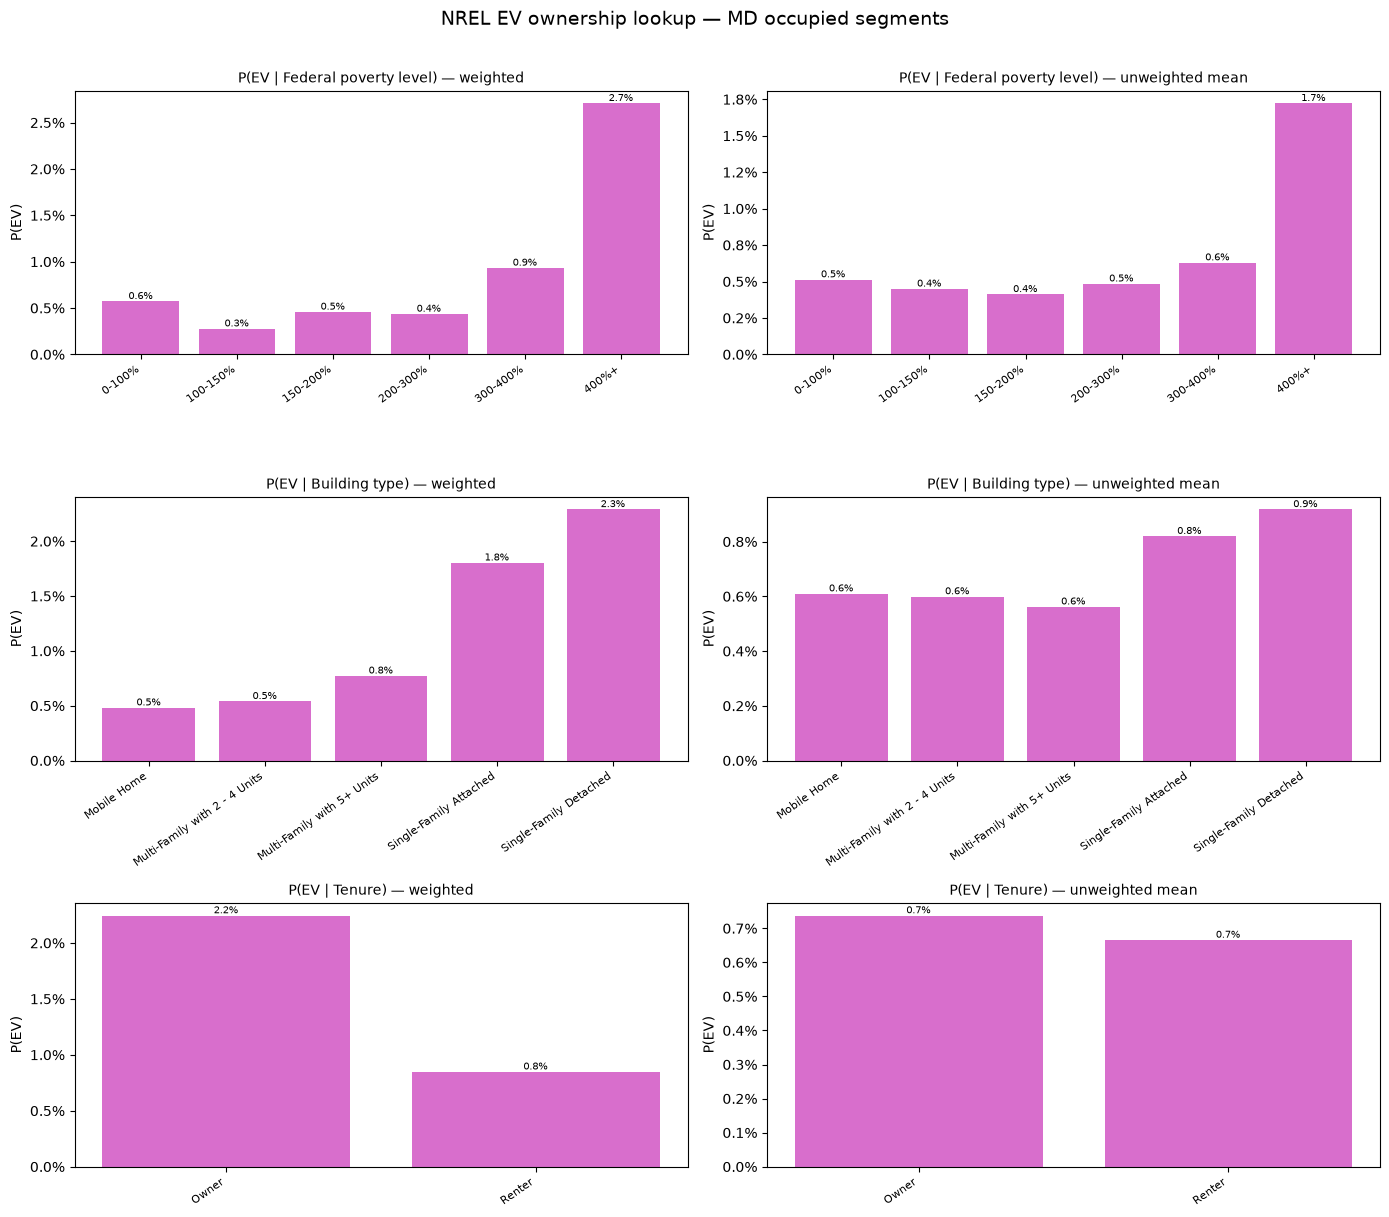

In [5]:
md_lookup_occupied = ev_lookup.filter(pl.col("tenure") != "Not Available")

print(
    f"P(EV) range: {md_lookup_occupied['ev_ownership_probability'].min():.4f}"
    f" – {md_lookup_occupied['ev_ownership_probability'].max():.4f}"
)

plot_ev_probs_by_category(
    md_lookup_occupied,
    weight_col="source_weight",
    title=f"NREL EV ownership lookup — {STATE} occupied segments",
    color="#D86ECC",
)


## 2. ResStock 2024 sample — joined P(EV) and Bernoulli draws

Join the same lookup onto MD ResStock buildings, then sample 0/1 EV ownership with
`EVAdoptionSampler` (same path as `ev_assignment: resstock_adoption` in the config).

ResStock 2024 metadata does not ship a realized `in.electric_vehicle_ownership` column
(that appears in the 2025 quota-sampled release), so “sampled” here is our Bernoulli draw
on the 2024 building stock.


In [6]:
sampler = EVAdoptionSampler(ev_ownership_df=ev_lookup, random_state=SEED)
bldg_ev = sampler.sample(metadata_df).with_columns(
    (pl.col("evs") == 1).alias("has_ev"),
)

occupied = bldg_ev.filter(~pl.col("is_vacant"))
print(f"Occupied buildings: {occupied.height:,}")
print(f"Mean P(EV) (occupied): {occupied['ev_ownership_probability'].mean():.4f}")
print(f"Expected EVs (sum P): {occupied['ev_ownership_probability'].sum():.1f}")
print(f"EVs sampled: {int(bldg_ev['evs'].sum()):,}")
print(f"Sample adoption rate (occupied): {occupied['has_ev'].mean():.4f}")


Occupied buildings: 9,001
Mean P(EV) (occupied): 0.0184
Expected EVs (sum P): 165.2
EVs sampled: 178
Sample adoption rate (occupied): 0.0198


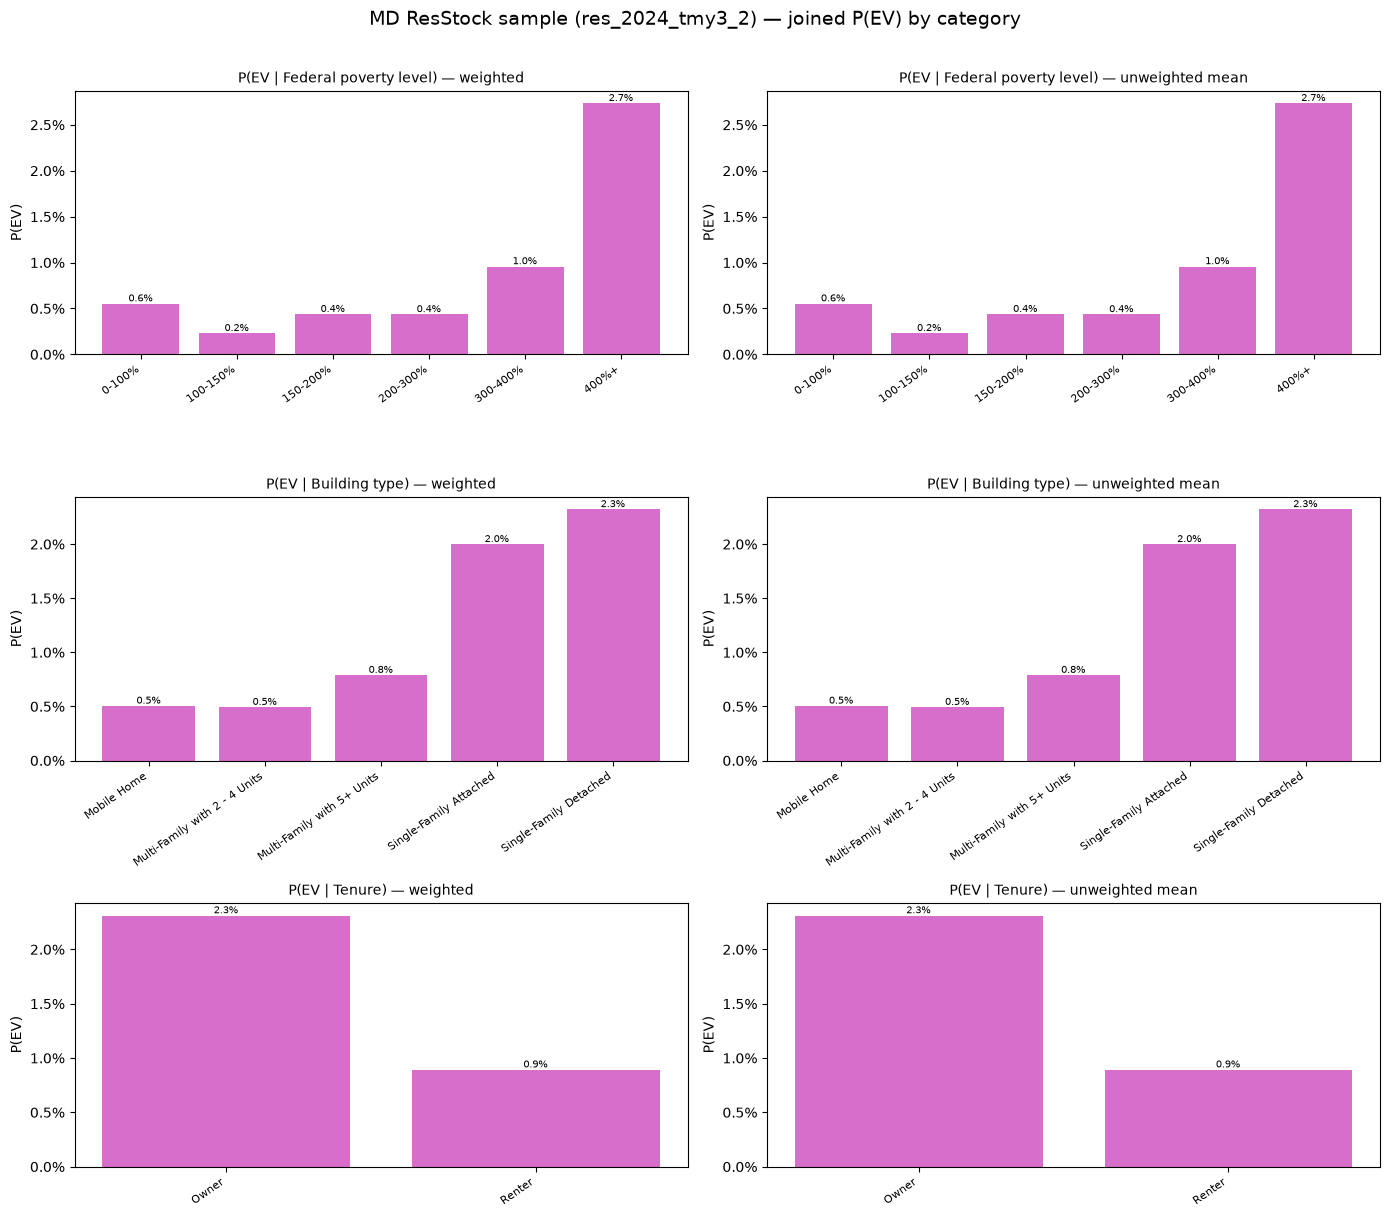

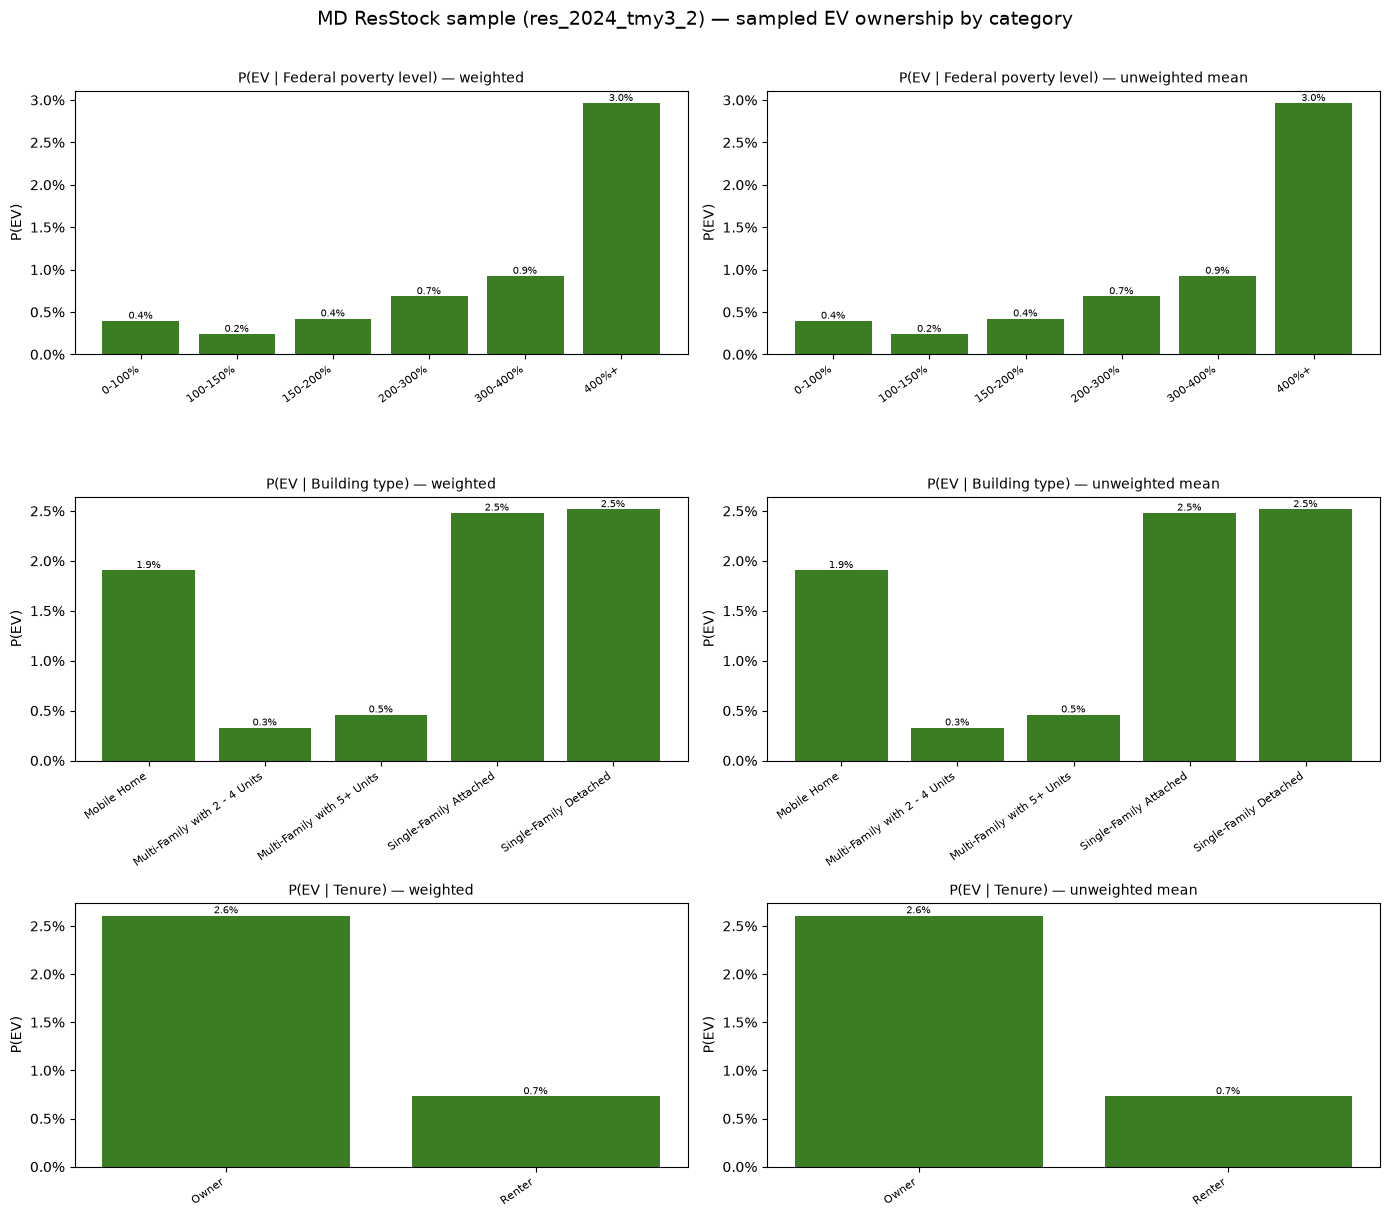

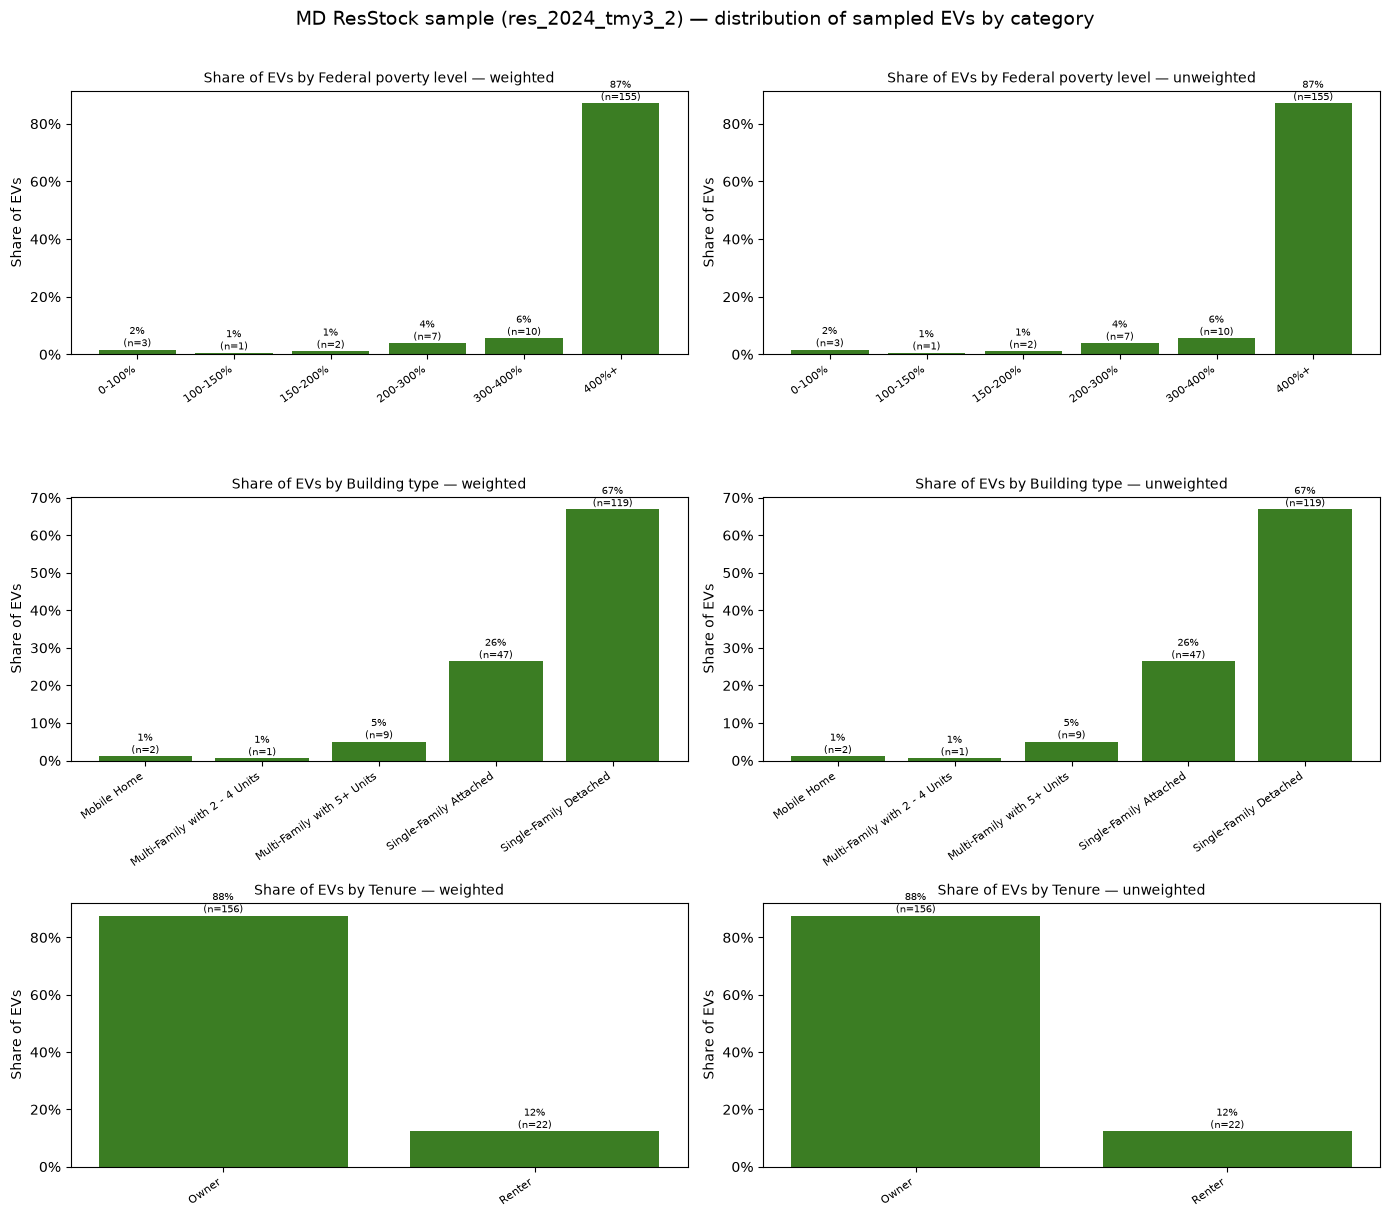

In [7]:
# Expected rates on the ResStock building mix (joined lookup P(EV))
plot_ev_probs_by_category(
    bldg_ev,
    weight_col="weight",
    prob_col="ev_ownership_probability",
    title=f"MD ResStock sample ({config.release}) — joined P(EV) by category",
    color="#D86ECC",
)

# Realized rates after Bernoulli sampling
plot_ev_probs_by_category(
    bldg_ev,
    weight_col="weight",
    prob_col="has_ev",
    title=f"MD ResStock sample ({config.release}) — sampled EV ownership by category",
    color="#3B7D23",
)

# Composition of the sampled EV fleet (share of EVs in each category)
plot_ev_distribution_by_category(
    bldg_ev,
    weight_col="weight",
    title=f"MD ResStock sample ({config.release}) — distribution of sampled EVs by category",
    color="#3B7D23",
)


### ResStock 2025 MD — NREL quota-sampled EV composition

ResStock **2025** ships `in.electric_vehicle_ownership` (quota sample). Load the MD upgrade-0
metadata and plot the same FPL / building type / tenure **fleet composition** for NREL’s
assigned EVs (pink), for comparison with our Bernoulli draws on the 2024 stock above.


ResStock 2025 metadata: /ebs/data/nrel/resstock/res_2025_amy2018_1/metadata/state=MD/upgrade=00/metadata.parquet
Occupied buildings: 8,954
NREL EVs (in.electric_vehicle_ownership=Yes): 127
Sample adoption rate (occupied): 0.0142


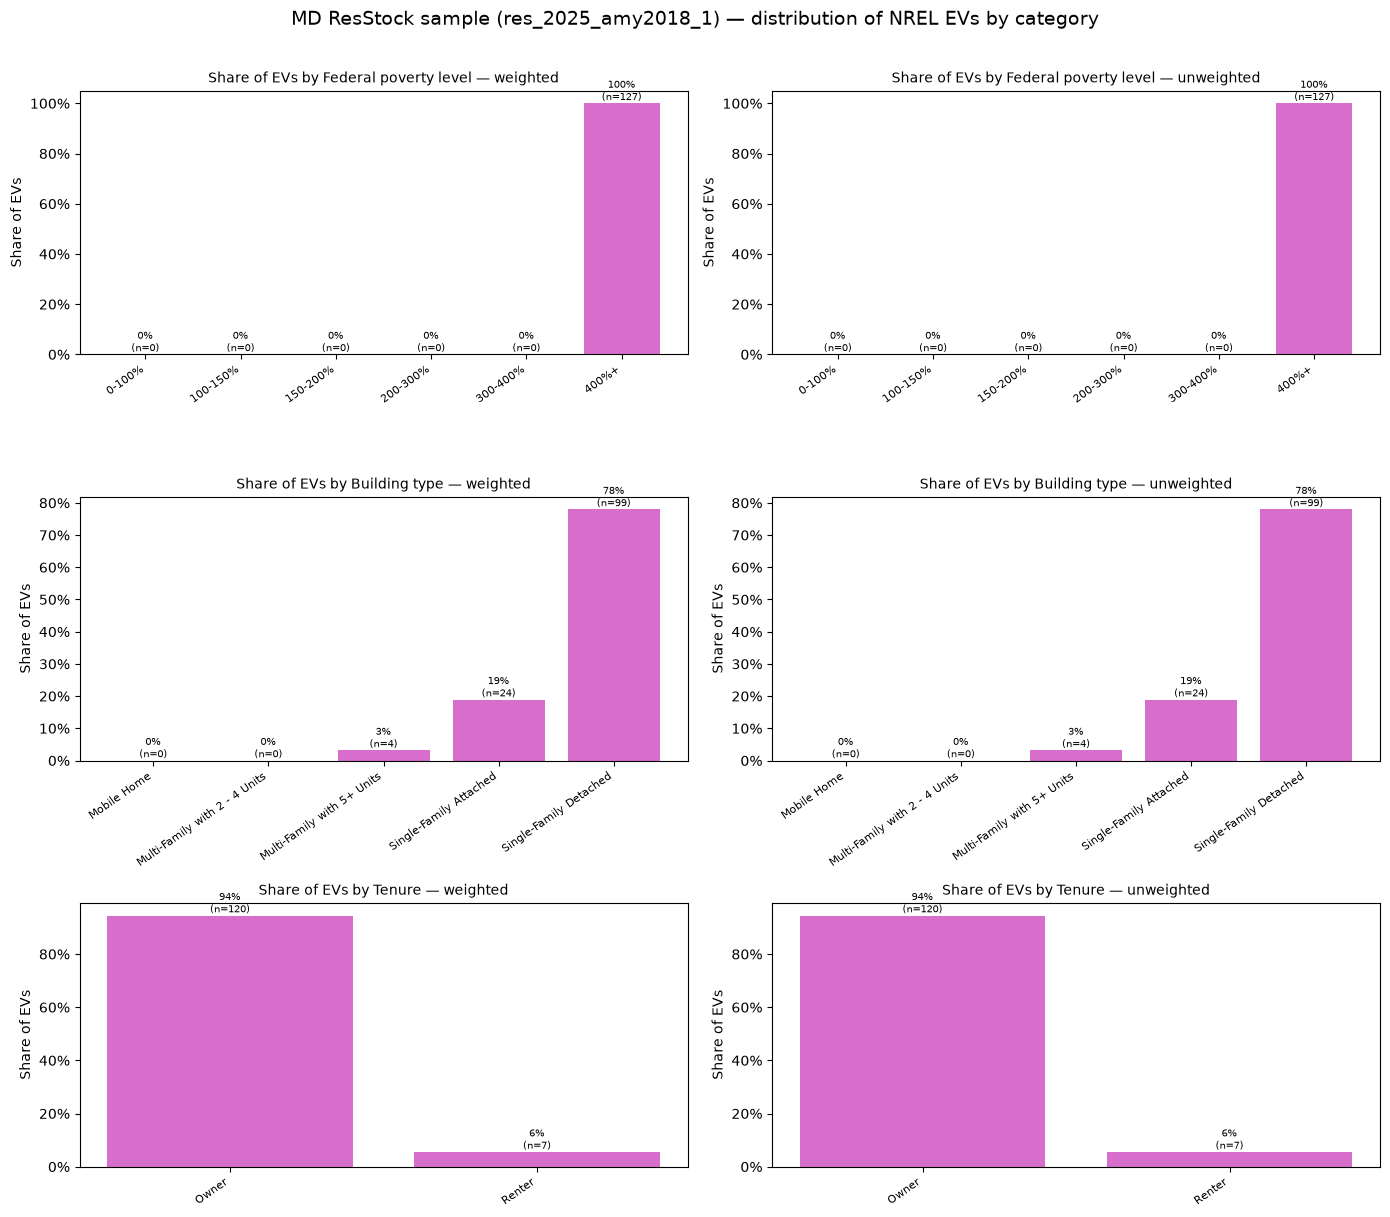

In [8]:
RELEASE_2025 = "res_2025_amy2018_1"
PATH_METADATA_2025 = (
    Path("/ebs/data/nrel/resstock")
    / RELEASE_2025
    / "metadata"
    / f"state={STATE}"
    / "upgrade=00"
    / "metadata.parquet"
)
print(f"ResStock 2025 metadata: {PATH_METADATA_2025}")

# Same category columns as 2024 via load_metadata; attach NREL's realized EV flag
metadata_2025 = load_metadata(str(PATH_METADATA_2025), STATE)
nrel_ev_flag = (
    pl.scan_parquet(PATH_METADATA_2025)
    .filter(pl.col("in.state") == STATE)
    .select(
        "bldg_id",
        (pl.col("in.electric_vehicle_ownership") == "Yes").alias("has_ev"),
    )
    .collect()
)
bldg_ev_2025 = metadata_2025.join(nrel_ev_flag, on="bldg_id", how="left")

occupied_2025 = bldg_ev_2025.filter(~pl.col("is_vacant"))
n_evs_2025 = int(bldg_ev_2025["has_ev"].sum())
print(f"Occupied buildings: {occupied_2025.height:,}")
print(f"NREL EVs (in.electric_vehicle_ownership=Yes): {n_evs_2025:,}")
print(f"Sample adoption rate (occupied): {occupied_2025['has_ev'].mean():.4f}")

plot_ev_distribution_by_category(
    bldg_ev_2025,
    weight_col="weight",
    title=f"MD ResStock sample ({RELEASE_2025}) — distribution of NREL EVs by category",
    color="#D86ECC",
)


In [9]:
def adoption_summary_table(df: pl.DataFrame, *group_cols: str) -> pl.DataFrame:
    """Tabular companion to the bar charts (occupied buildings only)."""
    return (
        df.filter(~pl.col("is_vacant"))
        .group_by(*group_cols)
        .agg(
            pl.len().alias("n_buildings"),
            pl.col("ev_ownership_probability").mean().round(4).alias("mean_p_ev"),
            pl.col("evs").sum().alias("n_evs_assigned"),
            (pl.col("evs").sum() / pl.len()).round(4).alias("sample_adoption_rate"),
        )
        .sort(*group_cols)
    )


for col, label in [("fpl", "FPL"), ("building_type", "building type"), ("tenure", "tenure")]:
    print(f"\nBy {label}")
    display(adoption_summary_table(bldg_ev, col))



By FPL


fpl,n_buildings,mean_p_ev,n_evs_assigned,sample_adoption_rate
str,u32,f64,i64,f64
"""0-100%""",762,0.0055,3,0.0039
"""100-150%""",420,0.0023,1,0.0024
"""150-200%""",476,0.0044,2,0.0042
"""200-300%""",1025,0.0043,7,0.0068
"""300-400%""",1083,0.0096,10,0.0092
"""400%+""",5235,0.0273,155,0.0296



By building type


building_type,n_buildings,mean_p_ev,n_evs_assigned,sample_adoption_rate
str,u32,f64,i64,f64
"""Mobile Home""",105,0.005,2,0.019
"""Multi-Family with 2 - 4 Units""",305,0.0049,1,0.0033
"""Multi-Family with 5+ Units""",1964,0.0079,9,0.0046
"""Single-Family Attached""",1895,0.02,47,0.0248
"""Single-Family Detached""",4732,0.0232,119,0.0251



By tenure


tenure,n_buildings,mean_p_ev,n_evs_assigned,sample_adoption_rate
str,u32,f64,i64,f64
"""Owner""",5983,0.0231,156,0.0261
"""Renter""",3018,0.0089,22,0.0073


## 3. NHTS vehicle-profile matching

`load_nhts_data` builds a match pool from **vehicle-owning households** × light-duty
inventory vehicles (households + vehicles files). Driven days require OUTOFTWN +
**touching home at least once** (any `WHYFROM` / `WHYTO` ∈ {1, 2}). Open days that
start and/or end away from home are kept — they bring night-shift and overnight-away
patterns into the pool. Days that **never** visit home are dropped (no residential
charging opportunity). Owned vehicles with **no trip records** that survey day become
idle markers (`is_empty_day=True` → home all day, 0 miles) only when
`sampling.include_zero_driving_days_in_match_pool` is true (trip records that report
0 miles stay either way).

When open templates are replayed across adjacent travel days, `TripScheduleGenerator`
imputes a **synthetic seam trip** between the last observed trip arrival and the next
day's first departure. Miles and duration mirror the opposite observed edge of the same
tour (after time offsets); the trip midpoint follows midpoint-centered triangular weights
over the feasible gap. If mirrored duration exceeds the gap, duration is clamped but miles
are kept. Synthetic miles contribute to discharge and peak-daily-mile battery sizing.
Rows are marked with `is_synthetic_trip=True` (`synthetic_seam_kind`,
`synthetic_duration_clamped` for auditing).

The loader then applies the config **daily-miles percentile** band (e.g. 0–95):
percentiles are computed over **driven** profiles only (`~is_empty_day`), so idle markers
do not drag the cut down. Included idle templates bypass the band; driven days outside
it are dropped.

Under `ev_assignment: resstock_adoption` we do **not** match on vehicle count. Matching is
**household-first**: draw a demographically similar NHTS household, then pick one of its
eligible inventory vehicles. `load_nhts_data` / `load_metadata` store income as
three bins (≤$50k / $50–150k / $150k+) and occupants as 1 / 2 / 3+. Weekday and weekend
are matched independently (each NHTS HH has one `TRAVDAY`) with this cascade (urban/rural
first; prefer occupants over income when dropping a dimension):

1. `urban_income_occupants` — urban/rural + income + occupants (**best / “exact” for this mode**)
2. `urban_occupants` — drop income, keep urban/rural + occupants
3. `urban_income` — drop occupants, keep urban/rural + income
4. `income_occupants` — drop urban/rural
5. `income` — income bucket only

If none of these tiers has enough profiles, matching raises an error rather than borrowing from another income bin.


In [10]:
nhts_df = load_nhts_data(
    config.nhts_path,
    STATE,
    daily_miles_percentile_low=config.nhts_daily_miles_percentile_low,
    daily_miles_percentile_high=config.nhts_daily_miles_percentile_high,
    include_zero_driving_days_in_match_pool=config.include_zero_driving_days_in_match_pool,
)
n_empty_pool = int(nhts_df.filter(pl.col("is_empty_day")).height)
n_driven_legs = int(nhts_df.filter(~pl.col("is_empty_day")).height)
n_profiles = nhts_df.select("hh_vehicle_id", "weekday").unique().height
n_driven_profiles = (
    nhts_df.filter(~pl.col("is_empty_day")).select("hh_vehicle_id", "weekday").unique().height
)
print(
    f"NHTS match pool ({STATE} census division): {nhts_df.height:,} rows  "
    f"({n_driven_legs:,} driven trip legs, {n_empty_pool:,} empty vehicle-days)  "
    f"across {nhts_df['hh_vehicle_id'].n_unique():,} vehicles / "
    f"{nhts_df['house_id'].n_unique():,} households\n"
    f"Trip profiles: {n_profiles:,}  "
    f"(driven={n_driven_profiles:,}, empty={n_empty_pool:,})\n"
    f"include_zero_driving_days_in_match_pool="
    f"{config.include_zero_driving_days_in_match_pool}; "
    f"daily-miles percentile {config.nhts_daily_miles_percentile_low:.0f}–"
    f"{config.nhts_daily_miles_percentile_high:.0f} over driven profiles"
)

# Open vs closed home boundaries (home-touch + both-ends-open filters).
# start-away/end-away should be 0 after the both-ends-open exclusion.
driven_days = (
    nhts_df.filter(~pl.col("is_empty_day"))
    .sort(["hh_vehicle_id", "weekday", "start_time", "seq_trip_id"])
    .group_by(["hh_vehicle_id", "weekday"])
    .agg(
        pl.col("why_from").first().is_in([1, 2]).alias("starts_home"),
        pl.col("why_to").last().is_in([1, 2]).alias("ends_home"),
        (
            pl.col("why_from").is_in([1, 2]).any()
            | pl.col("why_to").is_in([1, 2]).any()
        ).alias("touches_home"),
    )
)
n_open = int(driven_days.filter(~(pl.col("starts_home") & pl.col("ends_home"))).height)
n_closed = int(driven_days.filter(pl.col("starts_home") & pl.col("ends_home")).height)
print(
    f"\nDriven vehicle-days by home boundary: closed={n_closed:,}, open={n_open:,} "
    f"({n_open / max(driven_days.height, 1):.1%} open)\n"
    f"  start-home/end-away="
    f"{driven_days.filter(pl.col('starts_home') & ~pl.col('ends_home')).height:,}, "
    f"start-away/end-home="
    f"{driven_days.filter(~pl.col('starts_home') & pl.col('ends_home')).height:,}, "
    f"start-away/end-away="
    f"{driven_days.filter(~pl.col('starts_home') & ~pl.col('ends_home')).height:,}\n"
    f"All driven days touch home: {bool(driven_days['touches_home'].all())}"
)

nhts_sampler = NHTSProfileSampler(
    nhts_df=nhts_df,
    match_on_vehicles=config.match_on_vehicles,
    random_state=SEED,
)

# Only buildings with a sampled EV need a profile
bldg_vehicles = bldg_ev.filter(pl.col("evs") > 0).with_columns(pl.col("evs").alias("vehicles"))
print(f"Buildings with EV to match: {bldg_vehicles.height:,}")

vehicle_profiles, nhts_match_catalog = nhts_sampler.sample(bldg_vehicles, return_catalog=True)
print(f"Vehicle profiles sampled: {len(vehicle_profiles):,}")

# Empty weekday/weekend templates are intentional idle days when the pool includes them.
print("\nMatch catalog summary (empty profiles = owned but not driven that survey day)")
display(summarize_nhts_match_catalog(nhts_match_catalog))
n_slots = nhts_match_catalog.height
n_empty_wd = int((~nhts_match_catalog["has_weekday_trips"]).sum())
n_empty_we = int((~nhts_match_catalog["has_weekend_trips"]).sum())
print(
    f"Matched empty weekday templates: {n_empty_wd:,} / {n_slots:,} "
    f"({n_empty_wd / n_slots:.1%})\n"
    f"Matched empty weekend templates: {n_empty_we:,} / {n_slots:,} "
    f"({n_empty_we / n_slots:.1%})"
)


2026-08-09 00:46:07,244 - INFO - NHTS households (division 5, HHVEHCNT>0): 1491
2026-08-09 00:46:07,249 - INFO - NHTS light-duty vehicle-days (owner HH × inventory): 2727 vehicles across 1487 HH
2026-08-09 00:46:07,268 - INFO - NHTS OUTOFTWN filter (keep 02=not away entire day): 3946/3979 driver trip rows retained
2026-08-09 00:46:07,270 - INFO - NHTS home-touch filter (any WHYFROM or WHYTO in [1, 2]): 3929/3946 trip rows, 1362 vehicles with usable driven days
2026-08-09 00:46:07,272 - INFO - NHTS vehicle-day split: 1362 usable driven, 1343 empty (idle), 22 excluded (had driver trips but failed OUTOFTWN/home-touch)
2026-08-09 00:46:07,273 - INFO - NHTS match pool: 3929 rows (3929 driven trip legs, 0 empty vehicle-days) across 1362 vehicles / 1085 households
2026-08-09 00:46:07,276 - INFO - NHTS daily-miles percentile filter [0.0, 95.0] over driven profiles: kept 1294/1362 driven (miles band [0.0, 102.2]) + 0 empty = 1294/1362 profiles, 3735/3929 trip rows
2026-08-09 00:46:07,281 - INFO

NHTS match pool (MD census division): 3,735 rows  (3,735 driven trip legs, 0 empty vehicle-days)  across 1,294 vehicles / 1,039 households
Trip profiles: 1,294  (driven=1,294, empty=0)
include_zero_driving_days_in_match_pool=False; daily-miles percentile 0–95 over driven profiles

Driven vehicle-days by home boundary: closed=1,143, open=151 (11.7% open)
  start-home/end-away=90, start-away/end-home=51, start-away/end-away=10
All driven days touch home: True
Buildings with EV to match: 178


2026-08-09 00:46:07,497 - INFO - Building progress: 178/178 (100.0%)
2026-08-09 00:46:07,498 - INFO - Generated 178 vehicle profiles from 178 buildings


Vehicle profiles sampled: 178

Match catalog summary (empty profiles = owned but not driven that survey day)


metric,count,share_of_vehicle_slots
str,i64,f64
"""vehicle_slots""",178,1.0
"""missing_nhts_vehicle_match""",0,0.0
"""empty_weekday_trip_profile""",0,0.0
"""empty_weekend_trip_profile""",0,0.0
"""empty_both_trip_profiles""",0,0.0


Matched empty weekday templates: 0 / 178 (0.0%)
Matched empty weekend templates: 0 / 178 (0.0%)


In [11]:
# Tier order for resstock_adoption (match_on_vehicles=False); pums_vehicles adds "exact" first
MATCH_TIER_ORDER = {
    "exact": 0,
    "urban_income_occupants": 1,
    "urban_occupants": 2,
    "urban_income": 3,
    "income_occupants": 4,
    "income": 5,
}
MATCH_TIER_LABEL = {
    0: "tier 0 — exact (incl. vehicles; pums_vehicles only)",
    1: "tier 1 — urban + income + occupants",
    2: "tier 2 — urban + occupants",
    3: "tier 3 — urban + income",
    4: "tier 4 — income + occupants",
    5: "tier 5 — income only",
}

match_tier_report = (
    nhts_match_catalog.with_columns(
        pl.col("weekday_match_type").replace_strict(MATCH_TIER_ORDER, default=7).alias("weekday_tier"),
        pl.col("weekend_match_type").replace_strict(MATCH_TIER_ORDER, default=7).alias("weekend_tier"),
    ).with_columns(
        pl.max_horizontal("weekday_tier", "weekend_tier").alias("max_tier"),
        ((pl.col("weekday_tier") == 1) & (pl.col("weekend_tier") == 1)).alias("both_days_exact"),
    )
)

# With empties off / resstock_adoption, "best" means tier 1 on both days.
best_tier = 0 if config.match_on_vehicles else 1
n_slots = match_tier_report.height
n_both_exact = match_tier_report.filter(
    (pl.col("weekday_tier") == best_tier) & (pl.col("weekend_tier") == best_tier)
).height
n_any_fallback = match_tier_report.filter(pl.col("max_tier") > best_tier).height
print(f"EV slots: {n_slots:,}  (match_on_vehicles={config.match_on_vehicles})")
print(
    f"  Best tier on both weekday and weekend: {n_both_exact:,} "
    f"({n_both_exact / n_slots:.1%})"
)
print(
    f"  Any fallback (worse than best on at least one day): {n_any_fallback:,} "
    f"({n_any_fallback / n_slots:.1%})"
)


def match_type_table(col: str) -> pl.DataFrame:
    return (
        nhts_match_catalog.group_by(col)
        .agg(pl.len().alias("vehicle_slots"))
        .with_columns(
            pl.col(col).replace_strict(MATCH_TIER_ORDER, default=7).alias("tier"),
            (pl.col("vehicle_slots") / n_slots).round(4).alias("share_of_vehicle_slots"),
            pl.col(col)
            .replace_strict(MATCH_TIER_ORDER, default=7)
            .replace_strict(MATCH_TIER_LABEL)
            .alias("match_tier"),
        )
        .sort("tier")
        .select("match_tier", col, "vehicle_slots", "share_of_vehicle_slots")
    )


print("\nBy weekday match tier")
display(match_type_table("weekday_match_type"))

print("\nBy weekend match tier")
display(match_type_table("weekend_match_type"))

print("\nBy worst tier needed per slot (max of weekday / weekend)")
display(
    match_tier_report.group_by("max_tier")
    .agg(pl.len().alias("vehicle_slots"))
    .with_columns(
        (pl.col("vehicle_slots") / n_slots).round(4).alias("share_of_vehicle_slots"),
        pl.col("max_tier").replace_strict(MATCH_TIER_LABEL).alias("match_tier"),
    )
    .sort("max_tier")
    .select("match_tier", "max_tier", "vehicle_slots", "share_of_vehicle_slots")
)

print("\nWeekday × weekend match type")
display(
    nhts_match_catalog.group_by("weekday_match_type", "weekend_match_type")
    .agg(pl.len().alias("vehicle_slots"))
    .with_columns((pl.col("vehicle_slots") / n_slots).round(4).alias("share"))
    .sort("vehicle_slots", descending=True)
)


EV slots: 178  (match_on_vehicles=False)
  Best tier on both weekday and weekend: 178 (100.0%)
  Any fallback (worse than best on at least one day): 0 (0.0%)

By weekday match tier


match_tier,weekday_match_type,vehicle_slots,share_of_vehicle_slots
str,str,u32,f64
"""tier 1 — urban + income + occu…","""urban_income_occupants""",178,1.0



By weekend match tier


match_tier,weekend_match_type,vehicle_slots,share_of_vehicle_slots
str,str,u32,f64
"""tier 1 — urban + income + occu…","""urban_income_occupants""",178,1.0



By worst tier needed per slot (max of weekday / weekend)


match_tier,max_tier,vehicle_slots,share_of_vehicle_slots
str,i64,u32,f64
"""tier 1 — urban + income + occu…",1,178,1.0



Weekday × weekend match type


weekday_match_type,weekend_match_type,vehicle_slots,share
str,str,u32,f64
"""urban_income_occupants""","""urban_income_occupants""",178,1.0


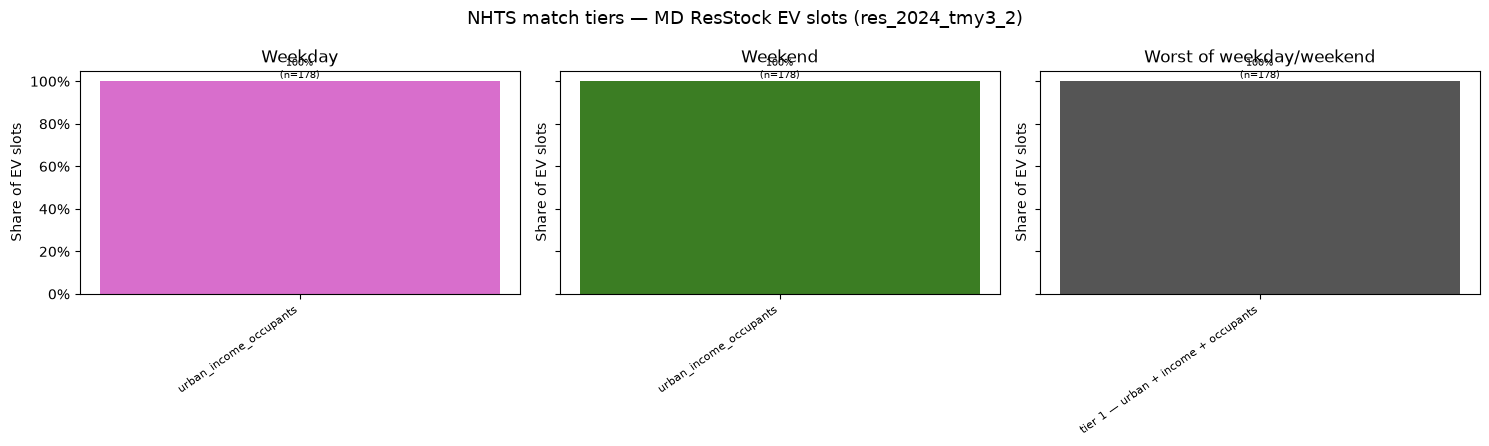

In [12]:
def _match_type_counts(col: str) -> pl.DataFrame:
    return (
        nhts_match_catalog.group_by(col)
        .agg(pl.len().alias("vehicle_slots"))
        .with_columns(
            pl.col(col).replace_strict(MATCH_TIER_ORDER, default=7).alias("tier"),
            (pl.col("vehicle_slots") / n_slots).alias("share"),
        )
        .sort("tier")
    )


weekday_counts = _match_type_counts("weekday_match_type")
weekend_counts = _match_type_counts("weekend_match_type")
worst_counts = (
    match_tier_report.group_by("max_tier")
    .agg(pl.len().alias("vehicle_slots"))
    .with_columns((pl.col("vehicle_slots") / n_slots).alias("share"))
    .sort("max_tier")
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
fig.suptitle(f"NHTS match tiers — {STATE} ResStock EV slots ({config.release})", fontsize=13)

panels = [
    (axes[0], weekday_counts, "weekday_match_type", "Weekday", COLOR_PINK),
    (axes[1], weekend_counts, "weekend_match_type", "Weekend", COLOR_GREEN),
    (axes[2], worst_counts, "max_tier", "Worst of weekday/weekend", "#555555"),
]
for ax, summary, label_col, title, color in panels:
    if label_col == "max_tier":
        labels = [MATCH_TIER_LABEL[t] for t in summary["max_tier"].to_list()]
    else:
        labels = summary[label_col].to_list()
    shares = summary["share"].to_numpy()
    x = range(len(labels))
    bars = ax.bar(x, shares, color=color)
    ax.set_title(title)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Share of EV slots")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    for bar, share, n in zip(bars, shares, summary["vehicle_slots"].to_list(), strict=False):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{share:.0%}\n(n={n})",
            ha="center",
            va="bottom",
            fontsize=7,
        )

fig.tight_layout()
plt.show()


## 4. How NHTS driving profiles differ

Stats on the **match pool** returned by `load_nhts_data` (census division, optional idle
markers, home-touch + both-ends-open filters, and daily-miles percentile over driven
profiles). Each observation is one surveyed vehicle–day (weekday or weekend). Days must
touch home and **start or end at home**; both-ends-open diaries are dropped as non-EV
home-charging patterns. Idle no-trip-record days appear only when
`include_zero_driving_days_in_match_pool` is true. Miles / trip comparisons below use
driven days only.


In [13]:
INCOME_LABELS = {
    1: "≤$50k",
    2: "$50–150k",
    3: "$150k+",
}
URBAN_LABELS = {1: "Urban", 2: "Rural"}
# load_nhts_data / load_metadata already cap occupants at 3, so bin 3 means "3+"
OCCUPANTS_LABELS = {1: "1", 2: "2", 3: "3+"}

# Use the percentile-filtered pool from load_nhts_data (same frame the sampler matches against)
nhts_pool = nhts_df

# One row per (vehicle, day type): sum miles over trip legs; empty markers → 0 miles / 0 trips.
vehicle_day = (
    nhts_pool.group_by(
        "hh_vehicle_id", "vehicle_id", "weekday", "urban", "income_bucket", "occupants"
    )
    .agg(
        pl.col("miles_driven").fill_null(0.0).sum().alias("daily_miles"),
        # Count real trip legs only (empty markers have null start_time).
        pl.col("start_time").is_not_null().sum().alias("n_trips"),
        pl.col("is_empty_day").max().alias("is_empty_day"),
    )
    .with_columns(
        pl.when(pl.col("weekday") == 2).then(pl.lit("weekday")).otherwise(pl.lit("weekend")).alias("day_type"),
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        pl.col("income_bucket").replace_strict(INCOME_LABELS).alias("income_label"),
        pl.col("occupants").replace_strict(OCCUPANTS_LABELS).alias("occupants_bin"),
    )
)

# Driven-only view for miles / trip comparisons (empty days would pile up at 0 miles).
vehicle_day_driven = vehicle_day.filter(~pl.col("is_empty_day"))

print(
    f"NHTS vehicle-days in match pool: {vehicle_day.height:,}  "
    f"(empty={int(vehicle_day['is_empty_day'].sum()):,}, "
    f"driven={vehicle_day_driven.height:,})"
)
print("Pool composition by day type (incl. empty share):")
print(
    vehicle_day.group_by("day_type")
    .agg(
        pl.len().alias("n_vehicle_days"),
        pl.col("is_empty_day").sum().alias("n_empty"),
        pl.col("is_empty_day").mean().round(3).alias("empty_share"),
        pl.col("daily_miles").mean().round(1).alias("mean_miles_incl_empty"),
    )
    .sort("day_type")
)
print("\nDriven days only (miles / trips):")
print(
    vehicle_day_driven.group_by("day_type")
    .agg(
        pl.len().alias("n_vehicle_days"),
        pl.col("daily_miles").mean().round(1).alias("mean_miles"),
        pl.col("daily_miles").median().round(1).alias("median_miles"),
        pl.col("n_trips").mean().round(2).alias("mean_trips"),
    )
    .sort("day_type")
)


NHTS vehicle-days in match pool: 1,294  (empty=0, driven=1,294)
Pool composition by day type (incl. empty share):
shape: (2, 5)
┌──────────┬────────────────┬─────────┬─────────────┬───────────────────────┐
│ day_type ┆ n_vehicle_days ┆ n_empty ┆ empty_share ┆ mean_miles_incl_empty │
│ ---      ┆ ---            ┆ ---     ┆ ---         ┆ ---                   │
│ str      ┆ u32            ┆ u32     ┆ f64         ┆ f64                   │
╞══════════╪════════════════╪═════════╪═════════════╪═══════════════════════╡
│ weekday  ┆ 1008           ┆ 0       ┆ 0.0         ┆ 23.9                  │
│ weekend  ┆ 286            ┆ 0       ┆ 0.0         ┆ 21.5                  │
└──────────┴────────────────┴─────────┴─────────────┴───────────────────────┘

Driven days only (miles / trips):
shape: (2, 5)
┌──────────┬────────────────┬────────────┬──────────────┬────────────┐
│ day_type ┆ n_vehicle_days ┆ mean_miles ┆ median_miles ┆ mean_trips │
│ ---      ┆ ---            ┆ ---        ┆ ---          ┆

In [14]:
def profile_summary(df: pl.DataFrame, *group_cols: str) -> pl.DataFrame:
    return (
        df.group_by(*group_cols)
        .agg(
            pl.len().alias("n_vehicle_days"),
            pl.col("daily_miles").mean().round(1).alias("mean_miles"),
            pl.col("daily_miles").median().round(1).alias("median_miles"),
            pl.col("daily_miles").quantile(0.90).round(1).alias("p90_miles"),
            pl.col("n_trips").mean().round(2).alias("mean_trips"),
        )
        .sort(*group_cols)
    )


# Stratified miles/trips on driven days only (empty days already summarized above).
print("By day type × urban/rural (driven days)")
display(profile_summary(vehicle_day_driven, "day_type", "urban_label"))

print("\nBy day type × income bucket (driven days)")
display(profile_summary(vehicle_day_driven, "day_type", "income_bucket", "income_label"))

print("\nBy day type × household size (driven days)")
display(profile_summary(vehicle_day_driven, "day_type", "occupants_bin"))


By day type × urban/rural (driven days)


day_type,urban_label,n_vehicle_days,mean_miles,median_miles,p90_miles,mean_trips
str,str,u32,f64,f64,f64,f64
"""weekday""","""Rural""",190,31.8,26.1,62.3,2.83
"""weekday""","""Urban""",818,22.1,15.7,47.9,2.93
"""weekend""","""Rural""",45,28.0,20.9,75.9,2.53
"""weekend""","""Urban""",241,20.3,13.6,47.9,2.85



By day type × income bucket (driven days)


day_type,income_bucket,income_label,n_vehicle_days,mean_miles,median_miles,p90_miles,mean_trips
str,i32,str,u32,f64,f64,f64,f64
"""weekday""",1,"""≤$50k""",204,21.2,15.5,46.4,2.74
"""weekday""",2,"""$50–150k""",591,25.6,19.5,54.9,2.98
"""weekday""",3,"""$150k+""",213,21.8,15.1,50.1,2.87
"""weekend""",1,"""≤$50k""",55,18.9,13.2,41.8,2.38
"""weekend""",2,"""$50–150k""",169,22.0,14.5,52.8,2.88
"""weekend""",3,"""$150k+""",62,22.4,15.0,49.3,2.97



By day type × household size (driven days)


day_type,occupants_bin,n_vehicle_days,mean_miles,median_miles,p90_miles,mean_trips
str,str,u32,f64,f64,f64,f64
"""weekday""","""1""",182,19.7,14.8,39.5,2.89
"""weekday""","""2""",458,23.1,17.1,48.0,2.8
"""weekday""","""3+""",368,26.9,19.9,60.5,3.05
"""weekend""","""1""",58,24.1,13.2,58.5,2.98
"""weekend""","""2""",122,19.4,14.4,41.2,2.82
"""weekend""","""3+""",106,22.6,15.1,62.8,2.69


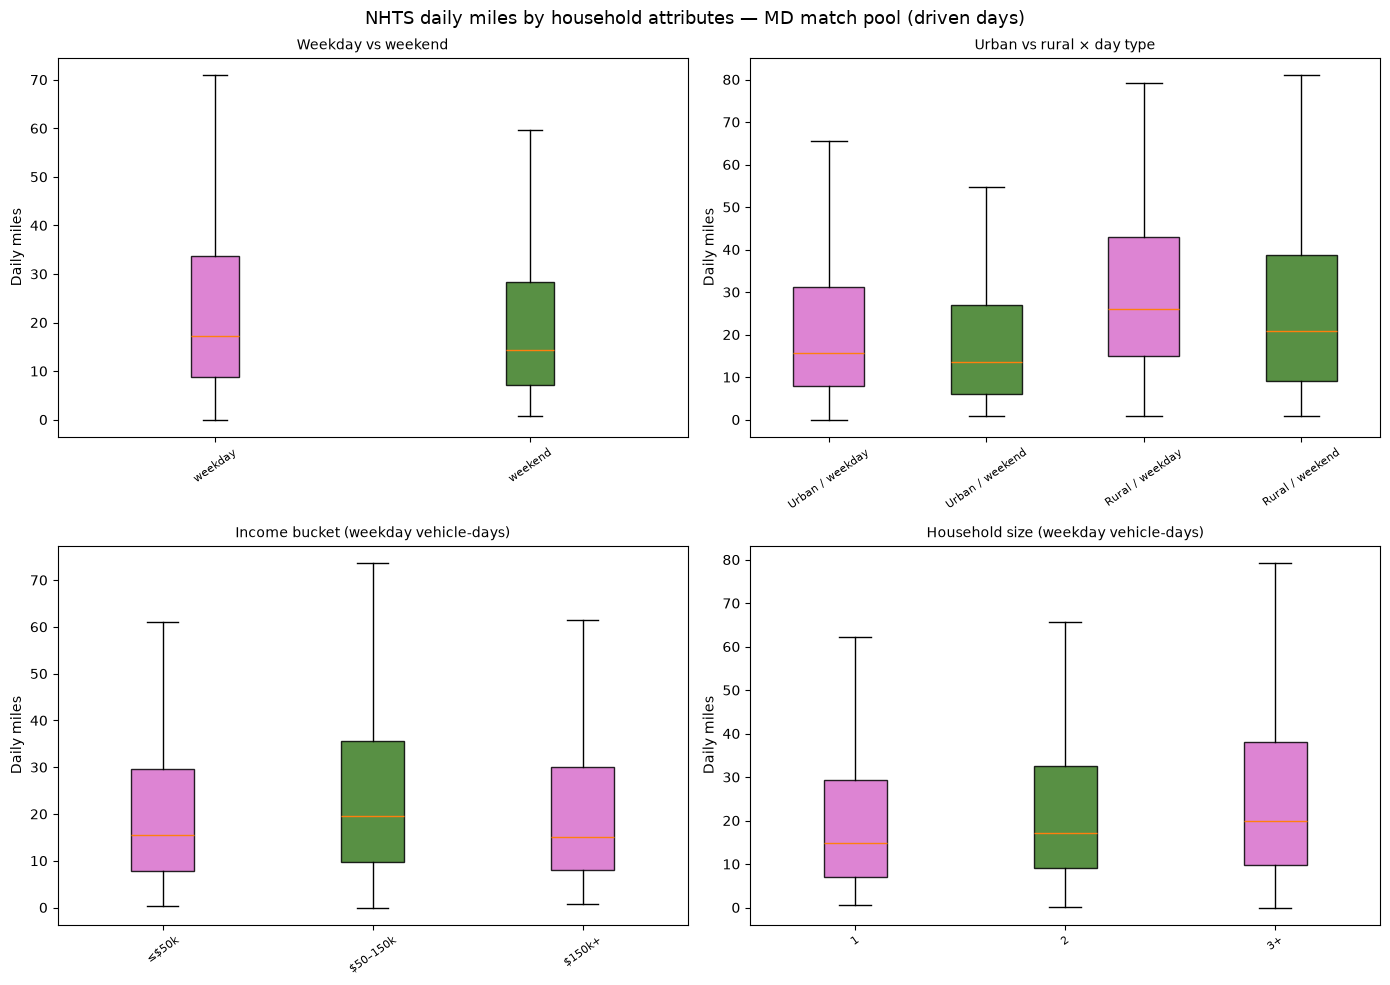

In [15]:
def _boxplot_by_group(
    ax,
    df: pl.DataFrame,
    group_col: str,
    *,
    order: list,
    title: str,
    ylabel: str = "Daily miles",
) -> None:
    labels = []
    data = []
    for g in order:
        vals = df.filter(pl.col(group_col) == g)["daily_miles"].to_numpy()
        if len(vals) == 0:
            continue
        labels.append(str(g))
        data.append(vals)
    bp = ax.boxplot(data, tick_labels=labels, showfliers=False, patch_artist=True)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor(COLOR_PINK if i % 2 == 0 else COLOR_GREEN)
        patch.set_alpha(0.85)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelrotation=35, labelsize=8)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"NHTS daily miles by household attributes — {STATE} match pool (driven days)", fontsize=13)

_boxplot_by_group(
    axes[0, 0],
    vehicle_day_driven,
    "day_type",
    order=["weekday", "weekend"],
    title="Weekday vs weekend",
)

urban_plot = vehicle_day_driven.with_columns(
    (pl.col("urban_label") + " / " + pl.col("day_type")).alias("urban_day")
)
_boxplot_by_group(
    axes[0, 1],
    urban_plot,
    "urban_day",
    order=["Urban / weekday", "Urban / weekend", "Rural / weekday", "Rural / weekend"],
    title="Urban vs rural × day type",
)

weekday_only = vehicle_day_driven.filter(pl.col("day_type") == "weekday")
_boxplot_by_group(
    axes[1, 0],
    weekday_only,
    "income_label",
    order=[INCOME_LABELS[i] for i in range(1, 4)],
    title="Income bucket (weekday vehicle-days)",
)
_boxplot_by_group(
    axes[1, 1],
    weekday_only,
    "occupants_bin",
    order=list(OCCUPANTS_LABELS.values()),
    title="Household size (weekday vehicle-days)",
)

fig.tight_layout()
plt.show()


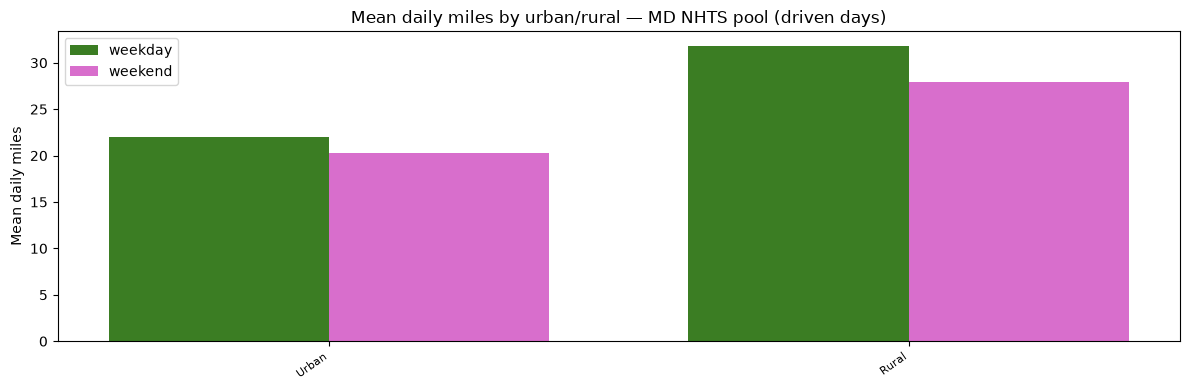

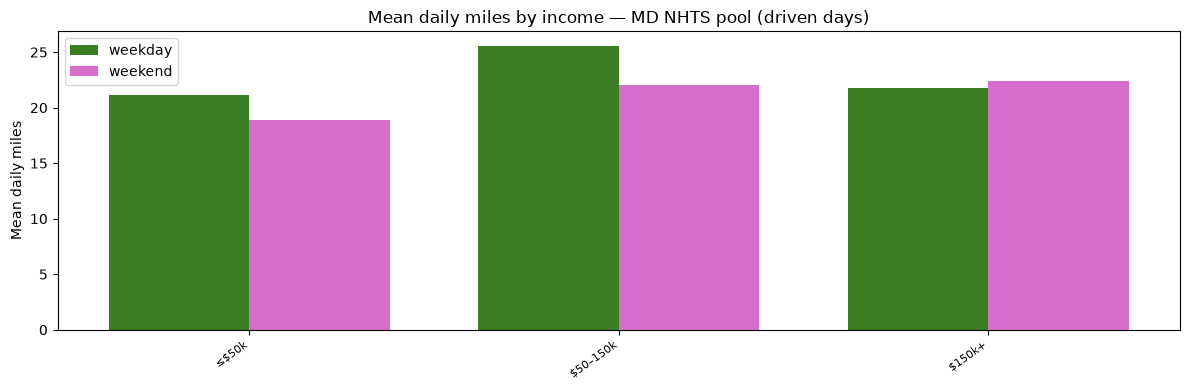

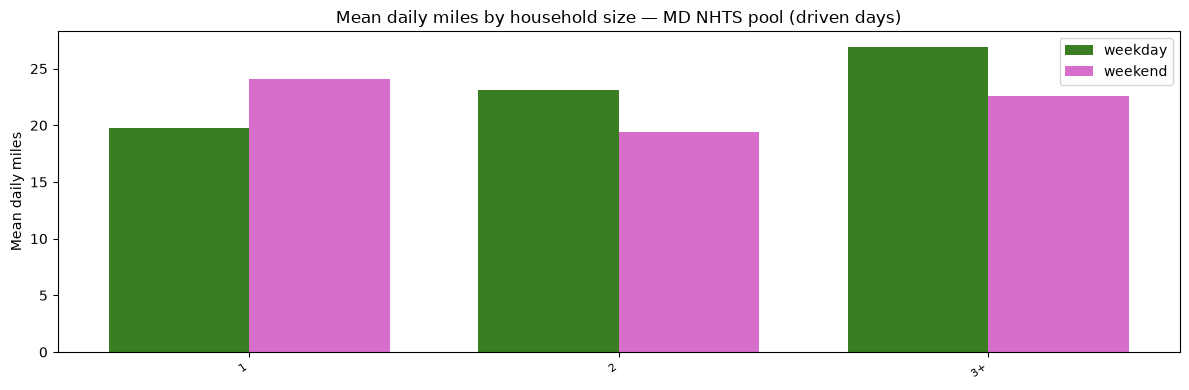

In [16]:
# Mean daily miles: weekday vs weekend side-by-side for each attribute
def _mean_miles_bars(df: pl.DataFrame, group_col: str, order: list[str], title: str) -> None:
    fig, ax = plt.subplots(figsize=(12, 4))
    width = 0.38
    x = np.arange(len(order))
    for i, (day, color) in enumerate([("weekday", COLOR_GREEN), ("weekend", COLOR_PINK)]):
        means = []
        for g in order:
            sub = df.filter((pl.col(group_col) == g) & (pl.col("day_type") == day))["daily_miles"]
            means.append(float(sub.mean()) if sub.len() else np.nan)
        ax.bar(x + (i - 0.5) * width, means, width=width, label=day, color=color)
    ax.set_xticks(x)
    ax.set_xticklabels(order, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Mean daily miles")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.show()


_mean_miles_bars(
    vehicle_day_driven,
    "urban_label",
    ["Urban", "Rural"],
    f"Mean daily miles by urban/rural — {STATE} NHTS pool (driven days)",
)
_mean_miles_bars(
    vehicle_day_driven,
    "income_label",
    [INCOME_LABELS[i] for i in range(1, 4)],
    f"Mean daily miles by income — {STATE} NHTS pool (driven days)",
)
_mean_miles_bars(
    vehicle_day_driven,
    "occupants_bin",
    list(OCCUPANTS_LABELS.values()),
    f"Mean daily miles by household size — {STATE} NHTS pool (driven days)",
)


2026-08-09 00:46:08,400 - INFO - Substituting symbol N from STIXNonUnicode
2026-08-09 00:46:08,455 - INFO - Substituting symbol N from STIXNonUnicode


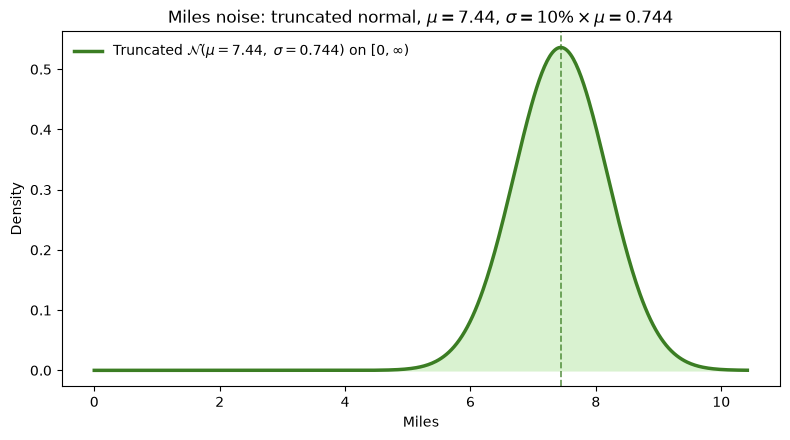

In [17]:
# Miles noise: truncated Normal(μ, 0.1·μ) on [0, ∞) — matches TripScheduleGenerator
from scipy.stats import truncnorm

mu = 7.44
sigma = 0.10 * mu  # 10% of mean
a, b = (0.0 - mu) / sigma, np.inf  # truncation bounds in standard units
x = np.linspace(0.0, mu + 4 * sigma, 500)
pdf = truncnorm.pdf(x, a, b, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.fill_between(x, pdf, color="#D9F2D0", alpha=1.0)
ax.plot(
    x,
    pdf,
    color="#3B7D23",
    linewidth=2.5,
    label=rf"Truncated $\mathcal{{N}}(\mu={mu},\;\sigma={sigma:.3f})$ on $[0,\infty)$",
)
ax.axvline(mu, color="#3B7D23", linestyle="--", linewidth=1.2, alpha=0.8)
ax.set_xlabel("Miles")
ax.set_ylabel("Density")
ax.set_title(rf"Miles noise: truncated normal, $\mu = {mu}$, $\sigma = 10\% \times \mu = {sigma:.3f}$")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 5. Annual driving profiles

Replay each matched weekday / weekend NHTS template over the config simulation window
(`start_date` → `end_date`), applying the configured departure/arrival hour offsets and
miles noise (see the truncated-normal figure above). One row in `trip_schedules` is one trip
leg; tour columns define leave-home → return-home windows for presence / home charging.

**Synthetic seam trips:** when adjacent travel days disagree about home/away at the 4am
boundary (open NHTS templates), `TripScheduleGenerator` adds the missing return-home or
leave-home leg in the gap between the prior day's last arrival and the next day's first
departure. Miles and duration mirror the opposite observed tour edge (after time offsets);
the trip midpoint uses triangular weights centered on the gap midpoint. If the mirrored
duration exceeds the overnight gap, duration is clamped to the gap but miles are kept
(`synthetic_duration_clamped=True`). These rows discharge the battery and count toward
peak-daily-mile pack sizing (`is_synthetic_trip=True`; seam kind in `synthetic_seam_kind`).

Idle matched templates (`has_weekday_trips` / `has_weekend_trips` false) emit **no trips**
on those calendar day types — the vehicle stays home. With
`include_zero_driving_days_in_match_pool: false`, those idle markers are absent from the
match pool, so empty templates should be rare (only if a day type somehow has no trip legs).


In [18]:
assert config.start_date is not None and config.end_date is not None

trip_gen = TripScheduleGenerator(
    start_date=config.start_date,
    end_date=config.end_date,
    random_state=SEED,
    max_workers=config.max_workers,
    min_trip_away_hours=config.min_trip_away_hours,
    max_departure_hour=config.max_departure_hour,
    max_arrival_hour=config.max_arrival_hour,
    time_offsets=config.time_offsets,
    time_offset_probabilities=config.time_offset_probabilities,
    miles_noise_std_fraction=config.miles_noise_std_fraction,
)

print(
    f"Generating trips for {len(vehicle_profiles):,} vehicles "
    f"from {config.start_date} → {config.end_date} "
    f"(max_workers={config.max_workers})"
)
trip_schedules = trip_gen.generate(vehicle_profiles)
n_with_trips = trip_schedules.select("bldg_id", "vehicle_id").unique().height
print(
    f"Trip schedule rows: {trip_schedules.height:,}  "
    f"across {n_with_trips:,} / {len(vehicle_profiles):,} vehicles "
    f"({len(vehicle_profiles) - n_with_trips:,} never-driven — empty weekday+weekend templates)"
)

# Matched open templates (synthetic seam trips fire when these replay across nights).
n_open_wd = sum(
    1
    for p in vehicle_profiles.values()
    if p.weekday.has_trips and not (p.weekday.starts_home and p.weekday.ends_home)
)
n_open_we = sum(
    1
    for p in vehicle_profiles.values()
    if p.weekend.has_trips and not (p.weekend.starts_home and p.weekend.ends_home)
)
n_wd = sum(1 for p in vehicle_profiles.values() if p.weekday.has_trips)
n_we = sum(1 for p in vehicle_profiles.values() if p.weekend.has_trips)
print(
    f"Open matched templates: weekday={n_open_wd:,}/{n_wd:,}, "
    f"weekend={n_open_we:,}/{n_we:,}"
)
display(trip_schedules.head(8) if trip_schedules.height else trip_schedules)


Generating trips for 178 vehicles from 2024-01-01 04:00:00 → 2025-01-01 03:00:00 (max_workers=8)


2026-08-09 00:46:19,097 - INFO - Generating trip schedules: 178/178 (100.0%)
2026-08-09 00:46:19,099 - INFO - Generated 191218 trip schedules from 178 vehicle profiles


Trip schedule rows: 191,218  across 178 / 178 vehicles (0 never-driven — empty weekday+weekend templates)
Open matched templates: weekday=21/178, weekend=13/178


bldg_id,vehicle_id,travel_date,trip_departure_date,trip_departure_hour,trip_arrival_date,trip_arrival_hour,trip_miles_driven,is_synthetic_trip,synthetic_seam_kind,synthetic_duration_clamped,synthetic_mirror_duration_hours,tour_id,tour_departure_date,tour_departure_hour,tour_arrival_date,tour_arrival_hour
i64,i64,datetime[μs],datetime[μs],i64,datetime[μs],i64,f64,bool,str,bool,i64,i64,datetime[μs],i64,datetime[μs],i64
3870,1,2024-01-01 00:00:00,2024-01-01 00:00:00,18,2024-01-01 00:00:00,19,1.118004,false,null,false,null,1,2024-01-01 00:00:00,18,2024-01-01 00:00:00,23
3870,1,2024-01-01 00:00:00,2024-01-01 00:00:00,22,2024-01-01 00:00:00,23,1.118006,false,null,false,null,1,2024-01-01 00:00:00,18,2024-01-01 00:00:00,23
3870,1,2024-01-02 00:00:00,2024-01-02 00:00:00,17,2024-01-02 00:00:00,19,1.091065,false,null,false,null,1,2024-01-02 00:00:00,17,2024-01-02 00:00:00,22
3870,1,2024-01-02 00:00:00,2024-01-02 00:00:00,21,2024-01-02 00:00:00,22,1.206923,false,null,false,null,1,2024-01-02 00:00:00,17,2024-01-02 00:00:00,22
3870,1,2024-01-03 00:00:00,2024-01-03 00:00:00,18,2024-01-03 00:00:00,19,0.94734,false,null,false,null,1,2024-01-03 00:00:00,18,2024-01-03 00:00:00,21
3870,1,2024-01-03 00:00:00,2024-01-03 00:00:00,20,2024-01-03 00:00:00,21,1.080439,false,null,false,null,1,2024-01-03 00:00:00,18,2024-01-03 00:00:00,21
3870,1,2024-01-04 00:00:00,2024-01-04 00:00:00,18,2024-01-04 00:00:00,19,1.312599,false,null,false,null,1,2024-01-04 00:00:00,18,2024-01-04 00:00:00,21
3870,1,2024-01-04 00:00:00,2024-01-04 00:00:00,19,2024-01-04 00:00:00,21,1.118963,false,null,false,null,1,2024-01-04 00:00:00,18,2024-01-04 00:00:00,21


In [19]:
# Fleet-wide synthetic seam statistics + one example vehicle.
from utils.EVs.TripScheduleGenerator import MAX_SYNTHETIC_TRIP_AVERAGE_SPEED_MPH

synthetic = trip_schedules.filter(pl.col("is_synthetic_trip"))
observed = trip_schedules.filter(~pl.col("is_synthetic_trip"))
n_synth = synthetic.height
n_obs = observed.height
synth_miles = float(synthetic["trip_miles_driven"].sum()) if n_synth else 0.0
obs_miles = float(observed["trip_miles_driven"].sum()) if n_obs else 0.0
total_miles = synth_miles + obs_miles

print("=== Synthetic seam trip summary ===")
print(
    f"Synthetic rows: {n_synth:,} / {trip_schedules.height:,} "
    f"({n_synth / max(trip_schedules.height, 1):.2%} of trip rows)\n"
    f"Synthetic miles: {synth_miles:,.0f} / {total_miles:,.0f} "
    f"({synth_miles / max(total_miles, 1e-9):.2%} of annual fleet miles)"
)

if n_synth:
    synthetic = synthetic.with_columns(
        (
            (
                pl.col("trip_arrival_date").cast(pl.Datetime)
                + pl.duration(hours=pl.col("trip_arrival_hour"))
            )
            - (
                pl.col("trip_departure_date").cast(pl.Datetime)
                + pl.duration(hours=pl.col("trip_departure_hour"))
            )
        )
        .dt.total_hours()
        .alias("duration_h")
    )
    by_kind = (
        synthetic.group_by("synthetic_seam_kind")
        .agg(
            pl.len().alias("n_trips"),
            pl.col("trip_miles_driven").sum().round(1).alias("miles"),
            pl.col("synthetic_duration_clamped").sum().alias("n_duration_clamped"),
            pl.col("duration_h").mean().round(2).alias("mean_duration_h"),
            pl.col("synthetic_mirror_duration_hours")
            .mean()
            .round(2)
            .alias("mean_mirror_duration_h"),
            pl.col("trip_miles_driven").mean().round(1).alias("mean_miles"),
        )
        .sort("synthetic_seam_kind")
    )
    display(by_kind)

    n_clamped = int(synthetic["synthetic_duration_clamped"].sum())
    n_return = int(synthetic.filter(pl.col("synthetic_seam_kind") == "return_home").height)
    n_leave = int(synthetic.filter(pl.col("synthetic_seam_kind") == "leave_home").height)
    n_return_clamped = int(
        synthetic.filter(
            (pl.col("synthetic_seam_kind") == "return_home")
            & pl.col("synthetic_duration_clamped")
        ).height
    )
    n_leave_clamped = int(
        synthetic.filter(
            (pl.col("synthetic_seam_kind") == "leave_home")
            & pl.col("synthetic_duration_clamped")
        ).height
    )
    print(
        f"\nDuration clamps (mirror duration > overnight gap; miles preserved):\n"
        f"  all synthetic: {n_clamped:,} / {n_synth:,} ({n_clamped / n_synth:.2%})\n"
        f"  return_home:   {n_return_clamped:,} / {n_return:,}\n"
        f"  leave_home:    {n_leave_clamped:,} / {n_leave:,}"
    )

    clamped = synthetic.filter(pl.col("synthetic_duration_clamped")).with_columns(
        (pl.col("trip_miles_driven") / pl.col("duration_h").clip(lower_bound=1)).alias(
            "implied_mph"
        )
    )
    if clamped.height:
        n_fast = int((clamped["implied_mph"] > MAX_SYNTHETIC_TRIP_AVERAGE_SPEED_MPH).sum())
        print(
            f"\nClamped seams implied speed: "
            f"mean={clamped['implied_mph'].mean():.1f} mph, "
            f"max={clamped['implied_mph'].max():.1f} mph, "
            f">{MAX_SYNTHETIC_TRIP_AVERAGE_SPEED_MPH:.0f} mph audit threshold: "
            f"{n_fast:,} / {clamped.height:,}"
        )
        display(
            clamped.select(
                "synthetic_seam_kind",
                "trip_miles_driven",
                "synthetic_mirror_duration_hours",
                "duration_h",
                "implied_mph",
            )
            .sort("implied_mph", descending=True)
            .head(10)
        )
    else:
        print("\nNo duration clamps in this run.")
else:
    print("No synthetic seam trips in this sample.")

# Example vehicle with an open weekday template.
open_weekday_key = next(
    (
        key
        for key, profile in vehicle_profiles.items()
        if profile.weekday.has_trips
        and not (profile.weekday.starts_home and profile.weekday.ends_home)
    ),
    None,
)
if open_weekday_key is None:
    print("\nNo open weekday templates — check weekends or another seed.")
else:
    bldg_id, vehicle_id = open_weekday_key
    day = vehicle_profiles[open_weekday_key].weekday
    print(
        f"\nExample open weekday template: bldg={bldg_id}, vehicle={vehicle_id}  "
        f"starts_home={day.starts_home}, ends_home={day.ends_home}"
    )
    veh_days = (
        trip_schedules.filter(
            (pl.col("bldg_id") == bldg_id) & (pl.col("vehicle_id") == vehicle_id)
        )
        .with_columns(pl.col("travel_date").dt.weekday().alias("dow"))
        .filter(pl.col("dow") <= 5)
        .sort("travel_date", "trip_departure_date", "trip_departure_hour")
    )
    travel_dates = veh_days["travel_date"].unique().sort().head(2).to_list()
    if len(travel_dates) < 2:
        print("Need ≥2 weekday travel days to show a seam.")
    else:
        seam_rows = veh_days.filter(pl.col("travel_date").is_in(travel_dates)).select(
            "travel_date",
            "is_synthetic_trip",
            "synthetic_seam_kind",
            "synthetic_duration_clamped",
            "synthetic_mirror_duration_hours",
            "trip_departure_date",
            "trip_departure_hour",
            "trip_arrival_date",
            "trip_arrival_hour",
            "trip_miles_driven",
            "tour_departure_hour",
            "tour_arrival_hour",
        )
        display(seam_rows)


=== Synthetic seam trip summary ===
Synthetic rows: 6,676 / 191,218 (3.49% of trip rows)
Synthetic miles: 47,283 / 1,454,883 (3.25% of annual fleet miles)


synthetic_seam_kind,n_trips,miles,n_duration_clamped,mean_duration_h,mean_mirror_duration_h,mean_miles
str,u32,f64,u32,f64,f64,f64
"""leave_home""",2504,17518.6,0,1.57,1.57,7.0
"""return_home""",4172,29764.8,0,1.49,1.49,7.1



Duration clamps (mirror duration > overnight gap; miles preserved):
  all synthetic: 0 / 6,676 (0.00%)
  return_home:   0 / 4,172
  leave_home:    0 / 2,504

No duration clamps in this run.

Example open weekday template: bldg=50724, vehicle=1  starts_home=True, ends_home=False


travel_date,is_synthetic_trip,synthetic_seam_kind,synthetic_duration_clamped,synthetic_mirror_duration_hours,trip_departure_date,trip_departure_hour,trip_arrival_date,trip_arrival_hour,trip_miles_driven,tour_departure_hour,tour_arrival_hour
datetime[μs],bool,str,bool,i64,datetime[μs],i64,datetime[μs],i64,f64,i64,i64
2024-01-01 00:00:00,false,null,false,null,2024-01-01 00:00:00,13,2024-01-01 00:00:00,14,4.618542,13,10
2024-01-01 00:00:00,false,null,false,null,2024-01-01 00:00:00,15,2024-01-01 00:00:00,16,5.402501,13,10
2024-01-01 00:00:00,true,"""return_home""",false,1,2024-01-02 00:00:00,9,2024-01-02 00:00:00,10,4.618542,13,10
2024-01-02 00:00:00,false,null,false,null,2024-01-02 00:00:00,13,2024-01-02 00:00:00,14,5.276066,13,7
2024-01-02 00:00:00,false,null,false,null,2024-01-02 00:00:00,15,2024-01-02 00:00:00,18,5.752575,13,7
2024-01-02 00:00:00,true,"""return_home""",false,1,2024-01-03 00:00:00,6,2024-01-03 00:00:00,7,5.276066,13,7


In [20]:
# Per-vehicle and per-travel-day aggregates, joined to building attributes.
# daily_miles rows are travel days with ≥1 emitted trip (empty profile days omitted).
vehicle_attrs = bldg_vehicles.select(
    "bldg_id", "weight", "urban", "income_bucket", "occupants", "fpl", "building_type", "tenure"
)

n_sim_travel_days = len(
    list(
        iter_travel_day_starts(
            config.start_date,
            config.end_date,
            travel_day_start_hour=trip_gen.travel_day_start_hour,
        )
    )
)
print(f"Simulation travel days: {n_sim_travel_days:,}")

# How many matched templates were empty? (drives stay-home calendar days)
catalog_empty = nhts_match_catalog.select(
    "bldg_id",
    pl.col("vehicle_slot").alias("vehicle_id"),
    "has_weekday_trips",
    "has_weekend_trips",
)
print(
    "Matched template emptiness — "
    f"weekday empty={int((~catalog_empty['has_weekday_trips']).sum())}/{catalog_empty.height}, "
    f"weekend empty={int((~catalog_empty['has_weekend_trips']).sum())}/{catalog_empty.height}"
)

daily_miles = (
    trip_schedules.group_by("bldg_id", "vehicle_id", "travel_date")
    .agg(
        pl.col("trip_miles_driven").sum().alias("daily_miles"),
        pl.len().alias("n_trips"),
    )
    .with_columns(
        pl.col("travel_date").dt.weekday().alias("iso_weekday"),  # Mon=1 … Sun=7
        pl.col("travel_date").dt.month().alias("month"),
    )
    .with_columns(
        pl.when(pl.col("iso_weekday") <= 5)
        .then(pl.lit("weekday"))
        .otherwise(pl.lit("weekend"))
        .alias("day_type"),
    )
    .join(vehicle_attrs, on="bldg_id", how="left")
    .with_columns(
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        pl.col("income_bucket").replace_strict(INCOME_LABELS).alias("income_label"),
    )
)

annual_from_trips = (
    daily_miles.group_by("bldg_id", "vehicle_id")
    .agg(
        pl.col("daily_miles").sum().alias("annual_miles"),
        pl.col("daily_miles").mean().alias("mean_daily_miles_on_drive_days"),
        pl.col("daily_miles").median().alias("median_daily_miles_on_drive_days"),
        pl.col("daily_miles").max().alias("max_daily_miles"),
        pl.col("n_trips").sum().alias("annual_trips"),
        pl.len().alias("n_drive_days"),
    )
)

# Include vehicles with fully empty weekday+weekend templates (no trip rows emitted).
all_slots = pl.DataFrame({
    "bldg_id": [k[0] for k in vehicle_profiles],
    "vehicle_id": [k[1] for k in vehicle_profiles],
})
annual_miles = (
    all_slots.join(annual_from_trips, on=["bldg_id", "vehicle_id"], how="left")
    .with_columns(
        pl.col("annual_miles").fill_null(0.0),
        pl.col("n_drive_days").fill_null(0),
        pl.col("annual_trips").fill_null(0),
        pl.col("max_daily_miles").fill_null(0.0),
    )
    .with_columns(
        (pl.col("annual_miles") / n_sim_travel_days).alias("mean_daily_miles"),
        (pl.col("n_drive_days") / float(n_sim_travel_days)).alias("drive_day_fraction"),
    )
    .join(vehicle_attrs, on="bldg_id", how="left")
    .join(catalog_empty, on=["bldg_id", "vehicle_id"], how="left")
    .with_columns(
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        pl.col("income_bucket").replace_strict(INCOME_LABELS).alias("income_label"),
    )
)

print(f"Vehicles in annual table: {annual_miles.height:,} / {len(vehicle_profiles):,}")
print(f"Drive-day rows (days with ≥1 trip): {daily_miles.height:,}")
print(
    f"Mean drive-day fraction: {annual_miles['drive_day_fraction'].mean():.1%}  "
    f"(min={annual_miles['drive_day_fraction'].min():.1%}, "
    f"max={annual_miles['drive_day_fraction'].max():.1%})"
)
display(
    annual_miles.select(
        "annual_miles",
        "mean_daily_miles",
        "mean_daily_miles_on_drive_days",
        "max_daily_miles",
        "annual_trips",
        "n_drive_days",
        "drive_day_fraction",
    ).describe()
)


Simulation travel days: 366
Matched template emptiness — weekday empty=0/178, weekend empty=0/178
Vehicles in annual table: 178 / 178
Drive-day rows (days with ≥1 trip): 65,148
Mean drive-day fraction: 100.0%  (min=100.0%, max=100.0%)


statistic,annual_miles,mean_daily_miles,mean_daily_miles_on_drive_days,max_daily_miles,annual_trips,n_drive_days,drive_day_fraction
str,f64,f64,f64,f64,f64,f64,f64
"""count""",178.0,178.0,178.0,178.0,178.0,178.0,178.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",8173.50033,22.331968,22.331968,39.789749,1074.258427,366.0,1.0
"""std""",6176.909583,16.876802,16.876802,30.294988,385.333373,0.0,0.0
"""min""",531.66996,1.45265,1.45265,3.689897,470.0,366.0,1.0
"""25%""",3900.818308,10.657974,10.657974,17.321782,732.0,366.0,1.0
"""50%""",6524.419003,17.826281,17.826281,29.749326,993.0,366.0,1.0
"""75%""",10495.857016,28.677205,28.677205,56.418952,1256.0,366.0,1.0
"""max""",30186.828109,82.477672,82.477672,124.02944,2666.0,366.0,1.0


In [21]:
def _summary_row(name: str, values: pl.Series) -> dict:
    arr = values.drop_nulls().to_numpy()
    return {
        "group": name,
        "n": len(arr),
        "mean": round(float(arr.mean()), 1) if len(arr) else None,
        "median": round(float(np.median(arr)), 1) if len(arr) else None,
        "p10": round(float(np.percentile(arr, 10)), 1) if len(arr) else None,
        "p90": round(float(np.percentile(arr, 90)), 1) if len(arr) else None,
    }


print("Annual miles per vehicle")
display(pl.DataFrame([_summary_row("all EV slots", annual_miles["annual_miles"])]))

print("\nAnnual miles by urban/rural")
display(
    pl.DataFrame([
        _summary_row(label, annual_miles.filter(pl.col("urban_label") == label)["annual_miles"])
        for label in ["Urban", "Rural"]
    ])
)

print("\nMean daily miles by day type")
display(
    daily_miles.group_by("day_type")
    .agg(
        pl.len().alias("n_vehicle_days"),
        pl.col("daily_miles").mean().round(1).alias("mean_miles"),
        pl.col("daily_miles").median().round(1).alias("median_miles"),
        pl.col("n_trips").mean().round(2).alias("mean_trips"),
    )
    .sort("day_type")
)

print("\nMean daily miles by urban/rural × day type")
display(
    daily_miles.group_by("urban_label", "day_type")
    .agg(
        pl.len().alias("n_vehicle_days"),
        pl.col("daily_miles").mean().round(1).alias("mean_miles"),
        pl.col("daily_miles").median().round(1).alias("median_miles"),
    )
    .sort("urban_label", "day_type")
)

print("\nMean daily miles by month")
display(
    daily_miles.group_by("month")
    .agg(
        pl.col("daily_miles").mean().round(1).alias("mean_miles"),
        pl.col("daily_miles").median().round(1).alias("median_miles"),
        pl.len().alias("n_vehicle_days"),
    )
    .sort("month")
)


Annual miles per vehicle


group,n,mean,median,p10,p90
str,i64,f64,f64,f64,f64
"""all EV slots""",178,8173.5,6511.4,2414.4,16922.1



Annual miles by urban/rural


group,n,mean,median,p10,p90
str,i64,f64,f64,f64,f64
"""Urban""",174,8076.6,6344.6,2413.7,16634.7
"""Rural""",4,12386.9,12297.3,8177.9,16667.6



Mean daily miles by day type


day_type,n_vehicle_days,mean_miles,median_miles,mean_trips
str,u32,f64,f64,f64
"""weekday""",46636,21.9,13.9,2.89
"""weekend""",18512,23.4,14.5,3.05



Mean daily miles by urban/rural × day type


urban_label,day_type,n_vehicle_days,mean_miles,median_miles
str,str,u32,f64,f64
"""Rural""","""weekday""",1048,29.4,20.5
"""Rural""","""weekend""",416,45.0,46.2
"""Urban""","""weekday""",45588,21.7,13.9
"""Urban""","""weekend""",18096,22.9,14.3



Mean daily miles by month


month,mean_miles,median_miles,n_vehicle_days
i8,f64,f64,u32
1,22.3,14.1,5518
2,22.3,14.1,5162
3,22.4,14.1,5518
4,22.3,14.1,5340
5,22.3,14.1,5518
…,…,…,…
8,22.3,14.1,5518
9,22.4,14.2,5340
10,22.3,14.1,5518


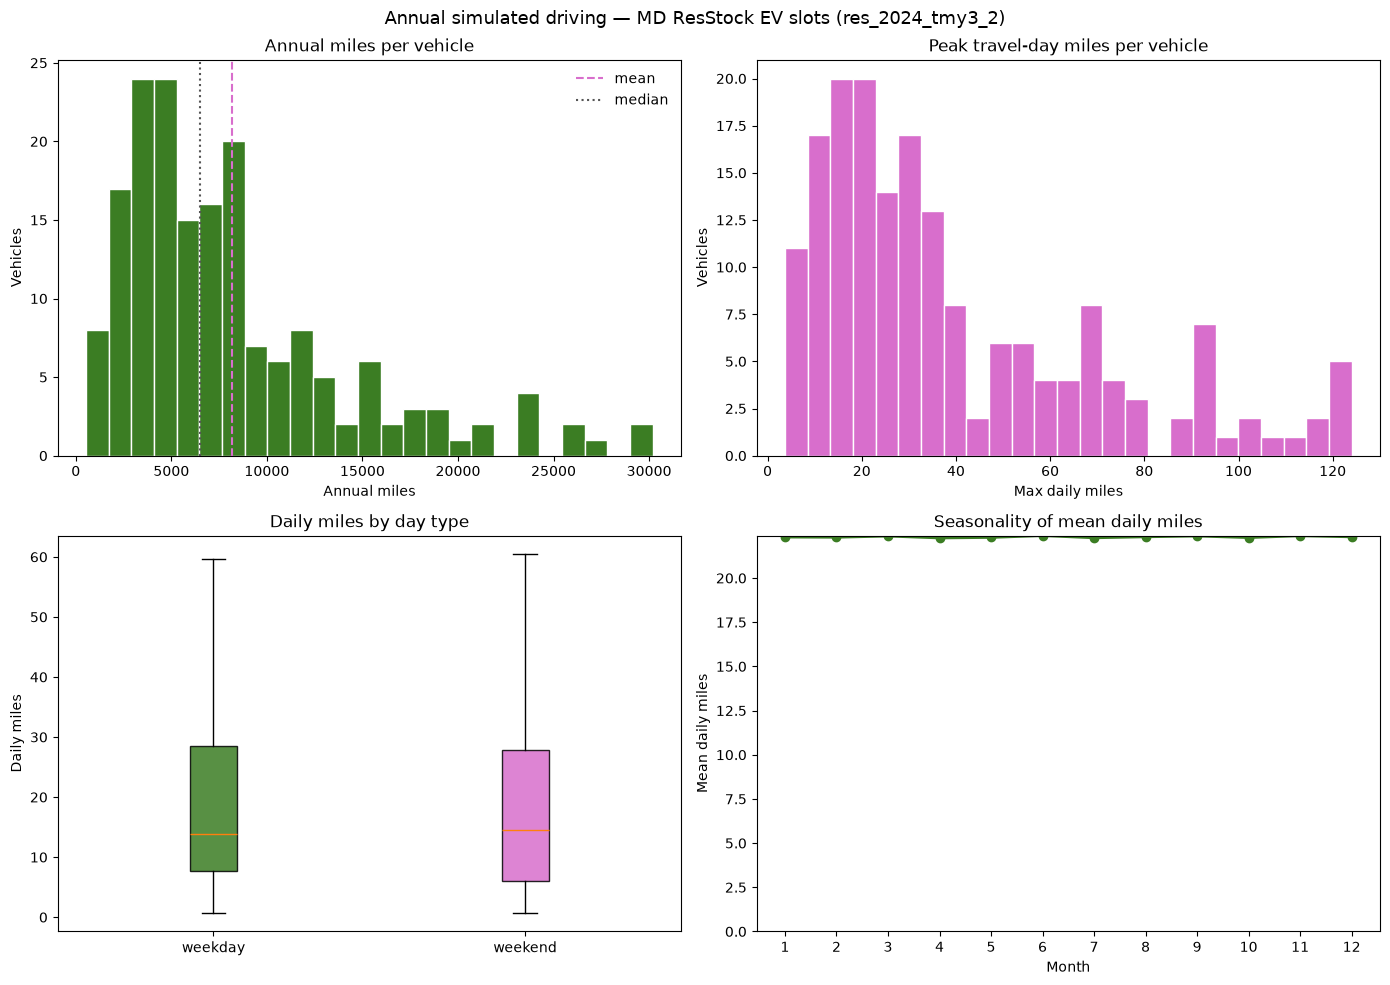

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Annual simulated driving — {STATE} ResStock EV slots ({config.release})", fontsize=13)

# Annual miles histogram
ax = axes[0, 0]
ax.hist(annual_miles["annual_miles"].to_numpy(), bins=25, color=COLOR_GREEN, edgecolor="white")
ax.axvline(annual_miles["annual_miles"].mean(), color=COLOR_PINK, linestyle="--", linewidth=1.5, label="mean")
ax.axvline(annual_miles["annual_miles"].median(), color="#555555", linestyle=":", linewidth=1.5, label="median")
ax.set_xlabel("Annual miles")
ax.set_ylabel("Vehicles")
ax.set_title("Annual miles per vehicle")
ax.legend(frameon=False)

# Max daily miles (battery-sizing relevant)
ax = axes[0, 1]
ax.hist(annual_miles["max_daily_miles"].to_numpy(), bins=25, color=COLOR_PINK, edgecolor="white")
ax.set_xlabel("Max daily miles")
ax.set_ylabel("Vehicles")
ax.set_title("Peak travel-day miles per vehicle")

# Daily miles: weekday vs weekend boxplots
ax = axes[1, 0]
box_data = [
    daily_miles.filter(pl.col("day_type") == d)["daily_miles"].to_numpy()
    for d in ["weekday", "weekend"]
]
bp = ax.boxplot(box_data, tick_labels=["weekday", "weekend"], showfliers=False, patch_artist=True)
for patch, color in zip(bp["boxes"], [COLOR_GREEN, COLOR_PINK]):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.set_ylabel("Daily miles")
ax.set_title("Daily miles by day type")

# Mean daily miles by month
ax = axes[1, 1]
monthly = (
    daily_miles.group_by("month")
    .agg(pl.col("daily_miles").mean().alias("mean_miles"))
    .sort("month")
)
ax.plot(monthly["month"].to_numpy(), monthly["mean_miles"].to_numpy(), color=COLOR_GREEN, marker="o", linewidth=2)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Month")
ax.set_ylabel("Mean daily miles")
ax.set_title("Seasonality of mean daily miles")
ax.set_ylim(bottom=0)

fig.tight_layout()
plt.show()


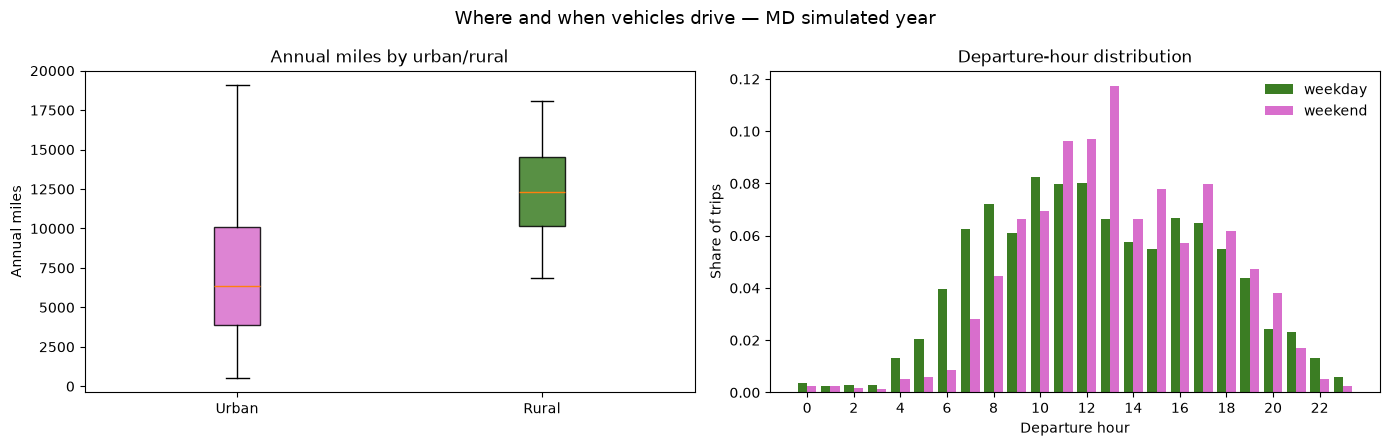

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f"Where and when vehicles drive — {STATE} simulated year", fontsize=13)

# Annual miles by urban/rural
ax = axes[0]
urban_order = ["Urban", "Rural"]
box_data = [
    annual_miles.filter(pl.col("urban_label") == g)["annual_miles"].to_numpy()
    for g in urban_order
]
bp = ax.boxplot(box_data, tick_labels=urban_order, showfliers=False, patch_artist=True)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(COLOR_PINK if i % 2 == 0 else COLOR_GREEN)
    patch.set_alpha(0.85)
ax.set_ylabel("Annual miles")
ax.set_title("Annual miles by urban/rural")

# Departure-hour distribution (weekday vs weekend)
ax = axes[1]
trips_with_day = trip_schedules.with_columns(
    pl.when(pl.col("travel_date").dt.weekday() <= 5)
    .then(pl.lit("weekday"))
    .otherwise(pl.lit("weekend"))
    .alias("day_type")
)
hours = np.arange(24)
width = 0.4
for i, (day, color) in enumerate([("weekday", COLOR_GREEN), ("weekend", COLOR_PINK)]):
    counts = (
        trips_with_day.filter(pl.col("day_type") == day)
        .group_by("trip_departure_hour")
        .agg(pl.len().alias("n"))
        .sort("trip_departure_hour")
    )
    count_map = dict(zip(counts["trip_departure_hour"].to_list(), counts["n"].to_list()))
    vals = np.array([count_map.get(h, 0) for h in hours], dtype=float)
    vals = vals / vals.sum() if vals.sum() else vals
    ax.bar(hours + (i - 0.5) * width, vals, width=width, label=day, color=color)
ax.set_xlabel("Departure hour")
ax.set_ylabel("Share of trips")
ax.set_title("Departure-hour distribution")
ax.set_xticks(range(0, 24, 2))
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


### ResStock 2025 MD — published EV characteristics (no re-modeling)

ResStock **2025** already assigns EV miles, battery option, charger level, and
home-charging share on the metadata (our §7 samples the same RECS charge-at-home
bins for the 2024 pipeline). For the 127 MD buildings with
`in.electric_vehicle_ownership == Yes`, plot those fields directly — **no NHTS
matching, trip replay, or battery re-assignment**.

Published hourly charging loads for the same buildings appear later (§ published
July-week loads).


In [24]:
# ResStock 2025 EV housing characteristics for NREL quota-sampled owners only
ev_chars_2025 = (
    pl.scan_parquet(PATH_METADATA_2025)
    .filter(pl.col("in.state") == STATE)
    .select(
        "bldg_id",
        pl.col("in.electric_vehicle_miles_traveled")
        .cast(pl.Float64)
        .alias("annual_miles"),
        pl.col("in.electric_vehicle_battery").alias("battery"),
        pl.col("in.electric_vehicle_charger").alias("charger"),
        pl.col("in.electric_vehicle_charge_at_home").alias("charge_at_home"),
        pl.col("in.electric_vehicle_outlet_access").alias("outlet_access"),
    )
    .collect()
    .join(
        bldg_ev_2025.filter(pl.col("has_ev")).select(
            "bldg_id", "urban", "fpl", "building_type", "tenure", "weight"
        ),
        on="bldg_id",
        how="inner",
    )
    .with_columns(
        pl.col("urban").replace_strict(URBAN_LABELS).alias("urban_label"),
        # Short labels for plots: "SUV, BEV, 300 mile range" etc.
        pl.col("battery")
        .str.replace("Battery Electric Vehicle", "BEV")
        .alias("battery_short"),
    )
)

print(f"ResStock 2025 EV buildings: {ev_chars_2025.height:,}")
display(
    ev_chars_2025.select("annual_miles").describe().with_columns(
        pl.col("annual_miles").round(1)
    )
)
display(
    ev_chars_2025.group_by("urban_label")
    .agg(
        pl.len().alias("n"),
        pl.col("annual_miles").mean().round(0).alias("mean_miles"),
        pl.col("annual_miles").median().alias("median_miles"),
        pl.col("annual_miles").min().alias("min_miles"),
        pl.col("annual_miles").max().alias("max_miles"),
    )
    .sort("urban_label")
)
display(
    ev_chars_2025.group_by("battery_short", "charger")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)


ResStock 2025 EV buildings: 127


statistic,annual_miles
str,f64
"""count""",127.0
"""null_count""",0.0
"""mean""",9626.0
"""std""",6024.7
"""min""",1000.0
"""25%""",5000.0
"""50%""",9000.0
"""75%""",15000.0
"""max""",22500.0


urban_label,n,mean_miles,median_miles,min_miles,max_miles
str,u32,f64,f64,f64,f64
"""Rural""",2,11750.0,11750.0,1000.0,22500.0
"""Urban""",125,9592.0,9000.0,1000.0,22500.0


battery_short,charger,n
str,str,u32
"""SUV, BEV, 300 mile range""","""Level 1 charger""",31
"""Compact, BEV, 300 mile range""","""Level 2 charger""",21
"""SUV, BEV, 300 mile range""","""Level 2 charger""",16
"""Compact, BEV, 300 mile range""","""Level 1 charger""",14
"""Midsize, BEV, 300 mile range""","""Level 2 charger""",14
…,…,…
"""Midsize, BEV, 300 mile range""","""Level 1 charger""",6
"""Compact, BEV, 200 mile range""","""Level 1 charger""",4
"""Compact, BEV, 200 mile range""","""Level 2 charger""",4


2026-08-09 00:46:19,801 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-09 00:46:19,802 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


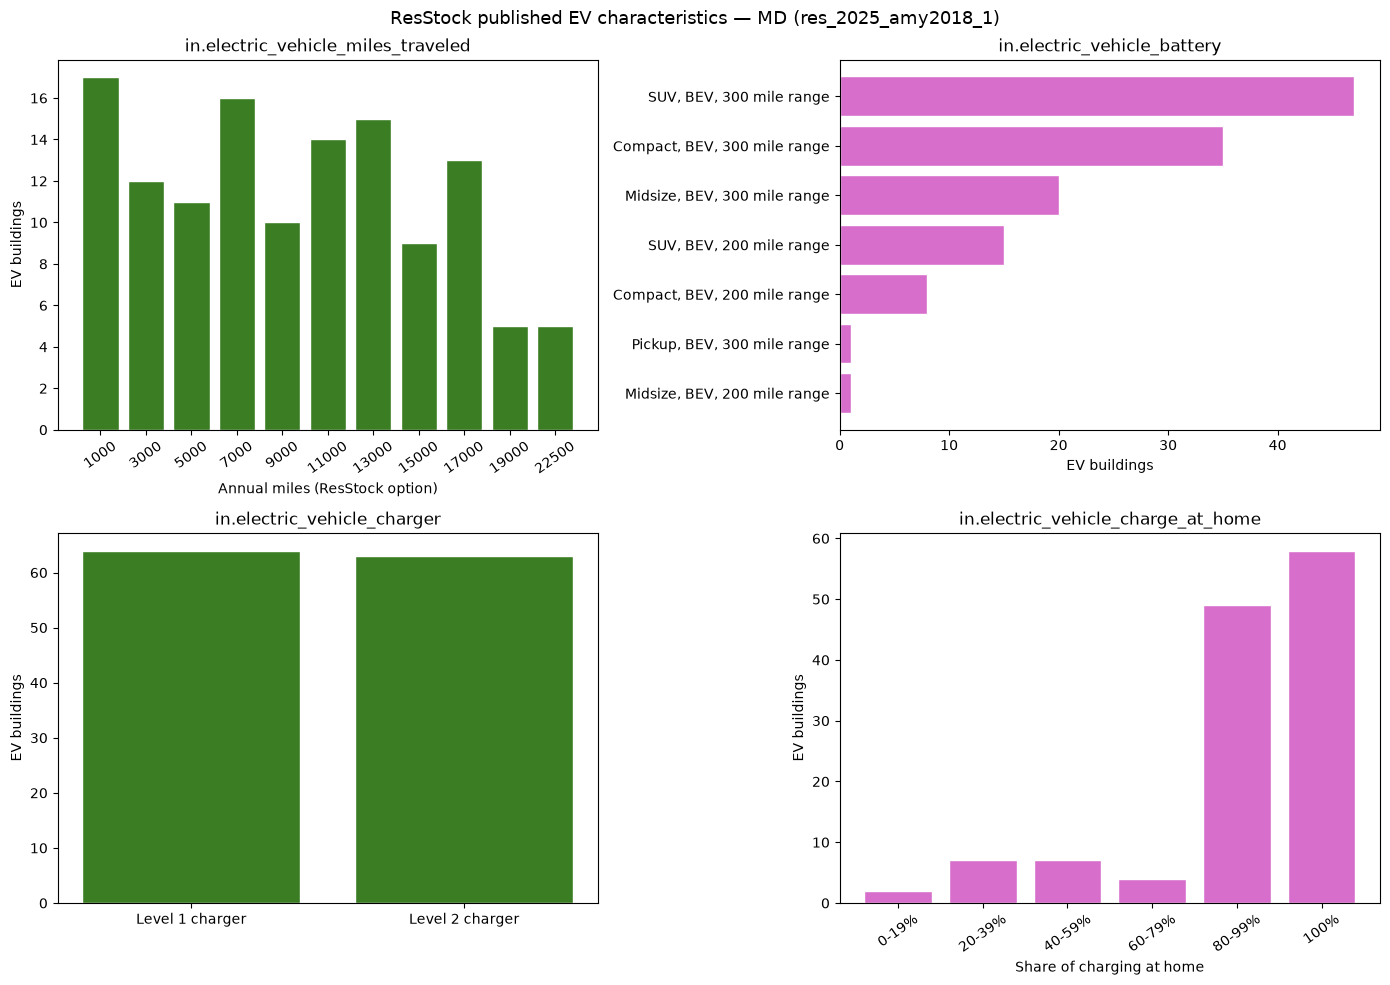

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"ResStock published EV characteristics — {STATE} ({RELEASE_2025})",
    fontsize=13,
)

ax = axes[0, 0]
mile_levels = sorted(ev_chars_2025["annual_miles"].unique().to_list())
mile_counts = [
    int((ev_chars_2025["annual_miles"] == m).sum()) for m in mile_levels
]
ax.bar(
    [str(int(m)) for m in mile_levels],
    mile_counts,
    color=COLOR_GREEN,
    edgecolor="white",
)
ax.set_xlabel("Annual miles (ResStock option)")
ax.set_ylabel("EV buildings")
ax.set_title("in.electric_vehicle_miles_traveled")
ax.tick_params(axis="x", labelrotation=35)

ax = axes[0, 1]
batt_order = (
    ev_chars_2025.group_by("battery_short")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)
ax.barh(
    batt_order["battery_short"].to_list()[::-1],
    batt_order["n"].to_list()[::-1],
    color=COLOR_PINK,
    edgecolor="white",
)
ax.set_xlabel("EV buildings")
ax.set_title("in.electric_vehicle_battery")

ax = axes[1, 0]
chg = (
    ev_chars_2025.group_by("charger")
    .agg(pl.len().alias("n"))
    .sort("charger")
)
ax.bar(chg["charger"].to_list(), chg["n"].to_list(), color=COLOR_GREEN, edgecolor="white")
ax.set_ylabel("EV buildings")
ax.set_title("in.electric_vehicle_charger")

ax = axes[1, 1]
home_order = ["0-19%", "20-39%", "40-59%", "60-79%", "80-99%", "100%"]
home_counts = ev_chars_2025.group_by("charge_at_home").agg(pl.len().alias("n"))
home_map = dict(
    zip(home_counts["charge_at_home"].to_list(), home_counts["n"].to_list(), strict=False)
)
ax.bar(
    home_order,
    [home_map.get(h, 0) for h in home_order],
    color=COLOR_PINK,
    edgecolor="white",
)
ax.set_xlabel("Share of charging at home")
ax.set_ylabel("EV buildings")
ax.set_title("in.electric_vehicle_charge_at_home")
ax.tick_params(axis="x", labelrotation=35)

fig.tight_layout()
plt.show()


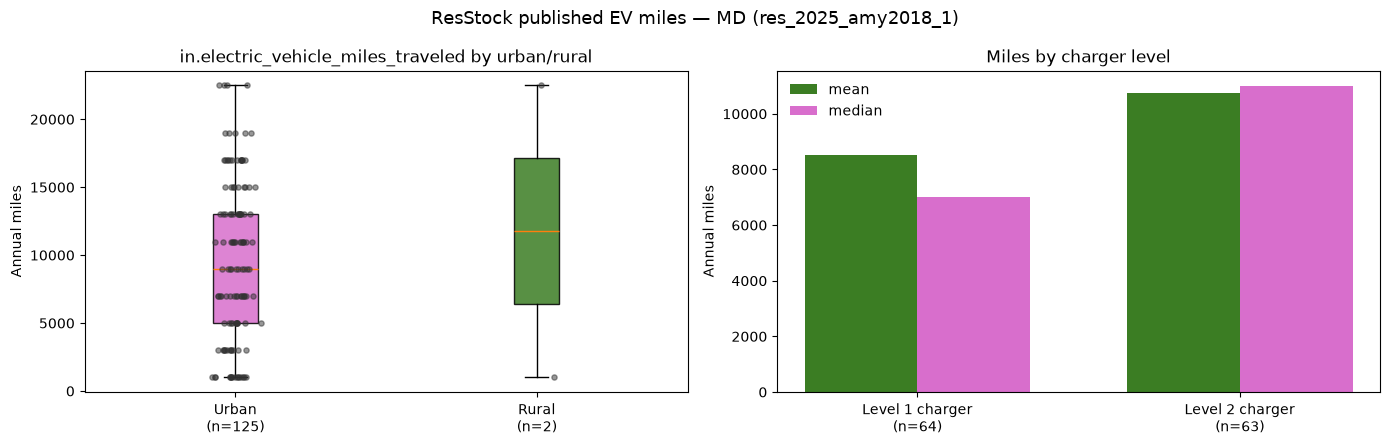

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle(f"ResStock published EV miles — {STATE} ({RELEASE_2025})", fontsize=13)

ax = axes[0]
urban_order = ["Urban", "Rural"]
box_data = [
    ev_chars_2025.filter(pl.col("urban_label") == g)["annual_miles"].to_numpy()
    for g in urban_order
]
bp = ax.boxplot(
    box_data,
    tick_labels=[f"{g}\n(n={len(v)})" for g, v in zip(urban_order, box_data, strict=True)],
    showfliers=False,
    patch_artist=True,
)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(COLOR_PINK if i % 2 == 0 else COLOR_GREEN)
    patch.set_alpha(0.85)
# Overlay raw draws: rural is only a couple of buildings, so the box alone misleads
jitter_rng = np.random.default_rng(SEED)
for i, vals in enumerate(box_data):
    ax.scatter(
        jitter_rng.normal(i + 1, 0.04, size=len(vals)),
        vals,
        s=14,
        color="#333333",
        alpha=0.5,
        zorder=3,
    )
ax.set_ylabel("Annual miles")
ax.set_title("in.electric_vehicle_miles_traveled by urban/rural")

ax = axes[1]
# Mean annual miles by charger level (ResStock's own pairing)
by_chg = (
    ev_chars_2025.group_by("charger")
    .agg(
        pl.len().alias("n"),
        pl.col("annual_miles").mean().alias("mean_miles"),
        pl.col("annual_miles").median().alias("median_miles"),
    )
    .sort("charger")
)
x = np.arange(by_chg.height)
width = 0.35
ax.bar(x - width / 2, by_chg["mean_miles"].to_list(), width, label="mean", color=COLOR_GREEN)
ax.bar(x + width / 2, by_chg["median_miles"].to_list(), width, label="median", color=COLOR_PINK)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n(n={n})" for c, n in zip(by_chg["charger"].to_list(), by_chg["n"].to_list(), strict=True)]
)
ax.set_ylabel("Annual miles")
ax.set_title("Miles by charger level")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


Example building 3870 vehicle 1: 7895 annual miles, 732 trips


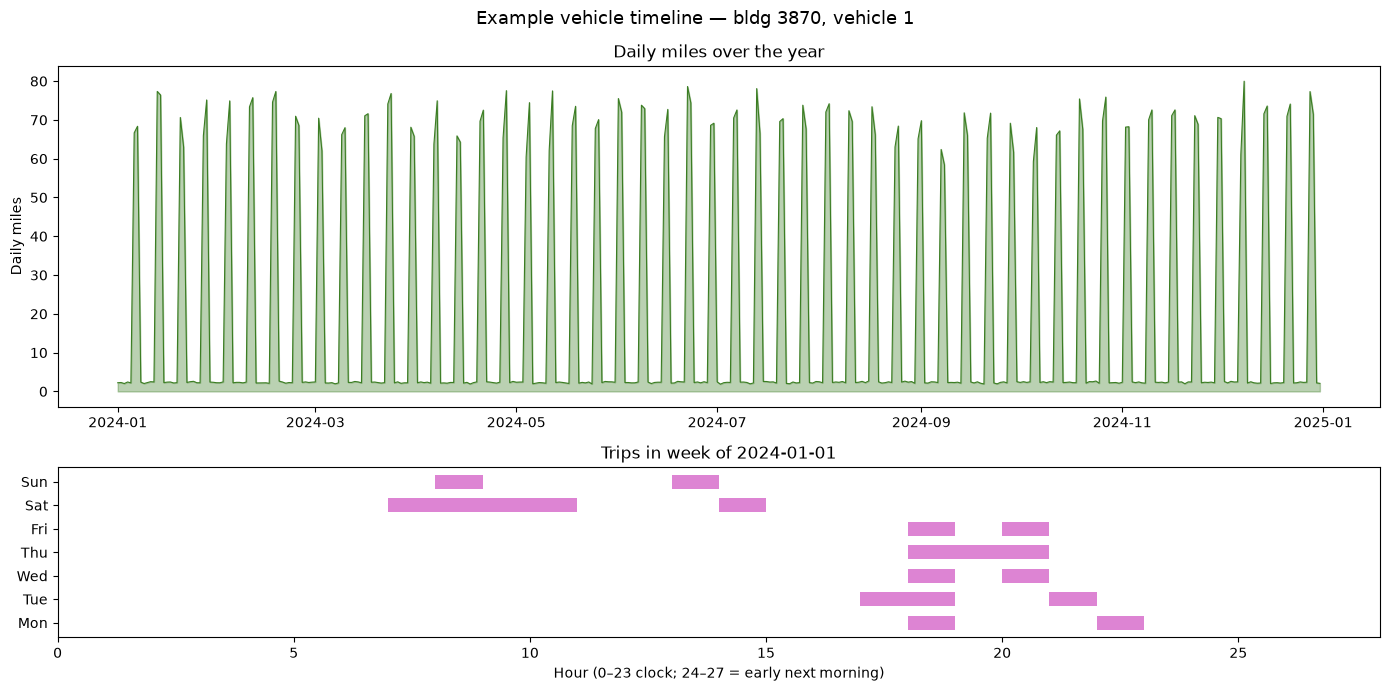

In [27]:
# Example vehicle: daily miles over the year + a one-week trip strip
from datetime import timedelta

example_key = next(k for k, p in vehicle_profiles.items() if p.weekday.has_trips and p.weekend.has_trips)
example_bldg, example_vid = example_key
example_daily = (
    daily_miles.filter((pl.col("bldg_id") == example_bldg) & (pl.col("vehicle_id") == example_vid))
    .sort("travel_date")
)
example_trips = trip_schedules.filter(
    (pl.col("bldg_id") == example_bldg) & (pl.col("vehicle_id") == example_vid)
).sort("travel_date", "trip_departure_hour")

print(
    f"Example building {example_bldg} vehicle {example_vid}: "
    f"{example_daily['daily_miles'].sum():.0f} annual miles, "
    f"{example_trips.height:,} trips"
)

# First Monday travel day in the year (iso weekday: Mon=1)
week_monday = (
    example_daily.filter(pl.col("iso_weekday") == 1).sort("travel_date")["travel_date"].to_list()[0]
)
week_end = week_monday + timedelta(days=7)
week_trips = example_trips.filter(
    (pl.col("travel_date") >= week_monday) & (pl.col("travel_date") < week_end)
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [2, 1]})
fig.suptitle(f"Example vehicle timeline — bldg {example_bldg}, vehicle {example_vid}", fontsize=13)

ax = axes[0]
ax.fill_between(
    example_daily["travel_date"].to_numpy(),
    example_daily["daily_miles"].to_numpy(),
    color=COLOR_GREEN,
    alpha=0.35,
)
ax.plot(
    example_daily["travel_date"].to_numpy(),
    example_daily["daily_miles"].to_numpy(),
    color=COLOR_GREEN,
    linewidth=0.8,
)
ax.set_ylabel("Daily miles")
ax.set_title("Daily miles over the year")

ax = axes[1]
for row in week_trips.iter_rows(named=True):
    day_offset = (row["travel_date"] - week_monday).days
    # trip_* hours are clock hours on their own calendar date; re-extend onto the
    # travel-day axis (4..27) so post-midnight legs stay on their travel day's row.
    dep = float(row["trip_departure_hour"]) + 24.0 * (
        row["trip_departure_date"] - row["travel_date"]
    ).days
    arr = float(row["trip_arrival_hour"]) + 24.0 * (
        row["trip_arrival_date"] - row["travel_date"]
    ).days
    ax.barh(day_offset, max(arr - dep, 0.5), left=dep, height=0.6, color=COLOR_PINK, alpha=0.85)
ax.set_yticks(range(7))
ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xlim(0, 28)
ax.set_xlabel("Hour (0–23 clock; 24–27 = early next morning)")
ax.set_title(f"Trips in week of {week_monday.date()}")

fig.tight_layout()
plt.show()


## 6. EV battery / vehicle-type assignment

ResStock defines **8** national BEV options (4 body classes × 200/300-mile range) with stock
shares from Experian/TEMPO. After trip schedules are generated, we build hourly
**temperature-scaled duty miles** once (same path as `ev_demand.py`):

`temp_scaled_miles[h] = miles_share[h] × power_mult(T_h)`

Every assigned EV slot gets a pack — including vehicles matched to empty NHTS templates
(no trip rows → `max_daily_duty_miles = 0` → smallest feasible option). Each EV draws
from the national prior **conditioned on feasibility**: usable pack must cover

`max_daily_duty_miles × kWh/mi × (1 + buffer)`

with `capacity_buffer_fraction` from the config (default 0.2). Pack sizing uses **full**
trip duty (not scaled by home-charging fraction) — the battery must cover physical driving
energy. The hourly duty frame is reused later for residential SOC as

`discharge_kWh = duty_miles × kWh/mi × fraction_charged_home`

(§7 assigns the fraction; outdoor-temp scaling is not recomputed).

Below: national prior shares vs what this MD sample actually draws.


In [28]:
# National prior + Autonomie physics tables
ev_battery_df = load_ev_battery_lookup(config.ev_battery_path)
ev_autonomie_df = load_ev_autonomie_params(config.ev_autonomie_path)

prior_options = (
    ev_battery_df.join(ev_autonomie_df, on="ev_option_name", how="left")
    .with_columns(
        (
            pl.col("body_class") + " " + pl.col("range_miles").cast(pl.Utf8) + "-mi"
        ).alias("option_short"),
    )
    .sort("probability", descending=True)
)

print(f"ResStock BEV options: {prior_options.height}")
print(f"Prior probabilities sum: {prior_options['probability'].sum():.6f}")
print(f"Capacity buffer fraction: {config.capacity_buffer_fraction}")
print(f"Temperature adjustment: {config.temperature_adjustment}")
display(
    prior_options.select(
        "option_short",
        "ev_option_name",
        "probability",
        "body_class",
        "range_miles",
        "battery_capacity_kwh",
        "kwh_per_mile",
    )
)


ResStock BEV options: 8
Prior probabilities sum: 1.000000
Capacity buffer fraction: 0.2
Temperature adjustment: resstock


option_short,ev_option_name,probability,body_class,range_miles,battery_capacity_kwh,kwh_per_mile
str,str,f64,str,i64,f64,f64
"""Compact 300-mi""","""Compact, Battery Electric Vehi…",0.339087,"""Compact""",300,63.433,0.22002
"""SUV 300-mi""","""SUV, Battery Electric Vehicle,…",0.306398,"""SUV""",300,83.68,0.278934
"""SUV 200-mi""","""SUV, Battery Electric Vehicle,…",0.122608,"""SUV""",200,53.503,0.267513
"""Compact 200-mi""","""Compact, Battery Electric Vehi…",0.11868,"""Compact""",200,40.168,0.209901
"""Midsize 300-mi""","""Midsize, Battery Electric Vehi…",0.0760135,"""Midsize""",300,65.441,0.229449
"""Midsize 200-mi""","""Midsize, Battery Electric Vehi…",0.0295077,"""Midsize""",200,41.978,0.219174
"""Pickup 300-mi""","""Pickup, Battery Electric Vehic…",0.007651,"""Pickup""",300,105.946,0.373794
"""Pickup 200-mi""","""Pickup, Battery Electric Vehic…",0.000055,"""Pickup""",200,67.738,0.357648


In [29]:
# Stock-conditional assignment from temp-scaled duty miles (matches ev_demand.py)
assert config.start_date is not None and config.end_date is not None
hours_base = build_hours_base(config.start_date, config.end_date)

# Authoritative EV slot list (includes vehicles matched to empty NHTS templates).
vehicle_slots = pl.DataFrame({
    "bldg_id": [k[0] for k in vehicle_profiles],
    "vehicle_id": [k[1] for k in vehicle_profiles],
})
# Keep dtypes aligned with trip_schedules / metadata (ResStock bldg_id is Int64 here).
if vehicle_slots.height and trip_schedules.height:
    vehicle_slots = vehicle_slots.with_columns(
        pl.col("bldg_id").cast(trip_schedules.schema["bldg_id"]),
        pl.col("vehicle_id").cast(trip_schedules.schema["vehicle_id"]),
    )

# Outdoor temps when temperature_adjustment=resstock (default weather_dir from config).
# Load for every EV building — not just those with trip rows.
hourly_temp_f_by_bldg = None
if config.temperature_adjustment == "resstock":
    assert config.weather_dir is not None
    weather_map = load_weather_station_map()
    station_temps = load_station_temps_for_buildings(
        metadata_df["bldg_id"],
        state=config.state,
        release=config.release,
        weather_dir=config.weather_dir,
        weather_map=weather_map,
    )
    hourly_temp_f_by_bldg = load_hourly_temp_f_for_buildings(
        vehicle_slots["bldg_id"].unique(),
        hours_base=hours_base,
        state=config.state,
        release=config.release,
        weather_dir=config.weather_dir,
        weather_map=weather_map,
        station_temps=station_temps,
    )
    print(
        f"Loaded outdoor temps for {hourly_temp_f_by_bldg['bldg_id'].n_unique():,} "
        f"EV building(s) from {config.weather_dir}"
    )

# One expand + optional power_mult(T); reused for sizing and later SOC discharge.
# Never-driven vehicles have no trip rows → absent from this frame (duty miles = 0 below).
hourly_temp_scaled_miles = ChargingSimulator.build_hourly_temp_scaled_miles(
    trip_schedules,
    hours_base,
    hourly_temp_f_by_bldg=hourly_temp_f_by_bldg,
)
max_miles = ChargingSimulator.max_daily_miles_from_hourly_temp_scaled(
    hourly_temp_scaled_miles
)

# Left-join onto all slots so idle EVs get max_daily_miles=0 and a feasible small pack.
vehicle_duty = (
    vehicle_slots.join(max_miles, on=["bldg_id", "vehicle_id"], how="left")
    .with_columns(pl.col("max_daily_miles").fill_null(0.0))
)

# Compare duty miles vs raw peak daily miles (diagnostic only; driven vehicles).
raw_max_miles = TripScheduleGenerator.max_daily_miles_from_trip_schedules(trip_schedules)
duty_vs_raw = (
    vehicle_duty.rename({"max_daily_miles": "duty_miles"})
    .join(raw_max_miles, on=["bldg_id", "vehicle_id"], how="left")
    .with_columns(
        pl.when(pl.col("max_daily_miles").is_not_null() & (pl.col("max_daily_miles") > 0))
        .then(pl.col("duty_miles") / pl.col("max_daily_miles"))
        .otherwise(None)
        .alias("temp_scale")
    )
)
n_idle_slots = int((vehicle_duty["max_daily_miles"] <= 0).sum())
driven_duty = duty_vs_raw.filter(pl.col("duty_miles") > 0)["duty_miles"]
scale = duty_vs_raw["temp_scale"].drop_nulls()
scale_str = f"{scale.mean():.2f}" if scale.len() else "n/a"
driven_mean = f"{driven_duty.mean():.1f}" if driven_duty.len() else "n/a"
print(
    f"Duty miles {'temperature-scaled' if hourly_temp_f_by_bldg is not None else 'unscaled'}: "
    f"{vehicle_duty.height:,} slots ({n_idle_slots:,} with 0 duty miles)  "
    f"driven mean duty={driven_mean}  mean scale={scale_str}"
)

battery_assigner = EVBatteryAssigner(
    option_probabilities=ev_battery_df,
    autonomie_params=ev_autonomie_df,
    random_state=SEED,
)
ev_attributes = battery_assigner.assign(
    vehicle_duty,
    buffer_fraction=config.capacity_buffer_fraction,
).join(
    prior_options.select("ev_option_name", "option_short"),
    on="ev_option_name",
    how="left",
)

print(f"Assigned battery attributes for {ev_attributes.height:,} EV slot(s)")
display(
    ev_attributes.select(
        "bldg_id",
        "vehicle_id",
        "max_daily_miles",
        "option_short",
        "body_class",
        "range_miles",
        "battery_capacity_kwh",
        "kwh_per_mile",
    ).head(10)
)


Loaded outdoor temps for 178 EV building(s) from /ebs/home/lily_switch_box/buildstock-fetch/utils/EVs/ev_data/inputs/res_2024_tmy3_2/weather/MD
Duty miles temperature-scaled: 178 slots (0 with 0 duty miles)  driven mean duty=62.7  mean scale=1.56
Assigned battery attributes for 178 EV slot(s)


bldg_id,vehicle_id,max_daily_miles,option_short,body_class,range_miles,battery_capacity_kwh,kwh_per_mile
i64,i64,f64,str,str,i64,f64,f64
3870,1,123.263148,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
5498,1,113.412976,"""Compact 300-mi""","""Compact""",300,63.433,0.22002
7790,1,21.368319,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
8734,1,138.904443,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
14133,1,127.912131,"""Compact 200-mi""","""Compact""",200,40.168,0.209901
22397,1,19.544563,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
24550,1,17.514284,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
35081,1,97.621053,"""SUV 300-mi""","""SUV""",300,83.68,0.278934
37980,1,195.832483,"""Compact 300-mi""","""Compact""",300,63.433,0.22002


In [30]:
# Prior vs sampled option shares
n_assigned = ev_attributes.height
sampled_counts = (
    ev_attributes.group_by("ev_option_name", "option_short", "body_class", "range_miles")
    .agg(pl.len().alias("n_sampled"))
    .with_columns((pl.col("n_sampled") / n_assigned).alias("sampled_share"))
)

option_comparison = (
    prior_options.select(
        "ev_option_name",
        "option_short",
        "body_class",
        "range_miles",
        "probability",
        "battery_capacity_kwh",
        "kwh_per_mile",
    )
    .join(sampled_counts, on=["ev_option_name", "option_short", "body_class", "range_miles"], how="left")
    .with_columns(
        pl.col("n_sampled").fill_null(0),
        pl.col("sampled_share").fill_null(0.0),
        (pl.col("probability") * n_assigned).alias("expected_under_prior"),
    )
    .with_columns(
        (pl.col("n_sampled") - pl.col("expected_under_prior")).alias("count_delta"),
        (pl.col("sampled_share") - pl.col("probability")).alias("share_delta"),
    )
    .sort("probability", descending=True)
)

print(f"Assigned EV slots: {n_assigned:,}")
print("Prior (national stock) vs sampled (duty-conditional) shares")
display(
    option_comparison.select(
        "option_short",
        pl.col("probability").round(4).alias("prior_share"),
        pl.col("sampled_share").round(4),
        pl.col("share_delta").round(4),
        "n_sampled",
        pl.col("expected_under_prior").round(1),
        pl.col("count_delta").round(1),
        "battery_capacity_kwh",
        "kwh_per_mile",
    )
)

print("\nBy body class")
display(
    option_comparison.group_by("body_class")
    .agg(
        pl.col("probability").sum().round(4).alias("prior_share"),
        pl.col("sampled_share").sum().round(4).alias("sampled_share"),
        pl.col("n_sampled").sum().alias("n_sampled"),
    )
    .with_columns((pl.col("sampled_share") - pl.col("prior_share")).round(4).alias("share_delta"))
    .sort("prior_share", descending=True)
)

print("\nBy range")
display(
    option_comparison.group_by("range_miles")
    .agg(
        pl.col("probability").sum().round(4).alias("prior_share"),
        pl.col("sampled_share").sum().round(4).alias("sampled_share"),
        pl.col("n_sampled").sum().alias("n_sampled"),
    )
    .with_columns((pl.col("sampled_share") - pl.col("prior_share")).round(4).alias("share_delta"))
    .sort("range_miles")
)

print("\nAssigned pack summary")
display(
    ev_attributes.select("battery_capacity_kwh", "kwh_per_mile", "range_miles", "max_daily_miles").describe()
)


Assigned EV slots: 178
Prior (national stock) vs sampled (duty-conditional) shares


option_short,prior_share,sampled_share,share_delta,n_sampled,expected_under_prior,count_delta,battery_capacity_kwh,kwh_per_mile
str,f64,f64,f64,u32,f64,f64,f64,f64
"""Compact 300-mi""",0.3391,0.3483,0.0092,62,60.4,1.6,63.433,0.22002
"""SUV 300-mi""",0.3064,0.2921,-0.0143,52,54.5,-2.5,83.68,0.278934
"""SUV 200-mi""",0.1226,0.118,-0.0046,21,21.8,-0.8,53.503,0.267513
"""Compact 200-mi""",0.1187,0.118,-0.0007,21,21.1,-0.1,40.168,0.209901
"""Midsize 300-mi""",0.076,0.0562,-0.0198,10,13.5,-3.5,65.441,0.229449
"""Midsize 200-mi""",0.0295,0.0506,0.0211,9,5.3,3.7,41.978,0.219174
"""Pickup 300-mi""",0.0077,0.0169,0.0092,3,1.4,1.6,105.946,0.373794
"""Pickup 200-mi""",0.0001,0.0,-0.0001,0,0.0,-0.0,67.738,0.357648



By body class


body_class,prior_share,sampled_share,n_sampled,share_delta
str,f64,f64,u32,f64
"""Compact""",0.4578,0.4663,83,0.0085
"""SUV""",0.429,0.4101,73,-0.0189
"""Midsize""",0.1055,0.1067,19,0.0012
"""Pickup""",0.0077,0.0169,3,0.0092



By range


range_miles,prior_share,sampled_share,n_sampled,share_delta
i64,f64,f64,u32,f64
200,0.2709,0.2865,51,0.0156
300,0.7291,0.7135,127,-0.0156



Assigned pack summary


statistic,battery_capacity_kwh,kwh_per_mile,range_miles,max_daily_miles
str,f64,f64,f64,f64
"""count""",178.0,178.0,178.0,178.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",65.176107,0.244719,271.348315,62.724112
"""std""",15.734108,0.033043,45.340919,48.641244
"""min""",40.168,0.209901,200.0,4.552732
"""25%""",53.503,0.22002,200.0,26.251774
"""50%""",63.433,0.22002,300.0,45.485848
"""75%""",83.68,0.278934,300.0,89.105189
"""max""",105.946,0.373794,300.0,201.745427


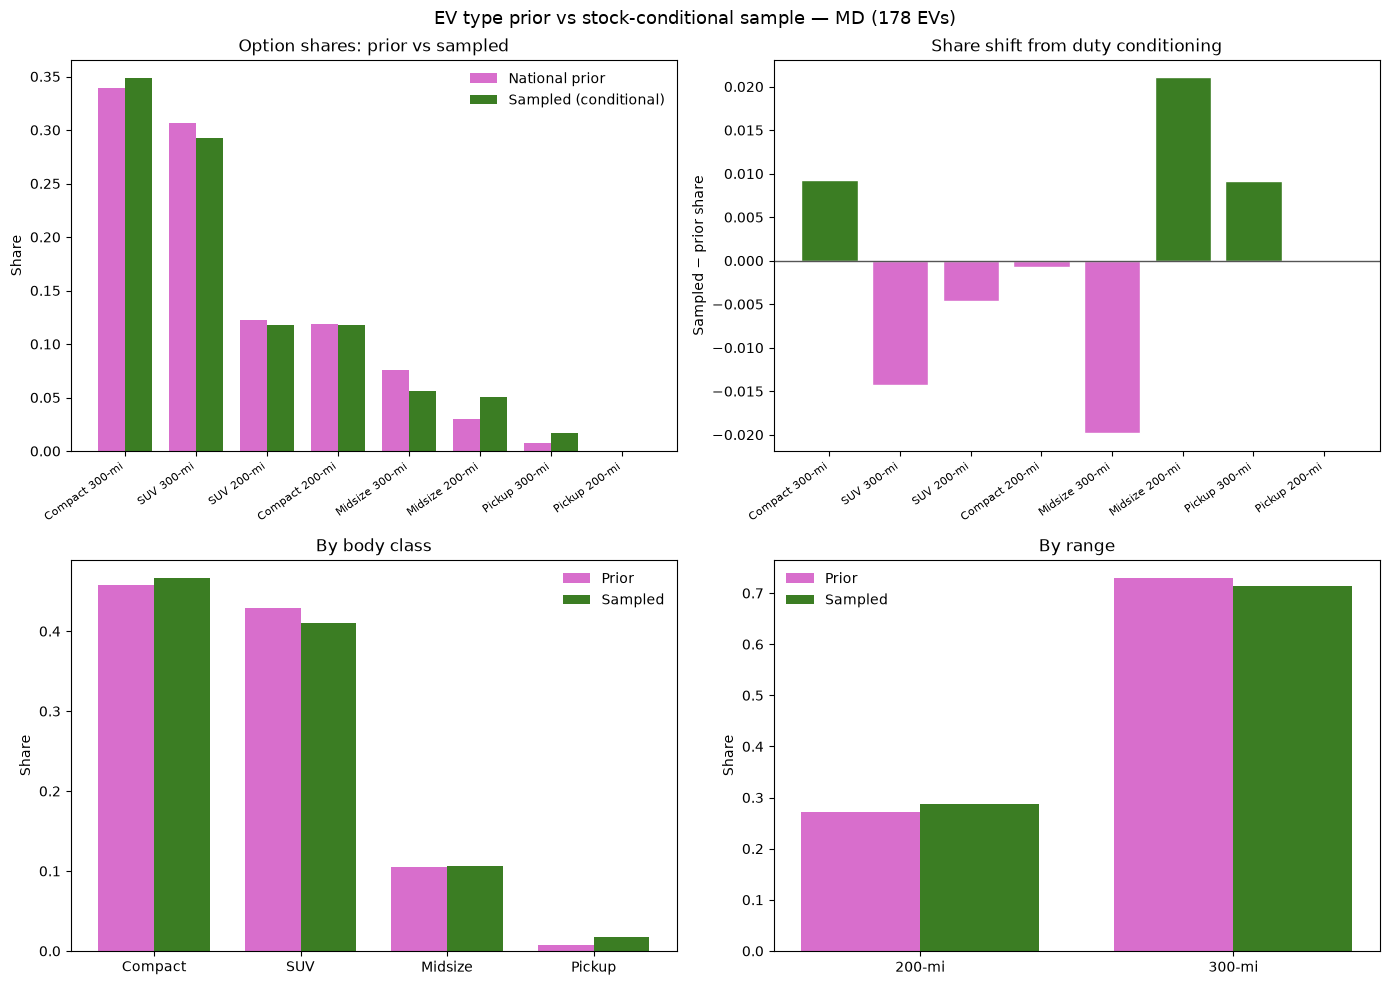

In [31]:
# Prior vs sampled: grouped bars by option, plus body-class and range rollups
option_order = option_comparison.sort("probability", descending=True)["option_short"].to_list()
x = np.arange(len(option_order))
width = 0.38
prior_vals = [
    float(option_comparison.filter(pl.col("option_short") == o)["probability"][0])
    for o in option_order
]
sampled_vals = [
    float(option_comparison.filter(pl.col("option_short") == o)["sampled_share"][0])
    for o in option_order
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"EV type prior vs stock-conditional sample — {STATE} ({n_assigned} EVs)",
    fontsize=13,
)

ax = axes[0, 0]
ax.bar(x - width / 2, prior_vals, width, label="National prior", color=COLOR_PINK)
ax.bar(x + width / 2, sampled_vals, width, label="Sampled (conditional)", color=COLOR_GREEN)
ax.set_xticks(x)
ax.set_xticklabels(option_order, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Share")
ax.set_title("Option shares: prior vs sampled")
ax.legend(frameon=False)

ax = axes[0, 1]
deltas = np.array(sampled_vals) - np.array(prior_vals)
bar_colors = [COLOR_GREEN if d >= 0 else COLOR_PINK for d in deltas]
ax.bar(x, deltas, color=bar_colors, edgecolor="white")
ax.axhline(0, color="#555555", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(option_order, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("Sampled − prior share")
ax.set_title("Share shift from duty conditioning")

# Body class rollup
body = (
    option_comparison.group_by("body_class")
    .agg(
        pl.col("probability").sum().alias("prior_share"),
        pl.col("sampled_share").sum().alias("sampled_share"),
    )
    .sort("prior_share", descending=True)
)
bx = np.arange(body.height)
ax = axes[1, 0]
ax.bar(bx - width / 2, body["prior_share"].to_numpy(), width, label="Prior", color=COLOR_PINK)
ax.bar(bx + width / 2, body["sampled_share"].to_numpy(), width, label="Sampled", color=COLOR_GREEN)
ax.set_xticks(bx)
ax.set_xticklabels(body["body_class"].to_list())
ax.set_ylabel("Share")
ax.set_title("By body class")
ax.legend(frameon=False)

# Range rollup
rng = (
    option_comparison.group_by("range_miles")
    .agg(
        pl.col("probability").sum().alias("prior_share"),
        pl.col("sampled_share").sum().alias("sampled_share"),
    )
    .sort("range_miles")
)
rx = np.arange(rng.height)
ax = axes[1, 1]
ax.bar(rx - width / 2, rng["prior_share"].to_numpy(), width, label="Prior", color=COLOR_PINK)
ax.bar(rx + width / 2, rng["sampled_share"].to_numpy(), width, label="Sampled", color=COLOR_GREEN)
ax.set_xticks(rx)
ax.set_xticklabels([f"{r}-mi" for r in rng["range_miles"].to_list()])
ax.set_ylabel("Share")
ax.set_title("By range")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()


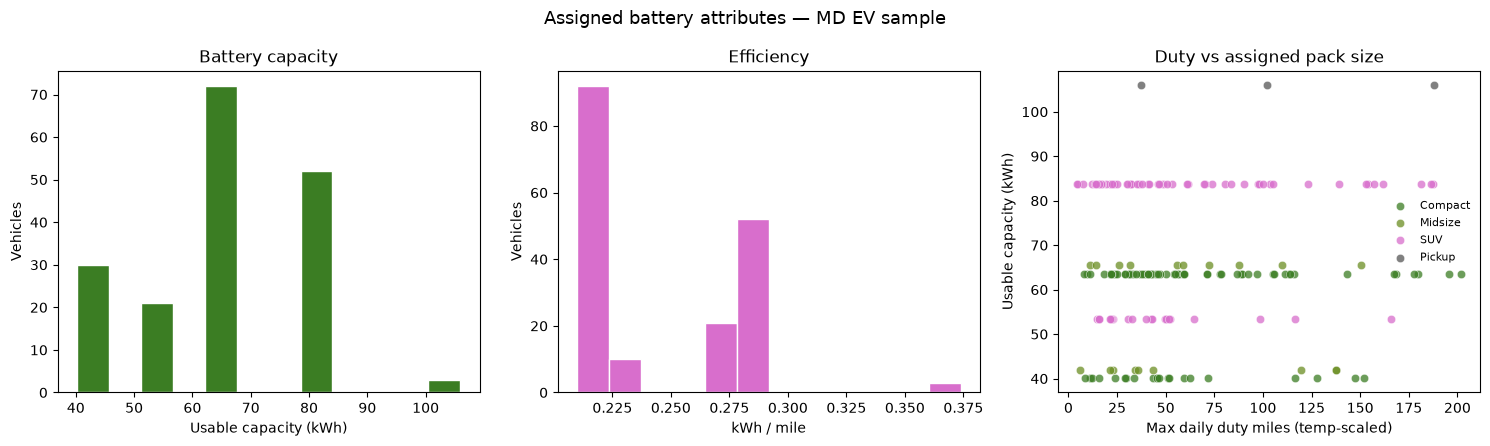

Miles headroom = usable range − max daily duty miles (duty miles are temperature-scaled when config.temperature_adjustment=resstock)


statistic,miles_headroom,max_daily_miles,battery_capacity_kwh,range_miles,required_over_capacity
str,f64,f64,f64,f64,f64
"""count""",178.0,178.0,178.0,178.0,178.0
"""null_count""",0.0,0.0,0.0,0.0,0.0
"""mean""",201.993788,62.724112,65.176107,271.348315,0.289201
"""std""",62.324833,48.641244,15.734108,45.340919,0.226168
"""min""",34.408249,4.552732,40.168,200.0,0.018211
"""25%""",157.635751,26.251774,53.503,200.0,0.128793
"""50%""",209.917408,45.485848,63.433,300.0,0.21476
"""75%""",255.343627,89.105189,83.68,300.0,0.38678
"""max""",295.446551,201.745427,105.946,300.0,0.993552


All packs cover duty×η×(1+buffer): True


In [32]:
# Assigned pack characteristics
BODY_COLORS = {
    "Compact": COLOR_GREEN,
    "Midsize": "#6B8E23",
    "SUV": COLOR_PINK,
    "Pickup": "#555555",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(f"Assigned battery attributes — {STATE} EV sample", fontsize=13)

ax = axes[0]
ax.hist(ev_attributes["battery_capacity_kwh"].to_numpy(), bins=12, color=COLOR_GREEN, edgecolor="white")
ax.set_xlabel("Usable capacity (kWh)")
ax.set_ylabel("Vehicles")
ax.set_title("Battery capacity")

ax = axes[1]
ax.hist(ev_attributes["kwh_per_mile"].to_numpy(), bins=12, color=COLOR_PINK, edgecolor="white")
ax.set_xlabel("kWh / mile")
ax.set_ylabel("Vehicles")
ax.set_title("Efficiency")

ax = axes[2]
for body, color in BODY_COLORS.items():
    sub = ev_attributes.filter(pl.col("body_class") == body)
    if sub.is_empty():
        continue
    ax.scatter(
        sub["max_daily_miles"].to_numpy(),
        sub["battery_capacity_kwh"].to_numpy(),
        c=color,
        label=body,
        alpha=0.75,
        edgecolors="white",
        linewidths=0.4,
    )
ax.set_xlabel("Max daily duty miles (temp-scaled)")
ax.set_ylabel("Usable capacity (kWh)")
ax.set_title("Duty vs assigned pack size")
ax.legend(frameon=False, fontsize=8)

fig.tight_layout()
plt.show()

# Headroom vs the same duty miles used for sizing (not raw miles).
headroom = ev_attributes.with_columns(
    (
        pl.col("battery_capacity_kwh")
        / pl.col("kwh_per_mile")
        - pl.col("max_daily_miles")
    ).alias("miles_headroom"),
    (
        pl.col("max_daily_miles")
        * pl.col("kwh_per_mile")
        * (1.0 + config.capacity_buffer_fraction)
        / pl.col("battery_capacity_kwh")
    ).alias("required_over_capacity"),
)
print(
    "Miles headroom = usable range − max daily duty miles "
    "(duty miles are temperature-scaled when config.temperature_adjustment=resstock)"
)
display(
    headroom.select(
        "miles_headroom",
        "max_daily_miles",
        "battery_capacity_kwh",
        "range_miles",
        "required_over_capacity",
    ).describe()
)
print(
    f"All packs cover duty×η×(1+buffer): "
    f"{bool((headroom['required_over_capacity'] <= 1.0 + 1e-9).all())}"
)


## 7. Home-charging fraction (residential meter share)

Not all EV energy shows up on the residential meter. ResStock samples
`Electric Vehicle Charge At Home` from EIA 2020 RECS, conditioned on **FPL** and
**building type** (Speake et al. 2025 §3.5). Each bin maps to a midpoint scalar
`ev_fraction_charged_home` via `options_lookup`:

| Bin | Fraction |
|---|---|
| 0–19% | 0.10 |
| 20–39% | 0.30 |
| 40–59% | 0.50 |
| 60–79% | 0.70 |
| 80–99% | 0.90 |
| 100% | 1.00 |

That scalar multiplies **home-attributed discharge** only:

`discharge_kWh = duty_miles × kWh/mi × fraction_charged_home`

- **Battery sizing (§6)** stays on full duty — packs cover physical driving.
- **Charger feasibility (§8)** and **SOC / residential load (§9+)** use scaled discharge.
- Charger **power** is unchanged; away charging is excluded by shrinking home discharge,
  not by modeling workplace charge events.

This matches `home_charging_fraction_assignment: resstock` in `ev_demand.py`.

Below: **lookup expected fraction** (Σ p_bin × midpoint from the ResStock TSV cell
each EV sits in) vs **sampled** `fraction_charged_home` by FPL and building type, plus
stacked bin shares (expected mix vs realized draws).


In [33]:
# Home-charging fraction assignment (matches ev_demand.py home_charging_fraction_assignment=resstock)
assert config.home_charging_fraction_assignment == "resstock", (
    "md_2024.yaml should set home_charging_fraction_assignment=resstock for this section"
)
assert config.ev_charge_at_home_path is not None
charge_at_home_lookup = load_ev_charge_at_home_lookup(config.ev_charge_at_home_path)

print(f"Charge-at-home lookup rows: {charge_at_home_lookup.height:,}")
print(f"config.home_charging_fraction_assignment={config.home_charging_fraction_assignment!r}")
print("Bin → midpoint:", CHARGE_AT_HOME_BIN_TO_FRACTION)

# Drop prior §7 columns if re-running this cell.
ev_attributes = ev_attributes.drop(
    [
        c
        for c in ("charge_at_home_bin", "fraction_charged_home")
        if c in ev_attributes.columns
    ]
)

# FPL × building type join keys (same dependencies as the ResStock TSV).
vehicles_for_home_frac = (
    ev_attributes.select("bldg_id", "vehicle_id")
    .join(
        metadata_df.select("bldg_id", "fpl", "building_type", "weight"),
        on="bldg_id",
        how="left",
    )
)
null_home_meta = vehicles_for_home_frac.filter(
    pl.col("fpl").is_null() | pl.col("building_type").is_null()
)
assert null_home_meta.height == 0, (
    f"Missing fpl/building_type for {null_home_meta.height} EV slot(s)"
)

# Join ResStock cell probabilities so we can compare lookup expectation vs draws.
_PROB_COLS = ["p_0_19", "p_20_39", "p_40_59", "p_60_79", "p_80_99", "p_100"]
vehicles_with_home_prob = vehicles_for_home_frac.join(
    charge_at_home_lookup.select("fpl", "building_type", *_PROB_COLS),
    on=["fpl", "building_type"],
    how="left",
)
assert vehicles_with_home_prob.filter(pl.col("p_100").is_null()).height == 0

# Lookup E[fraction] = Σ p_bin × midpoint (Speake / options_lookup mapping).
_expected_frac_expr = sum(
    pl.col(prob_col) * float(CHARGE_AT_HOME_BIN_TO_FRACTION[bin_label])
    for bin_label, prob_col in zip(CHARGE_AT_HOME_BINS, _PROB_COLS, strict=True)
)
vehicles_with_home_prob = vehicles_with_home_prob.with_columns(
    _expected_frac_expr.alias("lookup_expected_fraction")
)

home_frac_assigner = EVHomeChargingFractionAssigner(
    charge_at_home_lookup=charge_at_home_lookup,
    random_state=SEED,
)
home_frac_attrs = home_frac_assigner.assign(vehicles_for_home_frac)

# Merge onto battery attributes before charger assignment / SOC.
ev_attributes = ev_attributes.join(
    home_frac_attrs, on=["bldg_id", "vehicle_id"], how="left"
)
assert ev_attributes["fraction_charged_home"].null_count() == 0

# Keep lookup probs on a compare frame (demographics + expected + sampled).
ev_home_frac_compare = (
    vehicles_with_home_prob.join(
        ev_attributes.select(
            "bldg_id", "vehicle_id", "charge_at_home_bin", "fraction_charged_home"
        ),
        on=["bldg_id", "vehicle_id"],
        how="left",
    )
)

mean_frac = float(ev_attributes["fraction_charged_home"].mean())
mean_lookup = float(ev_home_frac_compare["lookup_expected_fraction"].mean())
print(
    f"Assigned home-charging fractions for {ev_attributes.height:,} EV(s)\n"
    f"  mean lookup E[fraction]={mean_lookup:.3f}  "
    f"mean sampled fraction_charged_home={mean_frac:.3f}"
)
display(
    ev_home_frac_compare.select(
        "bldg_id",
        "vehicle_id",
        "fpl",
        "building_type",
        "lookup_expected_fraction",
        "charge_at_home_bin",
        "fraction_charged_home",
    ).head(10)
)

# Overall bin mix: mean lookup p_bin vs sampled share
overall_bin_compare = pl.DataFrame({
    "charge_at_home_bin": list(CHARGE_AT_HOME_BINS),
    "fraction_midpoint": [CHARGE_AT_HOME_BIN_TO_FRACTION[b] for b in CHARGE_AT_HOME_BINS],
    "lookup_mean_p": [
        float(ev_home_frac_compare[c].mean()) for c in _PROB_COLS
    ],
    "sampled_share": [
        float((ev_attributes["charge_at_home_bin"] == b).mean())
        for b in CHARGE_AT_HOME_BINS
    ],
})
display(overall_bin_compare)


Charge-at-home lookup rows: 35
config.home_charging_fraction_assignment='resstock'
Bin → midpoint: {'0-19%': 0.1, '20-39%': 0.3, '40-59%': 0.5, '60-79%': 0.7, '80-99%': 0.9, '100%': 1.0}
Assigned home-charging fractions for 178 EV(s)
  mean lookup E[fraction]=0.863  mean sampled fraction_charged_home=0.867


bldg_id,vehicle_id,fpl,building_type,lookup_expected_fraction,charge_at_home_bin,fraction_charged_home
i64,i64,str,str,f64,str,f64
3870,1,"""400%+""","""Single-Family Detached""",0.899821,"""100%""",1.0
5498,1,"""300-400%""","""Single-Family Attached""",0.794698,"""80-99%""",0.9
7790,1,"""400%+""","""Single-Family Attached""",0.828471,"""100%""",1.0
8734,1,"""400%+""","""Single-Family Attached""",0.828471,"""80-99%""",0.9
14133,1,"""400%+""","""Single-Family Detached""",0.899821,"""60-79%""",0.7
22397,1,"""400%+""","""Single-Family Detached""",0.899821,"""100%""",1.0
24550,1,"""400%+""","""Single-Family Detached""",0.899821,"""100%""",1.0
35081,1,"""400%+""","""Single-Family Detached""",0.899821,"""100%""",1.0
37980,1,"""400%+""","""Single-Family Detached""",0.899821,"""60-79%""",0.7


charge_at_home_bin,fraction_midpoint,lookup_mean_p,sampled_share
str,f64,f64,f64
"""0-19%""",0.1,0.037361,0.033708
"""20-39%""",0.3,0.049911,0.039326
"""40-59%""",0.5,0.024018,0.033708
"""60-79%""",0.7,0.048118,0.061798
"""80-99%""",0.9,0.42049,0.398876
"""100%""",1.0,0.420102,0.432584


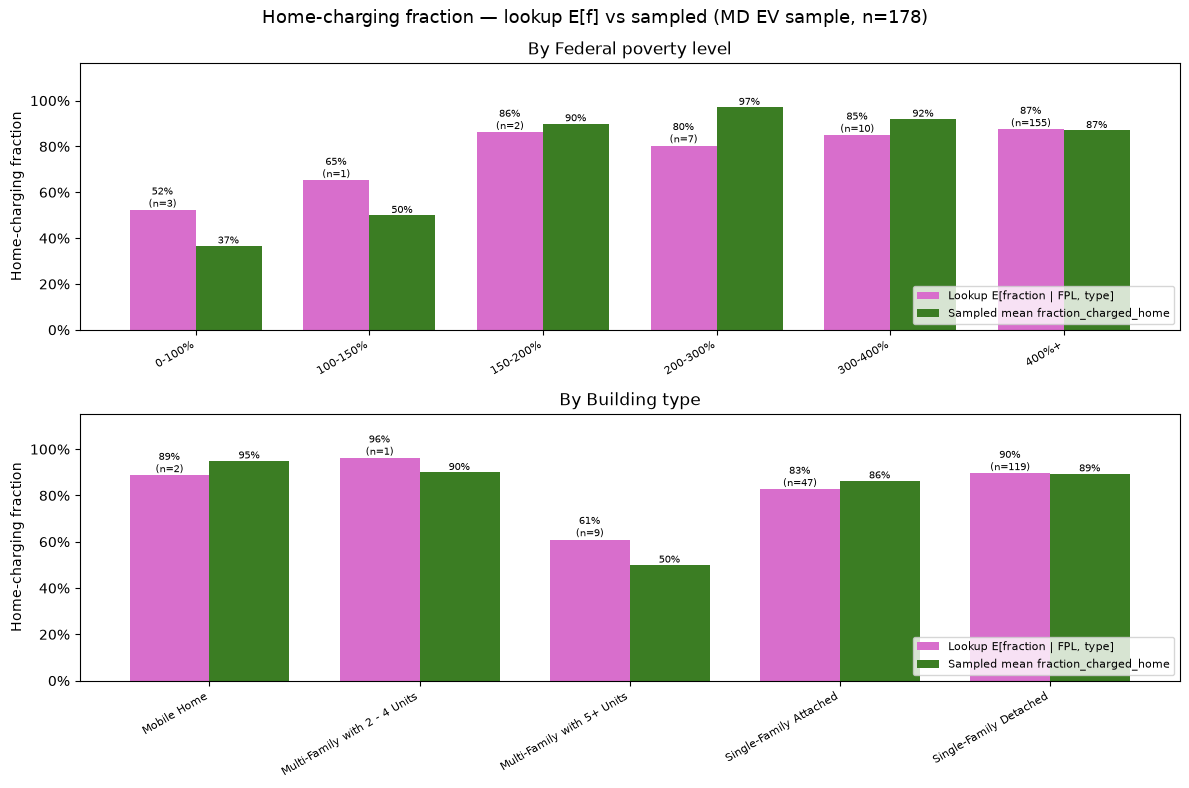

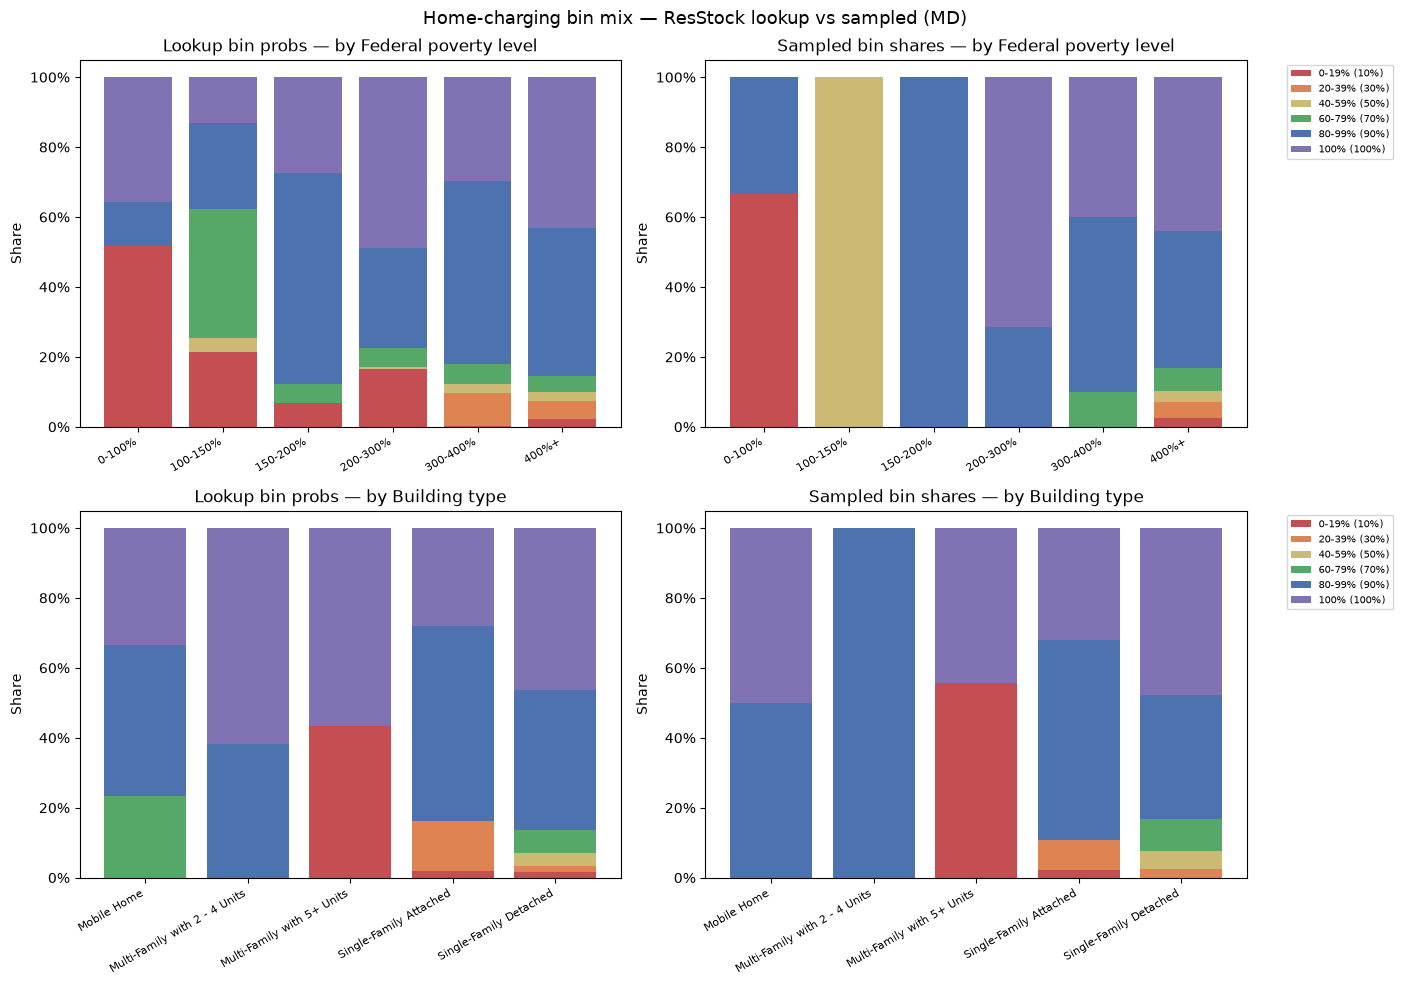

Overall: lookup E[f]=0.863  sampled mean=0.867  (residential discharge ≈ 87% of full trip energy on average)


In [34]:
# Lookup expected fraction vs sampled mean by ResStock categories (FPL, building type).
# Plus stacked bin shares: mean lookup p_bin vs realized draw share within each category.
BIN_COLORS = {
    "0-19%": "#c44e52",
    "20-39%": "#dd8452",
    "40-59%": "#ccb974",
    "60-79%": "#55a868",
    "80-99%": "#4c72b0",
    "100%": "#8172b3",
}
HOME_FRAC_CATEGORIES = ["fpl", "building_type"]
HOME_FRAC_CATEGORY_LABELS = {
    "fpl": "Federal poverty level",
    "building_type": "Building type",
}


def _home_frac_category_order(category: str, labels: list[str]) -> list[str]:
    if category == "fpl":
        return [x for x in FPL_ORDER if x in labels]
    return sorted(labels)


fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle(
    f"Home-charging fraction — lookup E[f] vs sampled "
    f"({STATE} EV sample, n={ev_home_frac_compare.height})",
    fontsize=13,
)
width = 0.38

for ax, category in zip(axes, HOME_FRAC_CATEGORIES, strict=True):
    eligible = ev_home_frac_compare.filter(
        (pl.col("fpl") != "Not Available") & (pl.col(category) != "Not Available")
    )
    summary = (
        eligible.group_by(category)
        .agg(
            pl.col("lookup_expected_fraction").mean().alias("lookup_expected"),
            pl.col("fraction_charged_home").mean().alias("sampled_mean"),
            pl.len().alias("n"),
        )
    )
    order = _home_frac_category_order(category, summary[category].to_list())
    summary = summary.with_columns(
        pl.col(category).cast(pl.Enum(order))
    ).sort(category)

    labels = summary[category].to_list()
    x = np.arange(len(labels))
    lookup_vals = summary["lookup_expected"].to_numpy()
    sampled_vals = summary["sampled_mean"].to_numpy()

    bars1 = ax.bar(
        x - width / 2,
        lookup_vals,
        width,
        label="Lookup E[fraction | FPL, type]",
        color=COLOR_PINK,
    )
    bars2 = ax.bar(
        x + width / 2,
        sampled_vals,
        width,
        label="Sampled mean fraction_charged_home",
        color=COLOR_GREEN,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Home-charging fraction")
    ax.set_ylim(
        0,
        max(0.75, float(np.nanmax(np.concatenate([lookup_vals, sampled_vals]))) * 1.2),
    )
    ax.set_title(f"By {HOME_FRAC_CATEGORY_LABELS[category]}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.legend(fontsize=8, loc="lower right")
    for bar, val, n in zip(bars1, lookup_vals, summary["n"].to_list(), strict=True):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.0%}\n(n={n})",
            ha="center",
            va="bottom",
            fontsize=7,
        )
    for bar, val in zip(bars2, sampled_vals, strict=True):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.0%}",
            ha="center",
            va="bottom",
            fontsize=7,
        )

fig.tight_layout()
plt.show()

# Stacked bin composition: expected (mean lookup p) vs sampled share, side-by-side per category
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f"Home-charging bin mix — ResStock lookup vs sampled ({STATE})",
    fontsize=13,
)

for row, category in enumerate(HOME_FRAC_CATEGORIES):
    eligible = ev_home_frac_compare.filter(
        (pl.col("fpl") != "Not Available") & (pl.col(category) != "Not Available")
    )
    # Expected mix = mean of each ResStock p_bin within the category.
    expected = (
        eligible.group_by(category)
        .agg([pl.col(c).mean().alias(c) for c in _PROB_COLS] + [pl.len().alias("n")])
    )
    # Sampled mix = share of drawn bins within the category.
    sampled = (
        eligible.group_by(category, "charge_at_home_bin")
        .agg(pl.len().alias("n_bin"))
        .with_columns(
            (pl.col("n_bin") / pl.col("n_bin").sum().over(category)).alias("share")
        )
        .pivot(
            on="charge_at_home_bin",
            index=category,
            values="share",
            aggregate_function="first",
        )
        .fill_null(0.0)
    )
    order = _home_frac_category_order(
        category,
        list(set(expected[category].to_list()) | set(sampled[category].to_list())),
    )
    expected = expected.with_columns(pl.col(category).cast(pl.Enum(order))).sort(category)
    sampled = sampled.with_columns(pl.col(category).cast(pl.Enum(order))).sort(category)
    # Align rows (left-join so every category with lookup probs appears).
    sampled = expected.select(category).join(sampled, on=category, how="left").fill_null(0.0)

    labels = expected[category].to_list()
    x = np.arange(len(labels))

    ax_exp = axes[row, 0]
    ax_sam = axes[row, 1]
    bottom_exp = np.zeros(len(labels))
    bottom_sam = np.zeros(len(labels))
    for bin_label, prob_col in zip(CHARGE_AT_HOME_BINS, _PROB_COLS, strict=True):
        h_exp = expected[prob_col].to_numpy().astype(float)
        h_sam = (
            sampled[bin_label].to_numpy().astype(float)
            if bin_label in sampled.columns
            else np.zeros(len(labels))
        )
        label = f"{bin_label} ({CHARGE_AT_HOME_BIN_TO_FRACTION[bin_label]:.0%})"
        ax_exp.bar(x, h_exp, bottom=bottom_exp, color=BIN_COLORS[bin_label], label=label)
        ax_sam.bar(x, h_sam, bottom=bottom_sam, color=BIN_COLORS[bin_label], label=label)
        bottom_exp = bottom_exp + h_exp
        bottom_sam = bottom_sam + h_sam

    for ax, title in (
        (ax_exp, f"Lookup bin probs — by {HOME_FRAC_CATEGORY_LABELS[category]}"),
        (ax_sam, f"Sampled bin shares — by {HOME_FRAC_CATEGORY_LABELS[category]}"),
    ):
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
        ax.set_ylabel("Share")
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
        ax.set_title(title)

    axes[row, 1].legend(fontsize=7, loc="upper right", bbox_to_anchor=(1.28, 1.0))

fig.tight_layout()
plt.show()

print(
    f"Overall: lookup E[f]={mean_lookup:.3f}  sampled mean={mean_frac:.3f}  "
    f"(residential discharge ≈ {mean_frac:.0%} of full trip energy on average)"
)


## 8. Home charger assignment (L1 vs L2)

ResStock samples home charger type from EIA 2020 RECS (`EVCHRGTYPE`), conditioned on
**EV ownership**, **FPL**, **building type**, and **tenure** (Speake et al. 2025 §3.2).
EV homes always get at least Level 1. Pipeline default rated powers:

| Level | Default power |
|---|---|
| Level 1 | 1.6 kW (1600 W) — ResStock TRG |
| Level 2 | 7.2 kW (7200 W) — typical 32 A / 240 V EVSE nameplate |

ResStock's TRG / options_lookup instead uses 5.69 kW for Level 2 (average observed 240 V
draw). Powers come from `config.level1_charger_power_kw` / `level2_charger_power_kw`
(override in `md_2024.yaml` if you want the TRG 5.69 kW Level 2).

Assignment is **duty-conditional** (same idea as stock-conditional batteries): for each EV we
keep only levels that can cover the trip schedule under **perfect SOC foresight** — immediate
home charging with no underflow, after inflating **home-attributed** discharge
(`duty × kWh/mi × fraction_charged_home` from §7) by `config.charger_buffer_fraction`
(default 0.2). Packs were sized on **full** duty in §6; charger feasibility only needs to
cover the residential share. If both L1 and L2 pass, we Bernoulli-draw with the ResStock
cell probabilities; if only one passes, we assign that level. If **neither** passes — no
home charger can keep the vehicle charged (e.g. a multi-day-away schedule with no home
plug) — and `config.exclude_infeasible_charger_profiles` is true, the pipeline
**redraws the NHTS weekday/weekend profile** up to
`config.infeasible_profile_redraw_attempts` times (keeping EV ownership and the
home-charging fraction) before excluding the slot from `ev_attributes` /
`trip_schedules`. Set exclude false to hard-fail instead. This matches
`charger_assignment: resstock` in `ev_demand.py` (`match_and_generate_trip_schedules`).

This notebook cell runs the same **probe → redraw → exclude** path and prints
`charger_redraw_stats` (attempts per infeasible slot, recovered vs excluded).

Below: **lookup P(L2)** on this MD EV sample vs **realized L2 share** after the feasible draw
(realized share can exceed lookup P(L2) when many homes are forced to L2). Downstream charging
(§9+) uses each vehicle's assigned kW and home-scaled discharge.


In [35]:
# ResStock L1/L2 charger assignment (matches ev_demand.py charger_assignment=resstock)
# Duty-conditional: only sample levels that cover trips under perfect SOC foresight.
assert config.ev_charger_path is not None
charger_lookup = load_ev_charger_lookup(config.ev_charger_path)

# Usable Yes-ownership rows (Void kept in the loader; assigner rejects them if joined).
usable_charger = charger_lookup.filter(pl.col("p_void") == 0)
print(f"Charger lookup Yes rows: {charger_lookup.height:,}  (usable L1/L2: {usable_charger.height:,})")
print(
    f"Charger powers: L1={config.level1_charger_power_kw} kW, "
    f"L2={config.level2_charger_power_kw} kW "
    f"(pipeline defaults {RESSTOCK_LEVEL1_CHARGER_KW}/{RESSTOCK_LEVEL2_CHARGER_KW})"
)
print(f"config.charger_assignment={config.charger_assignment!r}")
print(f"config.charger_buffer_fraction={config.charger_buffer_fraction}")
print(
    "config.exclude_infeasible_charger_profiles="
    f"{config.exclude_infeasible_charger_profiles}"
)
print(
    "config.infeasible_profile_redraw_attempts="
    f"{config.infeasible_profile_redraw_attempts}"
)

# Drop prior §8 columns if re-running this cell.
ev_attributes = ev_attributes.drop(
    [c for c in ("charger_level", "charger_power_kw") if c in ev_attributes.columns]
)

# Demographics for the ResStock join + pack size for the SOC feasibility check.
vehicles_with_meta = (
    ev_attributes.select("bldg_id", "vehicle_id", "battery_capacity_kwh")
    .join(
        metadata_df.select("bldg_id", "fpl", "building_type", "tenure", "weight"),
        on="bldg_id",
        how="left",
    )
)
null_meta = vehicles_with_meta.filter(
    pl.col("fpl").is_null() | pl.col("building_type").is_null() | pl.col("tenure").is_null()
)
assert null_meta.height == 0, f"Missing demographics for {null_meta.height} EV slot(s)"

# Expected P(L2) from the lookup cell each EV home sits in (before feasibility / draw).
vehicles_with_prob = vehicles_with_meta.join(
    usable_charger.select("fpl", "building_type", "tenure", "p_level1", "p_level2"),
    on=["fpl", "building_type", "tenure"],
    how="left",
)
assert vehicles_with_prob.filter(pl.col("p_level2").is_null()).height == 0

# Perfect-foresight inputs (same construction as EVDemandCalculator._assign_chargers).
if "hours_base" not in globals():
    hours_base = build_hours_base(config.start_date, config.end_date)
charger_sim = ChargingSimulator(start_date=config.start_date, end_date=config.end_date)
vehicle_keys = [
    (row["bldg_id"], int(row["vehicle_id"]))
    for row in ev_attributes.select("bldg_id", "vehicle_id").iter_rows(named=True)
]
presence_by_vehicle = charger_sim.generate_presence(
    trip_schedules,
    hours_base=hours_base,
    vehicle_keys=vehicle_keys,
)
# Home-attributed discharge for SOC feasibility (× fraction_charged_home from §7).
assert "fraction_charged_home" in ev_attributes.columns, (
    "Run §7 home-charging fraction assignment before charger assignment"
)
discharge_by_hour = ChargingSimulator._discharge_kwh_from_temp_scaled_miles(
    hourly_temp_scaled_miles,
    ev_attributes.select(
        "bldg_id", "vehicle_id", "kwh_per_mile", "fraction_charged_home"
    ),
)
num_hours = hours_base.height
discharge_kwh_by_vehicle = {
    key: np.zeros(num_hours, dtype=np.float64) for key in vehicle_keys
}
if not discharge_by_hour.is_empty():
    for discharge_frame in discharge_by_hour.partition_by(
        ["bldg_id", "vehicle_id"], as_dict=False
    ):
        key = (discharge_frame["bldg_id"][0], int(discharge_frame["vehicle_id"][0]))
        if key not in discharge_kwh_by_vehicle:
            continue
        arr = discharge_kwh_by_vehicle[key]
        for hour_index, discharge in zip(
            discharge_frame["hour_index"].to_list(),
            discharge_frame["discharge_kwh"].to_list(),
            strict=True,
        ):
            arr[int(hour_index)] = float(discharge)

charger_assigner = EVChargerAssigner(
    charger_lookup=charger_lookup,
    random_state=SEED,
    level1_power_kw=float(config.level1_charger_power_kw),
    level2_power_kw=float(config.level2_charger_power_kw),
)
charger_attrs = charger_assigner.assign(
    vehicles_with_meta,
    presence_by_vehicle=presence_by_vehicle,
    discharge_kwh_by_vehicle=discharge_kwh_by_vehicle,
    buffer_fraction=float(config.charger_buffer_fraction),
    drop_infeasible=config.exclude_infeasible_charger_profiles,
)

# First-pass: vehicles no home charger can cover are dropped from charger_attrs.
# Then redraw NHTS profiles for those slots (same policy as EVDemandCalculator).
n_ev_before = ev_attributes.height
infeasible_ev = ev_attributes.join(
    charger_attrs.select("bldg_id", "vehicle_id"),
    on=["bldg_id", "vehicle_id"],
    how="anti",
)
ev_attributes = ev_attributes.join(charger_attrs, on=["bldg_id", "vehicle_id"], how="inner")
assert ev_attributes["charger_power_kw"].null_count() == 0

# Keep trips / duty aligned with first-pass feasible fleet before redraw recovery.
keep_keys = ev_attributes.select("bldg_id", "vehicle_id")
if infeasible_ev.height:
    trip_schedules = trip_schedules.join(keep_keys, on=["bldg_id", "vehicle_id"], how="inner")
    if hourly_temp_scaled_miles.height:
        hourly_temp_scaled_miles = hourly_temp_scaled_miles.join(
            keep_keys, on=["bldg_id", "vehicle_id"], how="inner"
        )
    print(
        f"First-pass charger infeasible: {infeasible_ev.height} EV(s) "
        f"(buffer={config.charger_buffer_fraction}); "
        f"example bldg_ids={infeasible_ev['bldg_id'].head(5).to_list()}"
    )

max_redraw = int(config.infeasible_profile_redraw_attempts)
do_redraw = (
    infeasible_ev.height > 0
    and config.exclude_infeasible_charger_profiles
    and max_redraw > 0
)

# One row per first-pass infeasible slot: attempts used, recovered vs excluded.
charger_redraw_stats = pl.DataFrame(
    schema={
        "bldg_id": infeasible_ev.schema.get("bldg_id", pl.Int64),
        "vehicle_id": pl.Int64,
        "n_attempts": pl.Int64,
        "recovered": pl.Boolean,
        "status": pl.Utf8,
    }
)

if do_redraw:
    bldg_lookup = {row["bldg_id"]: row for row in bldg_vehicles.iter_rows(named=True)}
    recovered_trips: list[pl.DataFrame] = []
    recovered_attrs: list[pl.DataFrame] = []
    recovered_duty: list[pl.DataFrame] = []
    stats_rows: list[dict] = []

    def _slot_discharge_arrays(slot_attrs: pl.DataFrame, slot_duty: pl.DataFrame, keys):
        """Dense home-attributed discharge arrays for charger SOC probe."""
        discharge_by_hour = ChargingSimulator._discharge_kwh_from_temp_scaled_miles(
            slot_duty,
            slot_attrs.select(
                "bldg_id", "vehicle_id", "kwh_per_mile", "fraction_charged_home"
            ),
        )
        out = {key: np.zeros(hours_base.height, dtype=np.float64) for key in keys}
        if discharge_by_hour.is_empty():
            return out
        for frame in discharge_by_hour.partition_by(
            ["bldg_id", "vehicle_id"], as_dict=False
        ):
            key = (frame["bldg_id"][0], int(frame["vehicle_id"][0]))
            if key not in out:
                continue
            arr = out[key]
            for hour_index, discharge in zip(
                frame["hour_index"].to_list(),
                frame["discharge_kwh"].to_list(),
                strict=True,
            ):
                arr[int(hour_index)] = float(discharge)
        return out

    for row in infeasible_ev.iter_rows(named=True):
        bldg_id = row["bldg_id"]
        vehicle_id = int(row["vehicle_id"])
        if bldg_id not in bldg_lookup:
            stats_rows.append(
                {
                    "bldg_id": bldg_id,
                    "vehicle_id": vehicle_id,
                    "n_attempts": 0,
                    "recovered": False,
                    "status": "excluded",
                }
            )
            continue

        sample_df = pl.DataFrame([{**dict(bldg_lookup[bldg_id]), "vehicles": 1}])
        preserved_bin = row.get("charge_at_home_bin")
        preserved_frac = row.get("fraction_charged_home")
        recovered = False
        attempts_used = 0
        salt = EVDemandCalculator._slot_redraw_salt(bldg_id, vehicle_id)

        for attempt in range(1, max_redraw + 1):
            attempts_used = attempt
            seed = SEED + 1_000_003 * attempt + salt
            profiles = nhts_sampler.sample_with_seed(sample_df, random_state=seed)
            raw = next(iter(profiles.values()))
            profile = VehicleProfile(
                bldg_id=bldg_id,
                vehicle_id=vehicle_id,
                weekday=raw.weekday,
                weekend=raw.weekend,
            )
            slot_trips = TripScheduleGenerator(
                start_date=config.start_date,
                end_date=config.end_date,
                random_state=seed,
                max_workers=1,
                min_trip_away_hours=config.min_trip_away_hours,
                max_departure_hour=config.max_departure_hour,
                max_arrival_hour=config.max_arrival_hour,
                time_offsets=config.time_offsets,
                time_offset_probabilities=config.time_offset_probabilities,
                miles_noise_std_fraction=config.miles_noise_std_fraction,
            ).generate({(bldg_id, vehicle_id): profile})

            slot_duty = ChargingSimulator.build_hourly_temp_scaled_miles(
                slot_trips,
                hours_base,
                hourly_temp_f_by_bldg=hourly_temp_f_by_bldg,
            )
            max_miles = ChargingSimulator.max_daily_miles_from_hourly_temp_scaled(slot_duty)
            vehicle_duty = (
                pl.DataFrame({"bldg_id": [bldg_id], "vehicle_id": [vehicle_id]})
                .join(max_miles, on=["bldg_id", "vehicle_id"], how="left")
                .with_columns(pl.col("max_daily_miles").fill_null(0.0))
            )
            slot_battery = EVBatteryAssigner(
                option_probabilities=ev_battery_df,
                autonomie_params=ev_autonomie_df,
                random_state=seed,
            )
            slot_attrs = slot_battery.assign(
                vehicle_duty,
                buffer_fraction=config.capacity_buffer_fraction,
            ).join(
                prior_options.select("ev_option_name", "option_short"),
                on="ev_option_name",
                how="left",
            )
            # Keep first-pass home-charging fraction (household trait, not diary).
            if preserved_frac is not None:
                slot_attrs = slot_attrs.with_columns(
                    pl.lit(preserved_bin).alias("charge_at_home_bin"),
                    pl.lit(float(preserved_frac)).alias("fraction_charged_home"),
                )
            else:
                slot_attrs = slot_attrs.join(
                    EVHomeChargingFractionAssigner(
                        charge_at_home_lookup=charge_at_home_lookup,
                        random_state=seed,
                    ).assign(
                        slot_attrs.select("bldg_id", "vehicle_id").join(
                            metadata_df.select("bldg_id", "fpl", "building_type"),
                            on="bldg_id",
                            how="left",
                        )
                    ),
                    on=["bldg_id", "vehicle_id"],
                    how="left",
                )

            slot_meta = (
                slot_attrs.select("bldg_id", "vehicle_id", "battery_capacity_kwh")
                .join(
                    metadata_df.select(
                        "bldg_id", "fpl", "building_type", "tenure", "weight"
                    ),
                    on="bldg_id",
                    how="left",
                )
            )
            slot_keys = [(bldg_id, vehicle_id)]
            slot_presence = charger_sim.generate_presence(
                slot_trips, hours_base=hours_base, vehicle_keys=slot_keys
            )
            slot_discharge = _slot_discharge_arrays(slot_attrs, slot_duty, slot_keys)
            probed = EVChargerAssigner(
                charger_lookup=charger_lookup,
                random_state=seed,
                level1_power_kw=float(config.level1_charger_power_kw),
                level2_power_kw=float(config.level2_charger_power_kw),
            ).assign(
                slot_meta,
                presence_by_vehicle=slot_presence,
                discharge_kwh_by_vehicle=slot_discharge,
                buffer_fraction=float(config.charger_buffer_fraction),
                drop_infeasible=True,
            )
            if probed.height == 1:
                recovered_trips.append(slot_trips)
                recovered_attrs.append(
                    slot_attrs.join(probed, on=["bldg_id", "vehicle_id"], how="inner")
                )
                recovered_duty.append(slot_duty)
                recovered = True
                print(
                    f"  recovered bldg_id={bldg_id} vehicle_id={vehicle_id} "
                    f"on redraw attempt {attempt}/{max_redraw}"
                )
                break

        stats_rows.append(
            {
                "bldg_id": bldg_id,
                "vehicle_id": vehicle_id,
                "n_attempts": attempts_used,
                "recovered": recovered,
                "status": "recovered" if recovered else "excluded",
            }
        )

    charger_redraw_stats = pl.DataFrame(stats_rows)
    if recovered_attrs:
        ev_attributes = pl.concat(
            [ev_attributes, *recovered_attrs], how="diagonal_relaxed"
        )
        trip_schedules = pl.concat(
            [trip_schedules, *recovered_trips], how="diagonal_relaxed"
        )
        hourly_temp_scaled_miles = pl.concat(
            [hourly_temp_scaled_miles, *recovered_duty], how="diagonal_relaxed"
        )

elif infeasible_ev.height:
    charger_redraw_stats = infeasible_ev.select("bldg_id", "vehicle_id").with_columns(
        pl.lit(0).alias("n_attempts"),
        pl.lit(False).alias("recovered"),
        pl.lit("excluded_no_redraw").alias("status"),
    )

n_recovered = (
    int(charger_redraw_stats.filter(pl.col("recovered")).height)
    if charger_redraw_stats.height
    else 0
)
n_still_excluded = (
    int(charger_redraw_stats.filter(~pl.col("recovered")).height)
    if charger_redraw_stats.height
    else 0
)

print("\n--- Charger infeasibility redraw stats ---")
print(f"First-pass infeasible slots: {infeasible_ev.height}")
print(f"Max redraw attempts / slot: {max_redraw}")
print(f"Recovered via NHTS redraw: {n_recovered}")
print(f"Still excluded after redraw: {n_still_excluded}")
if charger_redraw_stats.height:
    attempts = charger_redraw_stats["n_attempts"]
    print(
        f"Attempts across infeasible slots: "
        f"sum={int(attempts.sum())}, mean={float(attempts.mean()):.1f}, "
        f"max={int(attempts.max())}"
    )
    if n_recovered:
        recovered_attempts = charger_redraw_stats.filter(pl.col("recovered"))["n_attempts"]
        print(
            f"Attempts among recovered: "
            f"mean={float(recovered_attempts.mean()):.1f}, "
            f"max={int(recovered_attempts.max())}"
        )
    display(charger_redraw_stats.sort("recovered", descending=True))
else:
    print("No charger-infeasible slots on first pass — no redraws needed.")

# Rebuild lookup probs on the final feasible fleet for the §8 charts below.
vehicles_with_prob = (
    ev_attributes.select("bldg_id", "vehicle_id", "battery_capacity_kwh")
    .join(
        metadata_df.select("bldg_id", "fpl", "building_type", "tenure", "weight"),
        on="bldg_id",
        how="left",
    )
    .join(
        usable_charger.select("fpl", "building_type", "tenure", "p_level1", "p_level2"),
        on=["fpl", "building_type", "tenure"],
        how="left",
    )
)

n_l1 = int((ev_attributes["charger_level"] == "Level 1").sum())
n_l2 = int((ev_attributes["charger_level"] == "Level 2").sum())
mean_p_l2 = float(vehicles_with_prob["p_level2"].mean())
print(
    f"\nAssigned chargers for {ev_attributes.height:,} EV(s) "
    f"(SOC-feasible, buffer={config.charger_buffer_fraction}; "
    f"started with {n_ev_before:,}): "
    f"Level 1={n_l1:,} ({n_l1 / ev_attributes.height:.1%}), "
    f"Level 2={n_l2:,} ({n_l2 / ev_attributes.height:.1%})"
)
print(f"Mean lookup P(L2) on this EV sample: {mean_p_l2:.1%}")
print(
    "(Realized L2 share can exceed lookup P(L2) when feasibility forces L2 on some homes.)"
)
display(
    ev_attributes.select(
        "bldg_id", "vehicle_id", "option_short", "battery_capacity_kwh",
        "fraction_charged_home", "charger_level", "charger_power_kw",
    ).head(10)
)


Charger lookup Yes rows: 105  (usable L1/L2: 65)
Charger powers: L1=1.6 kW, L2=7.2 kW (pipeline defaults 1.6/7.2)
config.charger_assignment='resstock'
config.charger_buffer_fraction=0.2
config.exclude_infeasible_charger_profiles=True
config.infeasible_profile_redraw_attempts=20


2026-08-09 00:46:23,149 - WARNING - Excluded 2 EV(s) with no SOC-feasible home charger level (buffer_fraction=0.2, L1=1.6 kW, L2=7.2 kW; e.g. bldg_id=[261347, 531356]). These driving schedules cannot be home-charged and are dropped from the EV fleet.
2026-08-09 00:46:23,165 - INFO - Sampling vehicle profiles for 1 buildings...
2026-08-09 00:46:23,168 - INFO - Building progress: 1/1 (100.0%)
2026-08-09 00:46:23,170 - INFO - Generated 1 vehicle profiles from 1 buildings
2026-08-09 00:46:23,221 - INFO - Generating trip schedules: 1/1 (100.0%)
2026-08-09 00:46:23,222 - INFO - Generated 1148 trip schedules from 1 vehicle profiles
2026-08-09 00:46:23,308 - INFO - Sampling vehicle profiles for 1 buildings...
2026-08-09 00:46:23,312 - INFO - Building progress: 1/1 (100.0%)
2026-08-09 00:46:23,312 - INFO - Generated 1 vehicle profiles from 1 buildings


First-pass charger infeasible: 2 EV(s) (buffer=0.2); example bldg_ids=[261347, 531356]
  recovered bldg_id=261347 vehicle_id=1 on redraw attempt 1/20


2026-08-09 00:46:23,371 - INFO - Generating trip schedules: 1/1 (100.0%)
2026-08-09 00:46:23,373 - INFO - Generated 1780 trip schedules from 1 vehicle profiles


  recovered bldg_id=531356 vehicle_id=1 on redraw attempt 1/20

--- Charger infeasibility redraw stats ---
First-pass infeasible slots: 2
Max redraw attempts / slot: 20
Recovered via NHTS redraw: 2
Still excluded after redraw: 0
Attempts across infeasible slots: sum=2, mean=1.0, max=1
Attempts among recovered: mean=1.0, max=1


bldg_id,vehicle_id,n_attempts,recovered,status
i64,i64,i64,bool,str
261347,1,1,true,"""recovered"""
531356,1,1,true,"""recovered"""



Assigned chargers for 178 EV(s) (SOC-feasible, buffer=0.2; started with 178): Level 1=101 (56.7%), Level 2=77 (43.3%)
Mean lookup P(L2) on this EV sample: 41.9%
(Realized L2 share can exceed lookup P(L2) when feasibility forces L2 on some homes.)


bldg_id,vehicle_id,option_short,battery_capacity_kwh,fraction_charged_home,charger_level,charger_power_kw
i64,i64,str,f64,f64,str,f64
3870,1,"""SUV 300-mi""",83.68,1.0,"""Level 1""",1.6
5498,1,"""Compact 300-mi""",63.433,0.9,"""Level 1""",1.6
7790,1,"""SUV 300-mi""",83.68,1.0,"""Level 1""",1.6
8734,1,"""SUV 300-mi""",83.68,0.9,"""Level 1""",1.6
14133,1,"""Compact 200-mi""",40.168,0.7,"""Level 2""",7.2
22397,1,"""SUV 300-mi""",83.68,1.0,"""Level 1""",1.6
24550,1,"""SUV 300-mi""",83.68,1.0,"""Level 1""",1.6
35081,1,"""SUV 300-mi""",83.68,1.0,"""Level 1""",1.6
37980,1,"""Compact 300-mi""",63.433,0.7,"""Level 2""",7.2


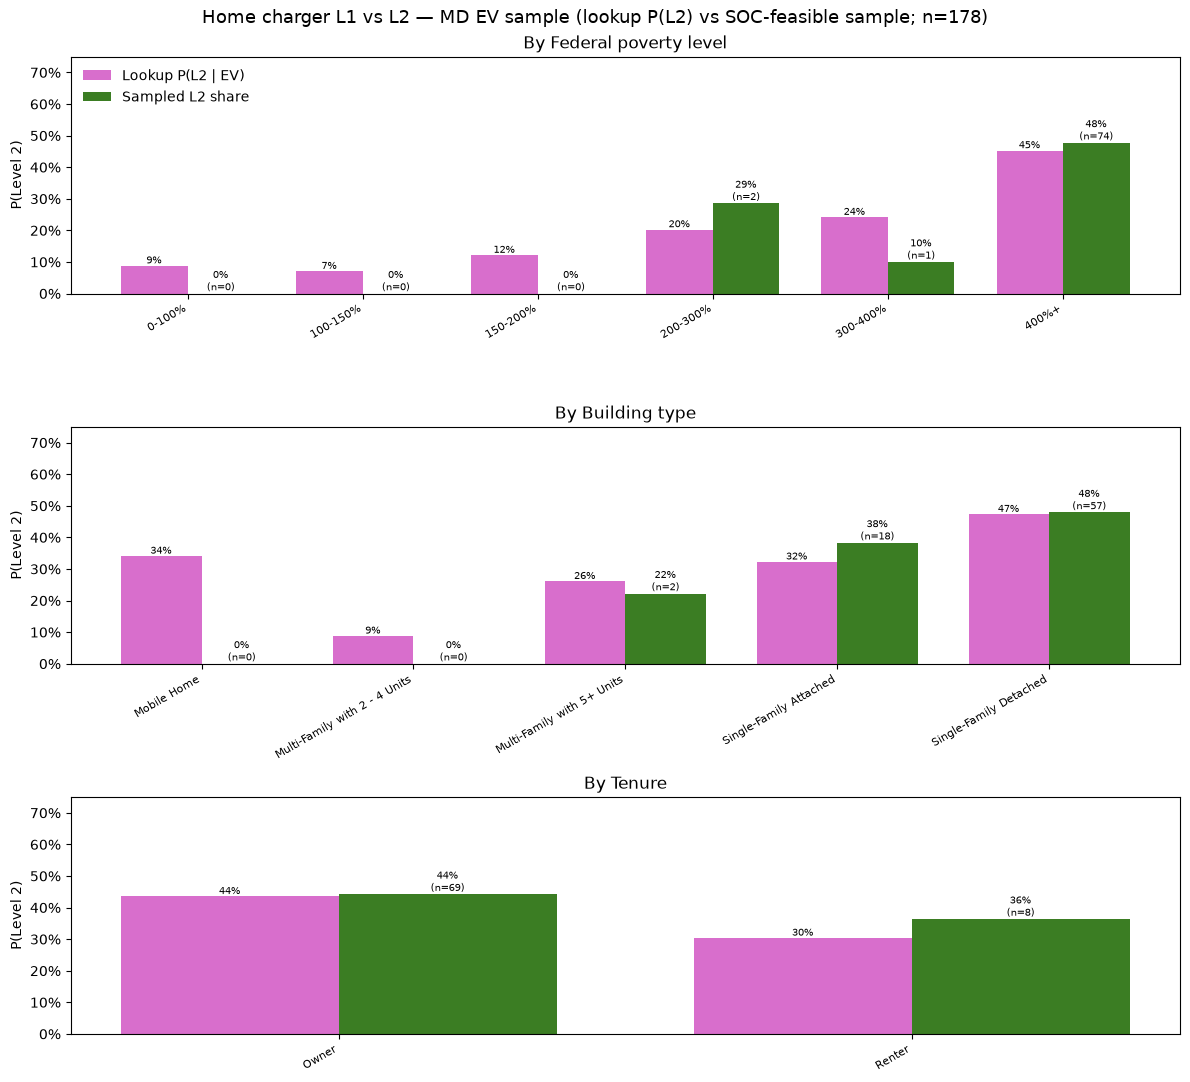

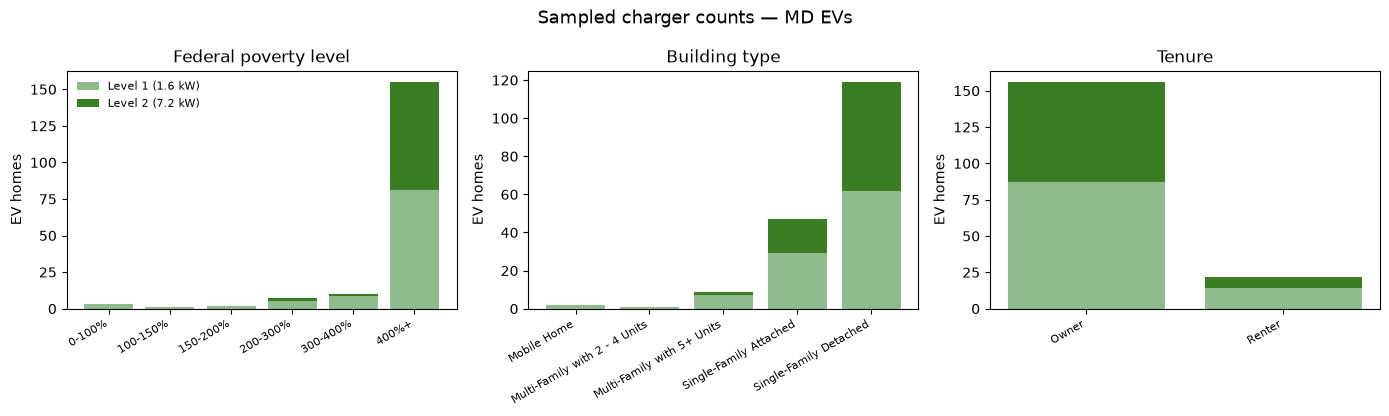

charger_level,n,kW,mean_lookup_p_l2_in_group
str,u32,f64,f64
"""Level 1""",101,1.6,0.393027
"""Level 2""",77,7.2,0.453284


In [36]:
# Lookup P(L2) vs sampled L2 share by FPL / building type / tenure (EV homes only)
ev_charger_compare = (
    vehicles_with_prob.select(
        "bldg_id", "vehicle_id", "fpl", "building_type", "tenure", "weight", "p_level2"
    )
    .join(
        ev_attributes.select("bldg_id", "vehicle_id", "charger_level", "charger_power_kw"),
        on=["bldg_id", "vehicle_id"],
        how="left",
    )
    .with_columns((pl.col("charger_level") == "Level 2").alias("is_l2"))
)

fig, axes = plt.subplots(3, 1, figsize=(12, 11))
fig.suptitle(
    f"Home charger L1 vs L2 — {STATE} EV sample "
    f"(lookup P(L2) vs SOC-feasible sample; n={ev_charger_compare.height})",
    fontsize=13,
)
width = 0.38

for ax, category in zip(axes, PLOT_CATEGORIES):
    eligible = ev_charger_compare.filter(
        (pl.col("fpl") != "Not Available")
        & (pl.col("tenure") != "Not Available")
        & (pl.col(category) != "Not Available")
    )
    summary = (
        eligible.group_by(category)
        .agg(
            pl.col("p_level2").mean().alias("lookup_p_l2"),
            pl.col("is_l2").mean().alias("sampled_l2_share"),
            pl.len().alias("n"),
            (pl.col("charger_level") == "Level 1").sum().alias("n_l1"),
            (pl.col("charger_level") == "Level 2").sum().alias("n_l2"),
        )
    )
    summary = _sort_summary(summary, category)
    labels = summary[category].to_list()
    x = np.arange(len(labels))
    lookup_vals = summary["lookup_p_l2"].to_numpy()
    sampled_vals = summary["sampled_l2_share"].to_numpy()

    bars1 = ax.bar(x - width / 2, lookup_vals, width, label="Lookup P(L2 | EV)", color=COLOR_PINK)
    bars2 = ax.bar(x + width / 2, sampled_vals, width, label="Sampled L2 share", color=COLOR_GREEN)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("P(Level 2)")
    ax.set_ylim(0, max(0.75, float(np.nanmax(np.concatenate([lookup_vals, sampled_vals]))) * 1.25))
    ax.set_title(f"By {PLOT_CATEGORY_LABELS[category]}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    for bar, val, n in zip(bars1, lookup_vals, summary["n"].to_list(), strict=False):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.0%}",
            ha="center",
            va="bottom",
            fontsize=7,
        )
    for bar, val, n_l2 in zip(bars2, sampled_vals, summary["n_l2"].to_list(), strict=False):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:.0%}\n(n={n_l2})",
            ha="center",
            va="bottom",
            fontsize=7,
        )
    if ax is axes[0]:
        ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
plt.show()

# Stacked L1/L2 counts by category (realized sample)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
fig.suptitle(f"Sampled charger counts — {STATE} EVs", fontsize=13)
for ax, category in zip(axes, PLOT_CATEGORIES):
    eligible = ev_charger_compare.filter(
        (pl.col("fpl") != "Not Available")
        & (pl.col("tenure") != "Not Available")
        & (pl.col(category) != "Not Available")
    )
    summary = _sort_summary(
        eligible.group_by(category).agg(
            (pl.col("charger_level") == "Level 1").sum().alias("n_l1"),
            (pl.col("charger_level") == "Level 2").sum().alias("n_l2"),
        ),
        category,
    )
    labels = summary[category].to_list()
    x = np.arange(len(labels))
    n1 = summary["n_l1"].to_numpy()
    n2 = summary["n_l2"].to_numpy()
    ax.bar(x, n1, label=f"Level 1 ({config.level1_charger_power_kw} kW)", color="#8FBC8F")
    ax.bar(x, n2, bottom=n1, label=f"Level 2 ({config.level2_charger_power_kw} kW)", color=COLOR_GREEN)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("EV homes")
    ax.set_title(PLOT_CATEGORY_LABELS[category])
    if ax is axes[0]:
        ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

display(
    ev_charger_compare.group_by("charger_level")
    .agg(
        pl.len().alias("n"),
        pl.col("charger_power_kw").first().alias("kW"),
        pl.col("p_level2").mean().alias("mean_lookup_p_l2_in_group"),
    )
    .sort("charger_level")
)


## 9. Charging policies — one MD building

Same trips, battery, **§7 home-charging fraction**, and **§8 charger power** for building
**3870**, mid-year week. Four strategies:

| Strategy | Behavior |
|---|---|
| `immediate` | Charge at the assigned home charger (L1/L2) whenever home and not full |
| `off_peak` | Charge only off-peak until daily SOC target |
| `off_peak_immediate` | Charge at the assigned charger whenever home and off-peak (config default) |
| `cost_minimizing` | Perfect-foresight LP on a simple TOU price (peak \$0.20, off-peak \$0.10) |

Peak hours follow the config (`peak_clock_hours`, default 17–20). Discharge is identical
across strategies (same trips) and uses the §6 hourly duty miles × Autonomie `kWh/mi` ×
`fraction_charged_home` (temperature-scaled when `temperature_adjustment=resstock`).

`cost_minimizing` also reports **shed load** — trip energy the LP chose not to serve, which
keeps the program feasible when no charging schedule can cover the draw. With feasibility-sized packs this should be 0 (L1 may need more hours to recover).


In [37]:
from datetime import datetime, timedelta

# Prefer a building with real trips (empty weekday+weekend templates have no trip rows).
DEMO_BLDG = 3870
if trip_schedules.filter(pl.col("bldg_id") == DEMO_BLDG).is_empty():
    DEMO_BLDG = int(
        trip_schedules.group_by("bldg_id")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)["bldg_id"][0]
    )
    print(f"Demo building 3870 has no trips (empty templates); using bldg_id={DEMO_BLDG}")

# Mid-year Mon–Sun travel week (July 1 2024 is a Monday)
WINDOW_START = datetime(2024, 7, 1, 4, 0, 0)
WINDOW_END = datetime(2024, 7, 8, 3, 0, 0)  # inclusive last hour slot

demo_trips = trip_schedules.filter(pl.col("bldg_id") == DEMO_BLDG)
demo_attrs = ev_attributes.filter(pl.col("bldg_id") == DEMO_BLDG)
# Reuse §6 duty miles; generate_soc multiplies by kwh_per_mile × fraction_charged_home.
demo_hourly_duty = hourly_temp_scaled_miles.filter(pl.col("bldg_id") == DEMO_BLDG)
assert demo_attrs.height >= 1, f"No battery attrs for bldg_id={DEMO_BLDG}"
assert demo_trips.height >= 1, f"No trips for bldg_id={DEMO_BLDG}"
assert "fraction_charged_home" in demo_attrs.columns

print(f"Building {DEMO_BLDG}: {demo_trips.height:,} trip rows, vehicle slot(s) {demo_attrs['vehicle_id'].to_list()}")
display(demo_attrs.select(
    "bldg_id", "vehicle_id", "ev_option_name", "battery_capacity_kwh", "kwh_per_mile",
    "max_daily_miles", "charge_at_home_bin", "fraction_charged_home",
    "charger_level", "charger_power_kw",
))

charging_sim = ChargingSimulator(start_date=config.start_date, end_date=config.end_date)
# Prefer hours_base from §6 so duty miles and SOC share the same calendar.
if "hours_base" not in globals():
    hours_base = build_hours_base(config.start_date, config.end_date)
peak_hours = tuple(config.peak_clock_hours) if config.peak_clock_hours else (17, 18, 19, 20)

# Simple TOU for cost-minimizing (matches peak_clock_hours)
hourly_tou_prices = (
    hours_base.with_columns(
        pl.when(pl.col("timestamp").dt.hour().is_in(list(peak_hours)))
        .then(0.20)
        .otherwise(0.10)
        .alias("price")
    )["price"]
    .to_numpy()
)

presence_by_vehicle = charging_sim.generate_presence(
    demo_trips, hours_base=hours_base
)

soc_common = dict(
    trip_schedules=demo_trips,
    ev_attributes=demo_attrs,
    hours_base=hours_base,
    presence_by_vehicle=presence_by_vehicle,
    # Per-vehicle L1/L2 kW + fraction_charged_home already on ev_attributes from §7–§8.
    initial_soc_kwh=config.initial_soc_kwh,
    hourly_temp_scaled_miles=demo_hourly_duty,
)

strategy_kwargs = {
    "immediate": {},
    "off_peak": {
        "peak_clock_hours": peak_hours,
        "soc_min_fraction": config.soc_min_fraction if config.soc_min_fraction is not None else DEFAULT_SOC_MIN_FRACTION,
        "soc_safety_buffer_fraction": (
            config.soc_safety_buffer_fraction
            if config.soc_safety_buffer_fraction is not None
            else DEFAULT_SOC_SAFETY_BUFFER_FRACTION
        ),
    },
    "off_peak_immediate": {
        "peak_clock_hours": peak_hours,
        "allow_emergency_peak_charging": bool(config.allow_emergency_peak_charging),
    },
    "cost_minimizing": {
        "hourly_price_usd_per_kwh": hourly_tou_prices,
        "shed_load_penalty_usd_per_kwh": (
            config.shed_load_penalty_usd_per_kwh
            if config.shed_load_penalty_usd_per_kwh is not None
            else 1_000_000.0
        ),
    },
}

soc_by_strategy: dict[str, pl.DataFrame] = {}
for strategy, extra in strategy_kwargs.items():
    soc = charging_sim.generate_soc(charging_strategy=strategy, **soc_common, **extra)
    soc_by_strategy[strategy] = soc
    # cost_minimizing also returns shed_load_kwh — trip energy the LP declined to serve.
    # Expect 0: shedding only happens when charging cannot cover the draw at any price.
    shed = f"  shed={soc['shed_load_kwh'].sum():.2f} kWh" if "shed_load_kwh" in soc.columns else ""
    print(
        f"{strategy:20s}  annual charge={soc['charge_kwh'].sum():7.1f} kWh  "
        f"discharge={soc['discharge_kwh'].sum():7.1f} kWh  "
        f"underflow_hours={int(soc['soc_underflow'].sum())}{shed}"
    )


Building 3870: 732 trip rows, vehicle slot(s) [1]


bldg_id,vehicle_id,ev_option_name,battery_capacity_kwh,kwh_per_mile,max_daily_miles,charge_at_home_bin,fraction_charged_home,charger_level,charger_power_kw
i64,i64,str,f64,f64,f64,str,f64,str,f64
3870,1,"""SUV, Battery Electric Vehicle,…",83.68,0.278934,123.263148,"""100%""",1.0,"""Level 1""",1.6


immediate             annual charge= 2436.8 kWh  discharge= 2436.8 kWh  underflow_hours=0
off_peak              annual charge= 2362.2 kWh  discharge= 2436.8 kWh  underflow_hours=1
off_peak_immediate    annual charge= 2436.8 kWh  discharge= 2436.8 kWh  underflow_hours=0
cost_minimizing       annual charge= 2353.1 kWh  discharge= 2436.8 kWh  underflow_hours=0


In [38]:
def _window_slice(soc: pl.DataFrame) -> pl.DataFrame:
    return (
        soc.filter(
            (pl.col("timestamp") >= WINDOW_START) & (pl.col("timestamp") <= WINDOW_END)
        )
        .sort("timestamp")
        .with_columns(
            pl.col("timestamp").dt.hour().alias("clock_hour"),
            pl.col("timestamp").dt.hour().is_in(list(peak_hours)).alias("is_peak"),
        )
    )


window_by_strategy = {s: _window_slice(soc) for s, soc in soc_by_strategy.items()}

# Week summary: charge / discharge and how much charging landed on peak hours
summary_rows = []
for strategy, win in window_by_strategy.items():
    charge = float(win["charge_kwh"].sum())
    discharge = float(win["discharge_kwh"].sum())
    peak_charge = float(win.filter(pl.col("is_peak"))["charge_kwh"].sum())
    summary_rows.append({
        "strategy": strategy,
        "window_charge_kwh": round(charge, 2),
        "window_discharge_kwh": round(discharge, 2),
        "peak_charge_kwh": round(peak_charge, 2),
        "peak_charge_share": round(peak_charge / charge, 3) if charge > 0 else 0.0,
        "underflow_hours": int(win.filter(pl.col("soc_underflow")).height),
    })

_demo_charger = demo_attrs.select("charger_level", "charger_power_kw").row(0)
print(
    f"Building {DEMO_BLDG} — {WINDOW_START.date()} → {WINDOW_END.date()} "
    f"(peak hours {list(peak_hours)}; charger={_demo_charger[0]} @ {_demo_charger[1]} kW)"
)
display(pl.DataFrame(summary_rows))


Building 3870 — 2024-07-01 → 2024-07-08 (peak hours [17, 18, 19, 20]; charger=Level 1 @ 1.6 kW)


strategy,window_charge_kwh,window_discharge_kwh,peak_charge_kwh,peak_charge_share,underflow_hours
str,f64,f64,f64,f64,i64
"""immediate""",43.48,43.25,12.8,0.294,0
"""off_peak""",43.23,43.25,0.0,0.0,0
"""off_peak_immediate""",45.66,43.25,0.0,0.0,0
"""cost_minimizing""",43.92,43.25,0.0,0.0,0


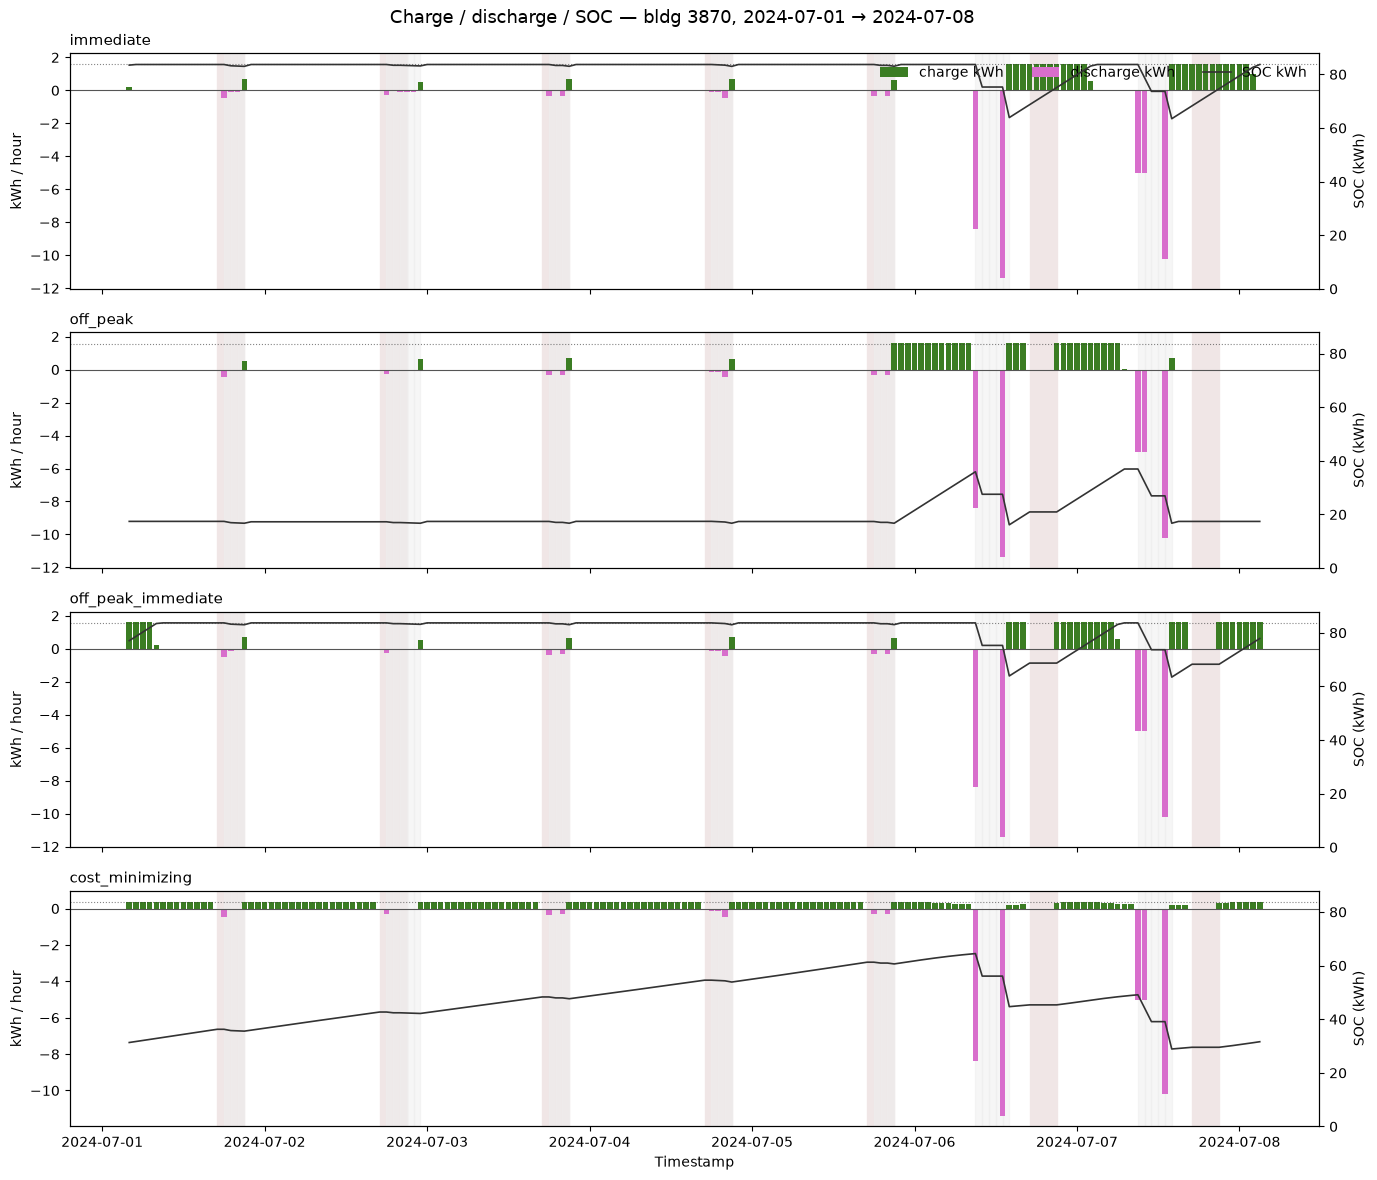

In [39]:
strategies = ["immediate", "off_peak", "off_peak_immediate", "cost_minimizing"]
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle(
    f"Charge / discharge / SOC — bldg {DEMO_BLDG}, {WINDOW_START.date()} → {(WINDOW_END - timedelta(hours=3)).date()}",
    fontsize=13,
)

battery_kwh = float(demo_attrs["battery_capacity_kwh"][0])

for ax, strategy in zip(axes, strategies):
    win = window_by_strategy[strategy]
    ts = win["timestamp"].to_numpy()
    charge = win["charge_kwh"].to_numpy()
    discharge = win["discharge_kwh"].to_numpy()
    soc = win["soc_kwh"].to_numpy()
    at_home = win["at_home"].to_numpy()
    is_peak = win["is_peak"].to_numpy()

    # Shade peak hours and away hours
    for i in range(len(ts)):
        if is_peak[i]:
            ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)
        if not at_home[i]:
            ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#eeeeee", alpha=0.5, zorder=0)

    ax.bar(ts, charge, width=np.timedelta64(50, "m"), color=COLOR_GREEN, label="charge kWh", zorder=2)
    ax.bar(ts, -discharge, width=np.timedelta64(50, "m"), color=COLOR_PINK, label="discharge kWh", zorder=2)
    ax.set_ylabel("kWh / hour")
    ax.axhline(0, color="#555555", linewidth=0.8)

    ax2 = ax.twinx()
    ax2.plot(ts, soc, color="#333333", linewidth=1.2, label="SOC kWh", zorder=3)
    ax2.set_ylabel("SOC (kWh)")
    ax2.set_ylim(0, battery_kwh * 1.05)
    ax2.axhline(battery_kwh, color="#333333", linestyle=":", linewidth=0.8, alpha=0.6)

    ax.set_title(strategy, loc="left", fontsize=11)
    if strategy == strategies[0]:
        # Combined legend once
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper right", frameon=False, ncols=3)

axes[-1].set_xlabel("Timestamp")
fig.tight_layout()
plt.show()


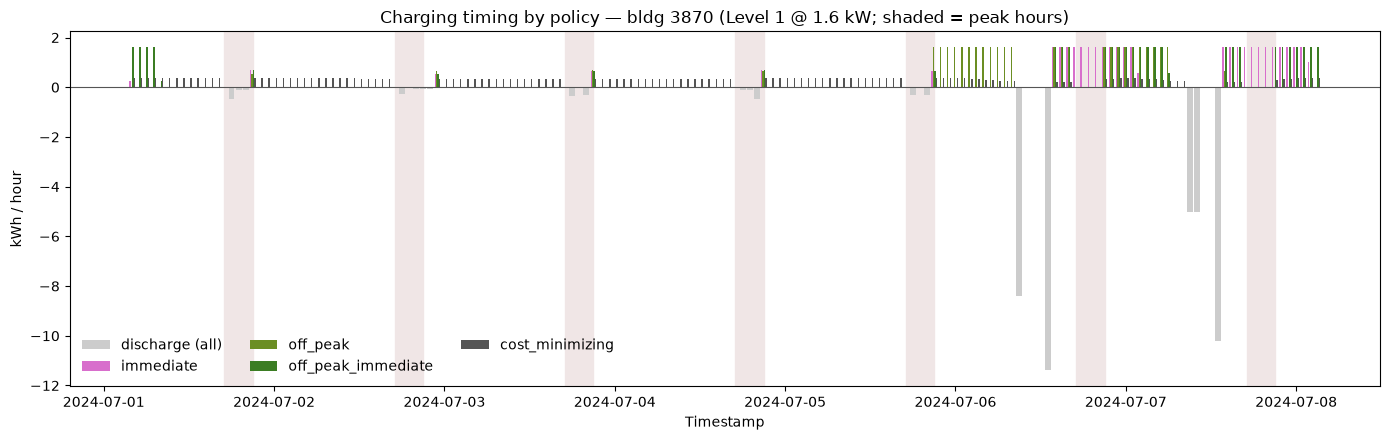

In [40]:
# Side-by-side charge profiles only (same discharge underneath)
fig, ax = plt.subplots(figsize=(14, 4.5))
width = np.timedelta64(12, "m")
offsets = {
    "immediate": -1.5 * width,
    "off_peak": -0.5 * width,
    "off_peak_immediate": 0.5 * width,
    "cost_minimizing": 1.5 * width,
}
colors = {
    "immediate": COLOR_PINK,
    "off_peak": "#6B8E23",
    "off_peak_immediate": COLOR_GREEN,
    "cost_minimizing": "#555555",
}

# Use immediate window timestamps as the x spine; discharge once as reference
ref = window_by_strategy["immediate"]
ts = ref["timestamp"].to_numpy()
ax.bar(ts, -ref["discharge_kwh"].to_numpy(), width=np.timedelta64(50, "m"),
       color="#cccccc", label="discharge (all)", zorder=1)

for strategy in strategies:
    win = window_by_strategy[strategy]
    ax.bar(
        win["timestamp"].to_numpy() + offsets[strategy],
        win["charge_kwh"].to_numpy(),
        width=width,
        color=colors[strategy],
        label=strategy,
        zorder=2,
    )

for i, t in enumerate(ts):
    if bool(ref["is_peak"][i]):
        ax.axvspan(t, t + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

ax.axhline(0, color="#555555", linewidth=0.8)
ax.set_ylabel("kWh / hour")
ax.set_xlabel("Timestamp")
_ch = demo_attrs.select("charger_level", "charger_power_kw").row(0)
ax.set_title(
    f"Charging timing by policy — bldg {DEMO_BLDG} "
    f"({_ch[0]} @ {_ch[1]} kW; shaded = peak hours)"
)
ax.legend(frameon=False, ncols=3)
fig.tight_layout()
plt.show()


## 10. Fleet aggregate hourly charging load

Same four strategies on **all** MD EV slots, then sum `charge_kwh` across vehicles.

- **Load curves:** first week of July 2024 (Mon 7/1 04:00 → Mon 7/8 03:00)
- **Peak demand stats:** max hourly fleet charge over the **full simulation year**

SOC is simulated for the full year so both the July week and annual peaks use a consistent
battery state. Discharge reuses the §6 hourly temp-scaled duty miles × `kWh/mi` ×
`fraction_charged_home` (same as `ev_demand.py`), so outdoor temperature and home-charging
share affect residential draw consistently while packs remain sized on full duty.


In [41]:
# Fleet SOC under each strategy (reuses trip_schedules + ev_attributes + duty miles from §5–§8)
FLEET_WINDOW_START = datetime(2024, 7, 1, 4, 0, 0)
FLEET_WINDOW_END = datetime(2024, 7, 8, 3, 0, 0)

fleet_charging_sim = ChargingSimulator(start_date=config.start_date, end_date=config.end_date)
# Same calendar as §6 duty-miles build.
fleet_hours_base = hours_base if "hours_base" in globals() else build_hours_base(
    config.start_date, config.end_date
)
fleet_peak_hours = tuple(config.peak_clock_hours) if config.peak_clock_hours else (17, 18, 19, 20)

fleet_tou_prices = (
    fleet_hours_base.with_columns(
        pl.when(pl.col("timestamp").dt.hour().is_in(list(fleet_peak_hours)))
        .then(0.20)
        .otherwise(0.10)
        .alias("price")
    )["price"]
    .to_numpy()
)

# Vehicles matched to empty NHTS templates have no trip rows, so presence must be keyed
# off ev_attributes (every assigned EV slot) rather than inferred from trip_schedules.
# Those vehicles come back always-at-home with zero discharge.
fleet_vehicle_keys = list(ev_attributes.select("bldg_id", "vehicle_id").unique().iter_rows())
n_driven_veh = trip_schedules.select("bldg_id", "vehicle_id").unique().height
print(
    f"Building presence for {len(fleet_vehicle_keys):,} EV slot(s) "
    f"({trip_schedules.height:,} trip rows across {n_driven_veh:,} vehicles; "
    f"{len(fleet_vehicle_keys) - n_driven_veh:,} never-driven)..."
)
fleet_presence = fleet_charging_sim.generate_presence(
    trip_schedules, hours_base=fleet_hours_base, vehicle_keys=fleet_vehicle_keys
)

fleet_soc_common = dict(
    trip_schedules=trip_schedules,
    ev_attributes=ev_attributes,
    hours_base=fleet_hours_base,
    presence_by_vehicle=fleet_presence,
    # Per-vehicle L1/L2 kW + fraction_charged_home already on ev_attributes from §7–§8.
    initial_soc_kwh=config.initial_soc_kwh,
    # Reuse §6 duty miles — discharge = temp_scaled_miles × kwh_per_mile × fraction_charged_home.
    hourly_temp_scaled_miles=hourly_temp_scaled_miles,
)

fleet_strategy_kwargs = {
    "immediate": {},
    "off_peak": {
        "peak_clock_hours": fleet_peak_hours,
        "soc_min_fraction": (
            config.soc_min_fraction if config.soc_min_fraction is not None else DEFAULT_SOC_MIN_FRACTION
        ),
        "soc_safety_buffer_fraction": (
            config.soc_safety_buffer_fraction
            if config.soc_safety_buffer_fraction is not None
            else DEFAULT_SOC_SAFETY_BUFFER_FRACTION
        ),
    },
    "off_peak_immediate": {
        "peak_clock_hours": fleet_peak_hours,
        "allow_emergency_peak_charging": bool(config.allow_emergency_peak_charging),
    },
    "cost_minimizing": {
        "hourly_price_usd_per_kwh": fleet_tou_prices,
        "shed_load_penalty_usd_per_kwh": (
            config.shed_load_penalty_usd_per_kwh
            if config.shed_load_penalty_usd_per_kwh is not None
            else 1_000_000.0
        ),
    },
}

fleet_soc_by_strategy: dict[str, pl.DataFrame] = {}
for strategy, extra in fleet_strategy_kwargs.items():
    print(f"Generating SOC — {strategy}...")
    fleet_soc_by_strategy[strategy] = fleet_charging_sim.generate_soc(
        charging_strategy=strategy, **fleet_soc_common, **extra
    )
    soc = fleet_soc_by_strategy[strategy]
    # cost_minimizing also returns shed_load_kwh — trip energy the LP declined to serve.
    # Expect 0: shedding only happens when charging cannot cover the draw at any price.
    shed = f"  shed={soc['shed_load_kwh'].sum():,.2f} kWh" if "shed_load_kwh" in soc.columns else ""
    print(
        f"  rows={soc.height:,}  annual fleet charge={soc['charge_kwh'].sum():,.0f} kWh  "
        f"discharge={soc['discharge_kwh'].sum():,.0f} kWh  "
        f"underflow_hours={int(soc['soc_underflow'].sum())}{shed}"
    )


Building presence for 178 EV slot(s) (191,013 trip rows across 178 vehicles; 0 never-driven)...
Generating SOC — immediate...
  rows=1,563,552  annual fleet charge=343,613 kWh  discharge=343,692 kWh  underflow_hours=0
Generating SOC — off_peak...


  rows=1,563,552  annual fleet charge=333,194 kWh  discharge=343,692 kWh  underflow_hours=628
Generating SOC — off_peak_immediate...
  rows=1,563,552  annual fleet charge=343,532 kWh  discharge=343,692 kWh  underflow_hours=1
Generating SOC — cost_minimizing...
  rows=1,563,552  annual fleet charge=332,111 kWh  discharge=343,692 kWh  underflow_hours=0


In [42]:
# Aggregate hourly fleet load: July window (time-series plots) + full year (peak stats)
def fleet_hourly_load(soc: pl.DataFrame, *, start=None, end=None) -> pl.DataFrame:
    frame = soc
    if start is not None:
        frame = frame.filter(pl.col("timestamp") >= start)
    if end is not None:
        frame = frame.filter(pl.col("timestamp") <= end)
    return (
        frame.group_by("timestamp")
        .agg(
            pl.col("charge_kwh").sum().alias("fleet_charge_kwh"),
            pl.col("discharge_kwh").sum().alias("fleet_discharge_kwh"),
            pl.col("bldg_id").n_unique().alias("n_buildings"),
        )
        .sort("timestamp")
        .with_columns(
            pl.col("timestamp").dt.hour().alias("clock_hour"),
            pl.col("timestamp").dt.hour().is_in(list(fleet_peak_hours)).alias("is_peak"),
        )
    )


fleet_load_by_strategy = {
    strategy: fleet_hourly_load(soc, start=FLEET_WINDOW_START, end=FLEET_WINDOW_END)
    for strategy, soc in fleet_soc_by_strategy.items()
}
fleet_annual_load_by_strategy = {
    strategy: fleet_hourly_load(soc) for strategy, soc in fleet_soc_by_strategy.items()
}

# July-week energy totals + annual peak demand stats
fleet_summary_rows = []
for strategy in fleet_soc_by_strategy:
    week = fleet_load_by_strategy[strategy]
    annual = fleet_annual_load_by_strategy[strategy]
    week_charge = week["fleet_charge_kwh"]
    annual_charge = annual["fleet_charge_kwh"]
    annual_peak = annual.filter(pl.col("is_peak"))["fleet_charge_kwh"]
    annual_offpeak = annual.filter(~pl.col("is_peak"))["fleet_charge_kwh"]
    hour_of_max = annual.sort("fleet_charge_kwh", descending=True)["timestamp"][0]
    fleet_summary_rows.append({
        "strategy": strategy,
        "week_charge_kwh": round(float(week_charge.sum()), 1),
        "week_discharge_kwh": round(float(week["fleet_discharge_kwh"].sum()), 1),
        "annual_max_hourly_charge_kwh": round(float(annual_charge.max()), 2),
        "annual_mean_hourly_charge_kwh": round(float(annual_charge.mean()), 2),
        "annual_p95_hourly_charge_kwh": round(float(annual_charge.quantile(0.95)), 2),
        "annual_max_peak_hour_charge_kwh": round(
            float(annual_peak.max()) if annual_peak.len() else 0.0, 2
        ),
        "annual_max_offpeak_hour_charge_kwh": round(
            float(annual_offpeak.max()) if annual_offpeak.len() else 0.0, 2
        ),
        "annual_peak_window_charge_share": round(
            float(annual_peak.sum() / annual_charge.sum()) if float(annual_charge.sum()) > 0 else 0.0,
            3,
        ),
        "hour_of_annual_max_charge": hour_of_max,
    })

print(
    f"MD fleet ({ev_attributes.height} EVs) — July week load curves; "
    f"peak stats over full simulation year  "
    f"peak hours={list(fleet_peak_hours)}"
)
display(pl.DataFrame(fleet_summary_rows))


MD fleet (178 EVs) — July week load curves; peak stats over full simulation year  peak hours=[17, 18, 19, 20]


strategy,week_charge_kwh,week_discharge_kwh,annual_max_hourly_charge_kwh,annual_mean_hourly_charge_kwh,annual_p95_hourly_charge_kwh,annual_max_peak_hour_charge_kwh,annual_max_offpeak_hour_charge_kwh,annual_peak_window_charge_share,hour_of_annual_max_charge
str,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs]
"""immediate""",5871.7,5870.6,132.63,39.12,92.57,132.63,131.38,0.336,2024-01-17 20:00:00
"""off_peak""",5852.6,5870.6,290.54,37.93,142.13,0.0,290.54,0.0,2024-02-04 21:00:00
"""off_peak_immediate""",5871.7,5870.6,273.84,39.11,139.9,0.0,273.84,0.0,2024-01-17 21:00:00
"""cost_minimizing""",5890.4,5870.6,97.66,37.81,75.43,0.01,97.66,0.0,2024-01-18 03:00:00


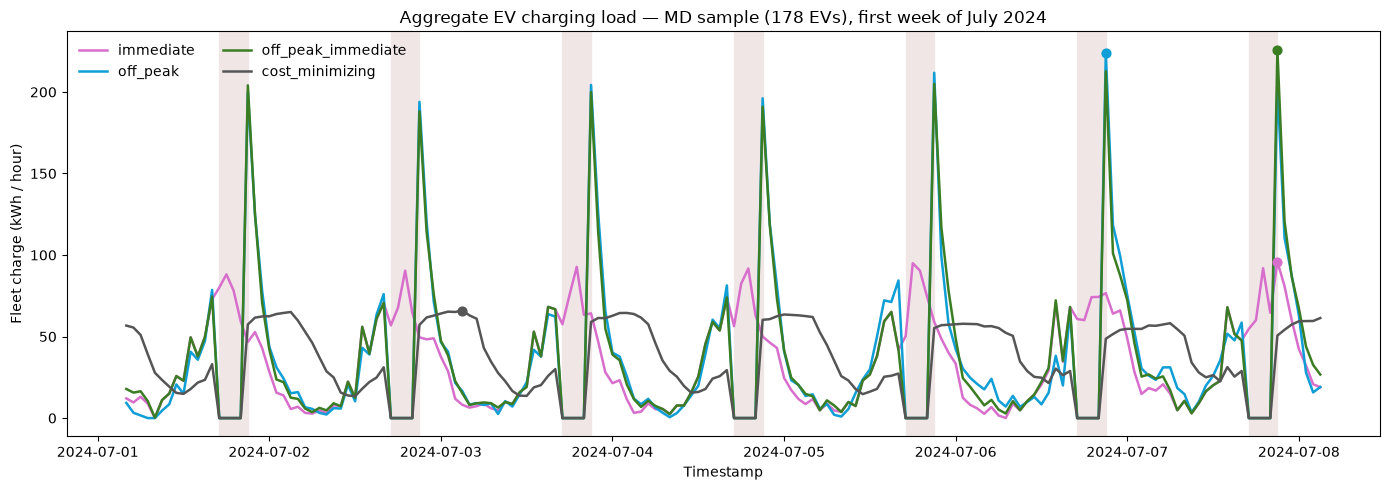

In [43]:
STRATEGY_COLORS = {
    "immediate": COLOR_PINK,
    "off_peak": "#0F9ED5",
    "off_peak_immediate": COLOR_GREEN,
    "cost_minimizing": "#555555",
}
strategies_order = ["immediate", "off_peak", "off_peak_immediate", "cost_minimizing"]

fig, ax = plt.subplots(figsize=(14, 5))
ref = fleet_load_by_strategy["immediate"]
ts = ref["timestamp"].to_numpy()

# Shade peak hours once
for i, is_peak in enumerate(ref["is_peak"].to_list()):
    if is_peak:
        ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

for strategy in strategies_order:
    load = fleet_load_by_strategy[strategy]
    ax.plot(
        load["timestamp"].to_numpy(),
        load["fleet_charge_kwh"].to_numpy(),
        color=STRATEGY_COLORS[strategy],
        linewidth=1.8,
        label=strategy,
    )
    # Mark the hour of maximum charge
    imax = int(np.argmax(load["fleet_charge_kwh"].to_numpy()))
    ax.scatter(
        [load["timestamp"].to_numpy()[imax]],
        [float(load["fleet_charge_kwh"][imax])],
        color=STRATEGY_COLORS[strategy],
        s=40,
        zorder=3,
    )

ax.set_ylabel("Fleet charge (kWh / hour)")
ax.set_xlabel("Timestamp")
ax.set_title(
    f"Aggregate EV charging load — {STATE} sample ({ev_attributes.height} EVs), "
    f"first week of July 2024"
)
ax.legend(frameon=False, ncols=2)
fig.tight_layout()
plt.show()


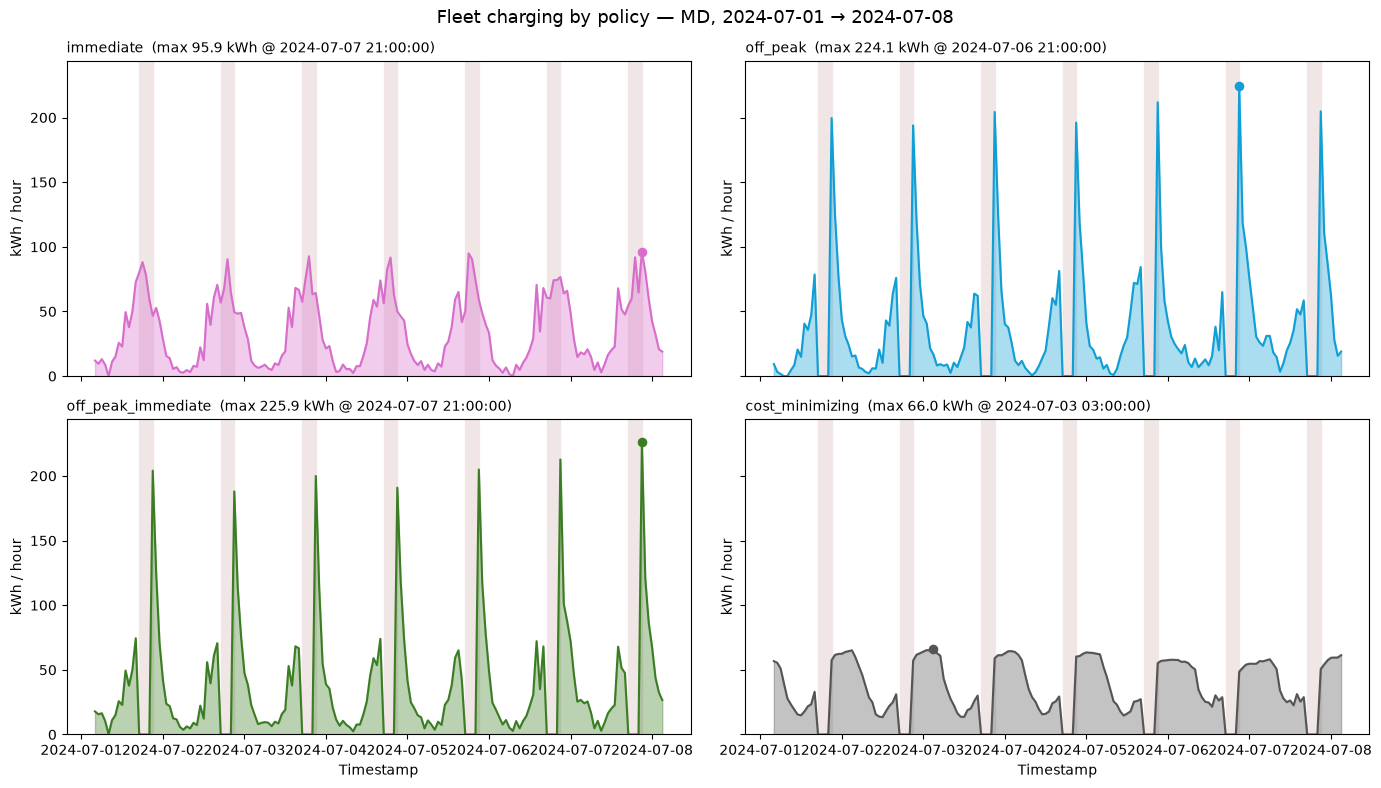

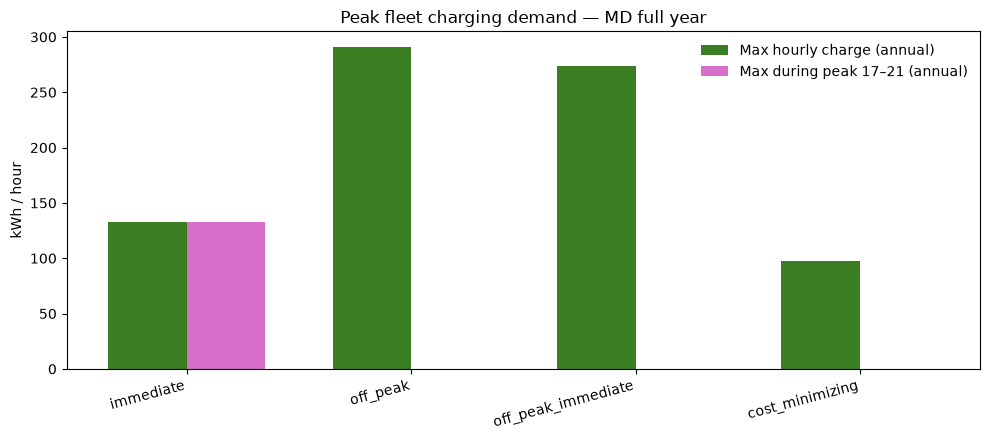

Hour of annual max fleet charge by strategy


strategy,annual_max_hourly_charge_kwh,hour_of_annual_max_charge
str,f64,datetime[μs]
"""immediate""",132.63,2024-01-17 20:00:00
"""off_peak""",290.54,2024-02-04 21:00:00
"""off_peak_immediate""",273.84,2024-01-17 21:00:00
"""cost_minimizing""",97.66,2024-01-18 03:00:00


In [44]:
# 2×2 panels + peak-hour bar comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle(
    f"Fleet charging by policy — {STATE}, {FLEET_WINDOW_START.date()} → "
    f"{(FLEET_WINDOW_END - timedelta(hours=3)).date()}",
    fontsize=13,
)

ymax = max(float(load["fleet_charge_kwh"].max()) for load in fleet_load_by_strategy.values()) * 1.08

for ax, strategy in zip(axes.ravel(), strategies_order):
    load = fleet_load_by_strategy[strategy]
    ts = load["timestamp"].to_numpy()
    vals = load["fleet_charge_kwh"].to_numpy()
    for i, is_peak in enumerate(load["is_peak"].to_list()):
        if is_peak:
            ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)
    ax.fill_between(ts, vals, color=STRATEGY_COLORS[strategy], alpha=0.35)
    ax.plot(ts, vals, color=STRATEGY_COLORS[strategy], linewidth=1.5)
    imax = int(np.argmax(vals))
    ax.scatter([ts[imax]], [vals[imax]], color=STRATEGY_COLORS[strategy], s=35, zorder=3)
    ax.set_ylim(0, ymax)
    ax.set_title(
        f"{strategy}  (max {vals[imax]:.1f} kWh @ {load['timestamp'][imax]})",
        loc="left",
        fontsize=10,
    )
    ax.set_ylabel("kWh / hour")

axes[1, 0].set_xlabel("Timestamp")
axes[1, 1].set_xlabel("Timestamp")
fig.tight_layout()
plt.show()

# Bar chart of annual peak metrics
summary = pl.DataFrame(fleet_summary_rows).sort(
    pl.col("strategy").replace({s: i for i, s in enumerate(strategies_order)})
)
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(summary.height)
width = 0.35
ax.bar(
    x - width / 2,
    summary["annual_max_hourly_charge_kwh"].to_numpy(),
    width,
    label="Max hourly charge (annual)",
    color=COLOR_GREEN,
)
ax.bar(
    x + width / 2,
    summary["annual_max_peak_hour_charge_kwh"].to_numpy(),
    width,
    label="Max during peak 17–21 (annual)",
    color=COLOR_PINK,
)
ax.set_xticks(x)
ax.set_xticklabels(summary["strategy"].to_list(), rotation=15, ha="right")
ax.set_ylabel("kWh / hour")
ax.set_title(f"Peak fleet charging demand — {STATE} full year")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Hour of annual max fleet charge by strategy")
display(summary.select("strategy", "annual_max_hourly_charge_kwh", "hour_of_annual_max_charge"))


### Off-peak underflow investigation

Under **`off_peak`** (charge only in the overnight/pre-departure off-peak window, and only up
to that day's `SOC_req` — never during peak 17–20) some vehicle-hours end with SOC below the
trip draw. §8 already requires L1/L2 to be feasible under **immediate** charging (with
`charger_buffer_fraction`), so remaining underflows here are mostly from the **stricter
off-peak window** — not from assigning an L1 that could never recover under any home schedule.

Underflow can run to thousands of hours, so we **aggregate first, then drill down**:

1. Fleet-level counts, plus exposure split by assigned charger level
2. Worst vehicles and worst vehicle-days (ranked by total shortfall)
3. Detailed travel / off-peak-window forensics for the top `UNDERFLOW_DETAIL_EVENTS` days only
4. SOC / charge / discharge plots for those same events

Raise `UNDERFLOW_DETAIL_EVENTS` in the next cell to inspect more events.



In [45]:
# Catalog off_peak underflow from the fleet SOC run in §10 — aggregate first, drill down later
UNDERFLOW_DETAIL_EVENTS = 3  # worst vehicle-days to print forensics + plot for
UNDERFLOW_PREVIEW_ROWS = 15  # rows to show in the ranked tables

off_peak_soc = fleet_soc_by_strategy["off_peak"]
underflow_hours = (
    off_peak_soc.filter(pl.col("soc_underflow"))
    .with_columns(
        (pl.col("discharge_kwh") - pl.col("soc_kwh")).alias("shortfall_kwh"),
        pl.col("timestamp").dt.date().alias("calendar_date"),
        pl.col("timestamp").dt.hour().alias("clock_hour"),
    )
    .join(
        ev_attributes.select(
            "bldg_id", "vehicle_id", "battery_capacity_kwh", "kwh_per_mile",
            "option_short", "max_daily_miles", "charger_level", "charger_power_kw",
        ),
        on=["bldg_id", "vehicle_id"],
        how="left",
    )
    .select(
        "bldg_id", "vehicle_id", "timestamp", "calendar_date", "clock_hour",
        "soc_kwh", "discharge_kwh", "shortfall_kwh", "charge_kwh", "at_home",
        "battery_capacity_kwh", "option_short", "max_daily_miles",
        "charger_level", "charger_power_kw",
    )
)

n_uf_vehicles = underflow_hours.select("bldg_id", "vehicle_id").unique().height
n_fleet_vehicles = ev_attributes.height
print(
    f"off_peak underflow: {underflow_hours.height:,} vehicle-hour(s) "
    f"across {n_uf_vehicles:,} of {n_fleet_vehicles:,} vehicles "
    f"({n_uf_vehicles / n_fleet_vehicles:.1%}); "
    f"total shortfall {underflow_hours['shortfall_kwh'].sum():,.1f} kWh"
)

# Collapse consecutive hours into vehicle-day events, ranked worst-first
underflow_events = (
    underflow_hours.group_by("bldg_id", "vehicle_id", "calendar_date")
    .agg(
        pl.col("timestamp").min().alias("first_underflow_ts"),
        pl.col("timestamp").max().alias("last_underflow_ts"),
        pl.len().alias("n_underflow_hours"),
        pl.col("shortfall_kwh").sum().alias("total_shortfall_kwh"),
        pl.col("discharge_kwh").sum().alias("discharge_during_underflow_kwh"),
        pl.col("soc_kwh").first().alias("soc_at_first_underflow_kwh"),
        pl.col("battery_capacity_kwh").first(),
        pl.col("option_short").first(),
        pl.col("max_daily_miles").first(),
        pl.col("charger_level").first(),
        pl.col("charger_power_kw").first(),
    )
    .sort(["total_shortfall_kwh", "first_underflow_ts"], descending=[True, False])
)
print(f"Underflow events (vehicle × calendar day): {underflow_events.height:,}")

# Exposure by assigned charger level — L1 homes should carry most of the shortfall
underflow_by_vehicle = (
    underflow_events.group_by(
        "bldg_id", "vehicle_id", "charger_level", "charger_power_kw",
        "option_short", "battery_capacity_kwh",
    )
    .agg(
        pl.len().alias("n_event_days"),
        pl.col("n_underflow_hours").sum().alias("n_underflow_hours"),
        pl.col("total_shortfall_kwh").sum().alias("total_shortfall_kwh"),
        pl.col("total_shortfall_kwh").max().alias("worst_day_shortfall_kwh"),
    )
    .sort("total_shortfall_kwh", descending=True)
)

print("\nUnderflow exposure by assigned charger level:")
display(
    ev_attributes.select("bldg_id", "vehicle_id", "charger_level", "charger_power_kw")
    .join(
        underflow_by_vehicle.select(
            "bldg_id", "vehicle_id", "n_underflow_hours", "total_shortfall_kwh"
        ),
        on=["bldg_id", "vehicle_id"],
        how="left",
    )
    .with_columns(
        pl.col("n_underflow_hours").fill_null(0),
        pl.col("total_shortfall_kwh").fill_null(0.0),
    )
    .group_by("charger_level", "charger_power_kw")
    .agg(
        pl.len().alias("n_vehicles"),
        (pl.col("n_underflow_hours") > 0).sum().alias("n_with_underflow"),
        pl.col("n_underflow_hours").sum().alias("underflow_hours"),
        pl.col("total_shortfall_kwh").sum().round(1).alias("shortfall_kwh"),
    )
    .with_columns(
        (pl.col("n_with_underflow") / pl.col("n_vehicles")).round(3).alias("share_affected")
    )
    .sort("charger_level")
)

print(f"Worst vehicles (top {UNDERFLOW_PREVIEW_ROWS} of {underflow_by_vehicle.height:,}):")
display(underflow_by_vehicle.head(UNDERFLOW_PREVIEW_ROWS))

print(f"Worst vehicle-days (top {UNDERFLOW_PREVIEW_ROWS} of {underflow_events.height:,}):")
display(
    underflow_events.select(
        "bldg_id", "vehicle_id", "calendar_date", "first_underflow_ts",
        "n_underflow_hours", "total_shortfall_kwh", "soc_at_first_underflow_kwh",
        "battery_capacity_kwh", "option_short", "charger_level",
    ).head(UNDERFLOW_PREVIEW_ROWS)
)

# Only these events get the expensive per-vehicle rebuild + plots below
detail_events = underflow_events.head(UNDERFLOW_DETAIL_EVENTS)
print(
    f"Drilling into {detail_events.height} worst event(s) "
    f"(set UNDERFLOW_DETAIL_EVENTS higher for more)"
)



off_peak underflow: 628 vehicle-hour(s) across 19 of 178 vehicles (10.7%); total shortfall 1,243.6 kWh
Underflow events (vehicle × calendar day): 255

Underflow exposure by assigned charger level:


charger_level,charger_power_kw,n_vehicles,n_with_underflow,underflow_hours,shortfall_kwh,share_affected
str,f64,u32,u32,u32,f64,f64
"""Level 1""",1.6,101,15,456,1007.7,0.149
"""Level 2""",7.2,77,4,172,235.9,0.052


Worst vehicles (top 15 of 19):


bldg_id,vehicle_id,charger_level,charger_power_kw,option_short,battery_capacity_kwh,n_event_days,n_underflow_hours,total_shortfall_kwh,worst_day_shortfall_kwh
i32,i32,str,f64,str,f64,u32,u32,f64,f64
194578,1,"""Level 1""",1.6,"""Pickup 300-mi""",105.946,32,70,235.021948,18.534773
37980,1,"""Level 2""",7.2,"""Compact 300-mi""",63.433,32,152,202.596681,21.167827
547599,1,"""Level 1""",1.6,"""SUV 300-mi""",83.68,23,44,194.891896,25.126613
463659,1,"""Level 1""",1.6,"""SUV 300-mi""",83.68,28,41,115.239481,11.046132
482003,1,"""Level 1""",1.6,"""SUV 200-mi""",53.503,33,119,112.321558,12.020484
…,…,…,…,…,…,…,…,…,…
49174,1,"""Level 1""",1.6,"""Compact 300-mi""",63.433,6,9,32.50508,15.75458
176449,1,"""Level 2""",7.2,"""Compact 300-mi""",63.433,5,10,25.227819,7.814532
273310,1,"""Level 1""",1.6,"""Compact 300-mi""",63.433,5,5,11.557937,5.13032


Worst vehicle-days (top 15 of 255):


bldg_id,vehicle_id,calendar_date,first_underflow_ts,n_underflow_hours,total_shortfall_kwh,soc_at_first_underflow_kwh,battery_capacity_kwh,option_short,charger_level
i32,i32,date,datetime[μs],u32,f64,f64,f64,str,str
547599,1,2024-02-04,2024-02-04 18:00:00,3,25.126613,8.730654,83.68,"""SUV 300-mi""","""Level 1"""
547599,1,2024-01-28,2024-01-28 17:00:00,4,22.797004,2.266461,83.68,"""SUV 300-mi""","""Level 1"""
37980,1,2024-11-17,2024-11-17 00:00:00,10,21.167827,0.0,63.433,"""Compact 300-mi""","""Level 2"""
547599,1,2024-02-18,2024-02-18 18:00:00,3,19.429826,7.045031,83.68,"""SUV 300-mi""","""Level 1"""
194578,1,2024-01-18,2024-01-18 12:00:00,6,18.534773,7.142986,105.946,"""Pickup 300-mi""","""Level 1"""
…,…,…,…,…,…,…,…,…,…
547599,1,2024-11-17,2024-11-17 18:00:00,5,16.432713,8.440835,83.68,"""SUV 300-mi""","""Level 1"""
49174,1,2024-02-04,2024-02-04 18:00:00,3,15.75458,2.843564,63.433,"""Compact 300-mi""","""Level 1"""
194578,1,2024-12-26,2024-12-26 15:00:00,4,15.416801,1.691873,105.946,"""Pickup 300-mi""","""Level 1"""


Drilling into 3 worst event(s) (set UNDERFLOW_DETAIL_EVENTS higher for more)


In [46]:
# Forensics for the worst events only: trip schedule + overnight off-peak charging opportunity
from utils.EVs.charging import (
    DEFAULT_SOC_MIN_FRACTION,
    DEFAULT_SOC_SAFETY_BUFFER_FRACTION,
    build_is_off_peak,
    build_off_peak_charging_params,
    tours_from_trip_schedules,
)

peak_hrs = list(fleet_peak_hours)
is_off_peak_year = build_is_off_peak(fleet_hours_base, peak_clock_hours=tuple(peak_hrs))
soc_min_frac = (
    config.soc_min_fraction if config.soc_min_fraction is not None else DEFAULT_SOC_MIN_FRACTION
)
soc_buf_frac = (
    config.soc_safety_buffer_fraction
    if config.soc_safety_buffer_fraction is not None
    else DEFAULT_SOC_SAFETY_BUFFER_FRACTION
)

# Restrict trips / tours to the detail vehicles so this stays cheap regardless of fleet-wide count
detail_keys = detail_events.select("bldg_id", "vehicle_id").unique()
veh_trips = trip_schedules.join(detail_keys, on=["bldg_id", "vehicle_id"], how="inner")
tours_uf = tours_from_trip_schedules(veh_trips)


def _as_date(col: str) -> pl.Expr:
    """Normalize trip/tour date columns (Datetime or Date) to Date for filtering."""
    return pl.col(col).cast(pl.Date)


_veh_year_cache: dict[tuple[int, int], pl.DataFrame] = {}


def _annotated_vehicle_year(bldg_id: int, vehicle_id: int, capacity: float) -> pl.DataFrame:
    """Rebuild the policy's charge_allowed / SOC_req for one vehicle (same as generate_soc)."""
    key = (bldg_id, vehicle_id)
    if key in _veh_year_cache:
        return _veh_year_cache[key]
    veh_mask = (pl.col("bldg_id") == bldg_id) & (pl.col("vehicle_id") == vehicle_id)
    veh_year = off_peak_soc.filter(veh_mask).sort("timestamp")
    charge_allowed, soc_target_kwh = build_off_peak_charging_params(
        veh_year["at_home"].to_numpy(),
        veh_year["discharge_kwh"].to_numpy(),
        fleet_hours_base,
        veh_trips.filter(veh_mask),
        battery_capacity_kwh=capacity,
        is_off_peak=is_off_peak_year,
        soc_min_fraction=soc_min_frac,
        soc_safety_buffer_fraction=soc_buf_frac,
    )
    veh_year = veh_year.with_columns(
        pl.Series("charge_allowed", charge_allowed),
        pl.Series("soc_target_kwh", soc_target_kwh),
        pl.Series("is_off_peak", is_off_peak_year),
    )
    _veh_year_cache[key] = veh_year
    return veh_year


event_diagnostics = []
underflow_plot_frames: dict[tuple[int, int, object], pl.DataFrame] = {}
for event in detail_events.iter_rows(named=True):
    bldg_id = event["bldg_id"]
    vehicle_id = event["vehicle_id"]
    cal_day = event["calendar_date"]
    prev_day = cal_day - timedelta(days=1)
    first_ts = event["first_underflow_ts"]
    capacity = float(event["battery_capacity_kwh"])
    day_set = [prev_day, cal_day]
    veh_mask = (pl.col("bldg_id") == bldg_id) & (pl.col("vehicle_id") == vehicle_id)

    # Trip legs whose departure or arrival falls on the underflow day or prior day
    day_trips = (
        veh_trips.filter(
            veh_mask
            & (
                _as_date("trip_departure_date").is_in(day_set)
                | _as_date("trip_arrival_date").is_in(day_set)
            )
        )
        .select(
            "travel_date",
            "trip_departure_date", "trip_departure_hour",
            "trip_arrival_date", "trip_arrival_hour",
            "trip_miles_driven",
            "tour_departure_date", "tour_departure_hour",
            "tour_arrival_date", "tour_arrival_hour",
        )
        .sort(["trip_departure_date", "trip_departure_hour"])
    )

    day_tours = (
        tours_uf.filter(
            veh_mask
            & (
                _as_date("tour_departure_date").is_in(day_set)
                | _as_date("tour_arrival_date").is_in(day_set)
            )
        )
        .select(
            "tour_departure_date", "tour_departure_hour",
            "tour_arrival_date", "tour_arrival_hour",
        )
        .sort(["tour_departure_date", "tour_departure_hour"])
    )

    veh_year = _annotated_vehicle_year(bldg_id, vehicle_id, capacity)

    # Window: ~30h before first underflow through last underflow hour
    window_end = event["last_underflow_ts"]
    window_start = first_ts - timedelta(hours=30)
    veh_soc = veh_year.filter(
        (pl.col("timestamp") >= window_start) & (pl.col("timestamp") <= window_end)
    )
    underflow_plot_frames[(bldg_id, vehicle_id, cal_day)] = veh_soc

    pre_uf = veh_soc.filter(pl.col("timestamp") < first_ts)
    window_off_hours = int(pre_uf.filter(pl.col("charge_allowed")).height)
    charged_hours = int(pre_uf.filter(pl.col("charge_kwh") > 1e-9).height)
    veh_charger_kw = float(event["charger_power_kw"])
    window_off_kwh_cap = window_off_hours * veh_charger_kw
    charged_kwh = float(pre_uf["charge_kwh"].sum())
    discharged_kwh = float(
        veh_soc.filter(pl.col("timestamp") <= first_ts)["discharge_kwh"].sum()
    )
    soc_at_uf = float(event["soc_at_first_underflow_kwh"])
    # SOC_req on the last allowed hour before underflow (what the policy was aiming for)
    last_allowed = pre_uf.filter(pl.col("charge_allowed"))
    soc_req_before = (
        float(last_allowed["soc_target_kwh"][-1]) if last_allowed.height else float("nan")
    )

    print("=" * 88)
    print(
        f"bldg={bldg_id}  veh={vehicle_id}  pack={event['option_short']}  "
        f"capacity={capacity:.1f} kWh  max_daily_duty_mi={event['max_daily_miles']:.1f}  "
        f"charger={event['charger_level']} @ {veh_charger_kw} kW"
    )
    print(
        f"first underflow @ {first_ts}  "
        f"SOC={soc_at_uf:.2f} kWh ({100 * soc_at_uf / capacity:.1f}% pack)  "
        f"shortfall={event['total_shortfall_kwh']:.2f} kWh over {event['n_underflow_hours']} hour(s)"
    )
    print(
        f"\n30h before underflow → first underflow:\n"
        f"  Window_off hours (home ∩ off-peak ∩ overnight/pre-dep): {window_off_hours}  "
        f"(≤ {window_off_kwh_cap:.1f} kWh @ {veh_charger_kw} kW)\n"
        f"  hours that actually charged:  {charged_hours}  ({charged_kwh:.2f} kWh delivered)\n"
        f"  SOC_req before underflow:     {soc_req_before:.2f} kWh  "
        f"({100 * soc_req_before / capacity:.1f}% pack)\n"
        f"  discharge in window thru UF:  {discharged_kwh:.2f} kWh"
    )
    print("\nTours (prior day + underflow day):")
    display(day_tours if day_tours.height else pl.DataFrame({"note": ["(no tours in window)"]}))
    print("Trip legs:")
    display(day_trips if day_trips.height else pl.DataFrame({"note": ["(no trips in window)"]}))

    event_diagnostics.append({
        "bldg_id": bldg_id,
        "vehicle_id": vehicle_id,
        "calendar_date": cal_day,
        "charger_level": event["charger_level"],
        "charger_power_kw": veh_charger_kw,
        "first_underflow_ts": first_ts,
        "soc_at_underflow_kwh": round(soc_at_uf, 3),
        "soc_req_before_kwh": round(soc_req_before, 3),
        "shortfall_kwh": round(float(event["total_shortfall_kwh"]), 3),
        "window_off_hours_before": window_off_hours,
        "charged_hours_before": charged_hours,
        "charge_kwh_before": round(charged_kwh, 3),
        "window_off_kwh_cap": round(window_off_kwh_cap, 3),
        "unused_window_off_kwh": round(max(window_off_kwh_cap - charged_kwh, 0.0), 3),
    })

print("\nSummary — why off_peak missed the refill:")
print(
    "unused_window_off_kwh ≈ energy the policy *could* have added at full power but didn't\n"
    "(usually because SOC already met SOC_req, which only covers the next day's planned trips +\n"
    "buffer — not a full pack). When it is ~0 the window itself was the binding constraint:\n"
    "at Level 1 (1.6 kW) even a full overnight window may not cover the next day's driving."
)
display(pl.DataFrame(event_diagnostics))


bldg=547599  veh=1  pack=SUV 300-mi  capacity=83.7 kWh  max_daily_duty_mi=153.2  charger=Level 1 @ 1.6 kW
first underflow @ 2024-02-04 18:00:00  SOC=8.73 kWh (10.4% pack)  shortfall=25.13 kWh over 3 hour(s)

30h before underflow → first underflow:
  Window_off hours (home ∩ off-peak ∩ overnight/pre-dep): 11  (≤ 17.6 kWh @ 1.6 kW)
  hours that actually charged:  11  (17.60 kWh delivered)
  SOC_req before underflow:     59.46 kWh  (71.1% pack)
  discharge in window thru UF:  58.61 kWh

Tours (prior day + underflow day):


tour_departure_date,tour_departure_hour,tour_arrival_date,tour_arrival_hour
datetime[μs],i64,datetime[μs],i64
2024-02-03 00:00:00,8,2024-02-03 00:00:00,11
2024-02-03 00:00:00,18,2024-02-03 00:00:00,22
2024-02-04 00:00:00,9,2024-02-04 00:00:00,11
2024-02-04 00:00:00,18,2024-02-04 00:00:00,22


Trip legs:


travel_date,trip_departure_date,trip_departure_hour,trip_arrival_date,trip_arrival_hour,trip_miles_driven,tour_departure_date,tour_departure_hour,tour_arrival_date,tour_arrival_hour
datetime[μs],datetime[μs],i64,datetime[μs],i64,f64,datetime[μs],i64,datetime[μs],i64
2024-02-03 00:00:00,2024-02-03 00:00:00,8,2024-02-03 00:00:00,10,3.477971,2024-02-03 00:00:00,8,2024-02-03 00:00:00,11
2024-02-03 00:00:00,2024-02-03 00:00:00,9,2024-02-03 00:00:00,10,5.306857,2024-02-03 00:00:00,8,2024-02-03 00:00:00,11
2024-02-03 00:00:00,2024-02-03 00:00:00,10,2024-02-03 00:00:00,11,8.395962,2024-02-03 00:00:00,8,2024-02-03 00:00:00,11
2024-02-03 00:00:00,2024-02-03 00:00:00,18,2024-02-03 00:00:00,19,28.324982,2024-02-03 00:00:00,18,2024-02-03 00:00:00,22
2024-02-03 00:00:00,2024-02-03 00:00:00,20,2024-02-03 00:00:00,22,35.470591,2024-02-03 00:00:00,18,2024-02-03 00:00:00,22
2024-02-04 00:00:00,2024-02-04 00:00:00,9,2024-02-04 00:00:00,10,4.220095,2024-02-04 00:00:00,9,2024-02-04 00:00:00,11
2024-02-04 00:00:00,2024-02-04 00:00:00,9,2024-02-04 00:00:00,10,4.718767,2024-02-04 00:00:00,9,2024-02-04 00:00:00,11
2024-02-04 00:00:00,2024-02-04 00:00:00,10,2024-02-04 00:00:00,11,7.436387,2024-02-04 00:00:00,9,2024-02-04 00:00:00,11
2024-02-04 00:00:00,2024-02-04 00:00:00,18,2024-02-04 00:00:00,19,30.24342,2024-02-04 00:00:00,18,2024-02-04 00:00:00,22


bldg=547599  veh=1  pack=SUV 300-mi  capacity=83.7 kWh  max_daily_duty_mi=153.2  charger=Level 1 @ 1.6 kW
first underflow @ 2024-01-28 17:00:00  SOC=2.27 kWh (2.7% pack)  shortfall=22.80 kWh over 4 hour(s)

30h before underflow → first underflow:
  Window_off hours (home ∩ off-peak ∩ overnight/pre-dep): 10  (≤ 16.0 kWh @ 1.6 kW)
  hours that actually charged:  10  (16.00 kWh delivered)
  SOC_req before underflow:     55.53 kWh  (66.4% pack)
  discharge in window thru UF:  48.08 kWh

Tours (prior day + underflow day):


...

tour_departure_date,tour_departure_hour,tour_arrival_date,tour_arrival_hour
datetime[μs],i64,datetime[μs],i64
2024-11-15 00:00:00,16,2024-11-16 00:00:00,9
2024-11-16 00:00:00,9,2024-11-16 00:00:00,12
2024-11-16 00:00:00,18,2024-11-16 00:00:00,20
2024-11-16 00:00:00,23,2024-11-17 00:00:00,9
2024-11-17 00:00:00,9,2024-11-17 00:00:00,12
2024-11-17 00:00:00,18,2024-11-17 00:00:00,21


Trip legs:


travel_date,trip_departure_date,trip_departure_hour,trip_arrival_date,trip_arrival_hour,trip_miles_driven,tour_departure_date,tour_departure_hour,tour_arrival_date,tour_arrival_hour
datetime[μs],datetime[μs],i64,datetime[μs],i64,f64,datetime[μs],i64,datetime[μs],i64
2024-11-16 00:00:00,2024-11-16 00:00:00,5,2024-11-16 00:00:00,7,23.867846,2024-11-15 00:00:00,16,2024-11-16 00:00:00,9
2024-11-16 00:00:00,2024-11-16 00:00:00,6,2024-11-16 00:00:00,9,28.698949,2024-11-15 00:00:00,16,2024-11-16 00:00:00,9
2024-11-16 00:00:00,2024-11-16 00:00:00,9,2024-11-16 00:00:00,10,4.166059,2024-11-16 00:00:00,9,2024-11-16 00:00:00,12
2024-11-16 00:00:00,2024-11-16 00:00:00,11,2024-11-16 00:00:00,12,4.055887,2024-11-16 00:00:00,9,2024-11-16 00:00:00,12
2024-11-16 00:00:00,2024-11-16 00:00:00,18,2024-11-16 00:00:00,19,8.349348,2024-11-16 00:00:00,18,2024-11-16 00:00:00,20
…,…,…,…,…,…,…,…,…,…
2024-11-17 00:00:00,2024-11-17 00:00:00,9,2024-11-17 00:00:00,10,3.931093,2024-11-17 00:00:00,9,2024-11-17 00:00:00,12
2024-11-17 00:00:00,2024-11-17 00:00:00,11,2024-11-17 00:00:00,12,2.874355,2024-11-17 00:00:00,9,2024-11-17 00:00:00,12
2024-11-17 00:00:00,2024-11-17 00:00:00,18,2024-11-17 00:00:00,19,3.622407,2024-11-17 00:00:00,18,2024-11-17 00:00:00,21



Summary — why off_peak missed the refill:
unused_window_off_kwh ≈ energy the policy *could* have added at full power but didn't
(usually because SOC already met SOC_req, which only covers the next day's planned trips +
buffer — not a full pack). When it is ~0 the window itself was the binding constraint:
at Level 1 (1.6 kW) even a full overnight window may not cover the next day's driving.


bldg_id,vehicle_id,calendar_date,charger_level,charger_power_kw,first_underflow_ts,soc_at_underflow_kwh,soc_req_before_kwh,shortfall_kwh,window_off_hours_before,charged_hours_before,charge_kwh_before,window_off_kwh_cap,unused_window_off_kwh
i64,i64,date,str,f64,datetime[μs],f64,f64,f64,i64,i64,f64,f64,f64
547599,1,2024-02-04,"""Level 1""",1.6,2024-02-04 18:00:00,8.731,59.463,25.127,11,11,17.6,17.6,0.0
547599,1,2024-01-28,"""Level 1""",1.6,2024-01-28 17:00:00,2.266,55.533,22.797,10,10,16.0,16.0,0.0
37980,1,2024-11-17,"""Level 2""",7.2,2024-11-17 00:00:00,0.0,NaN,21.168,0,0,0.0,0.0,0.0


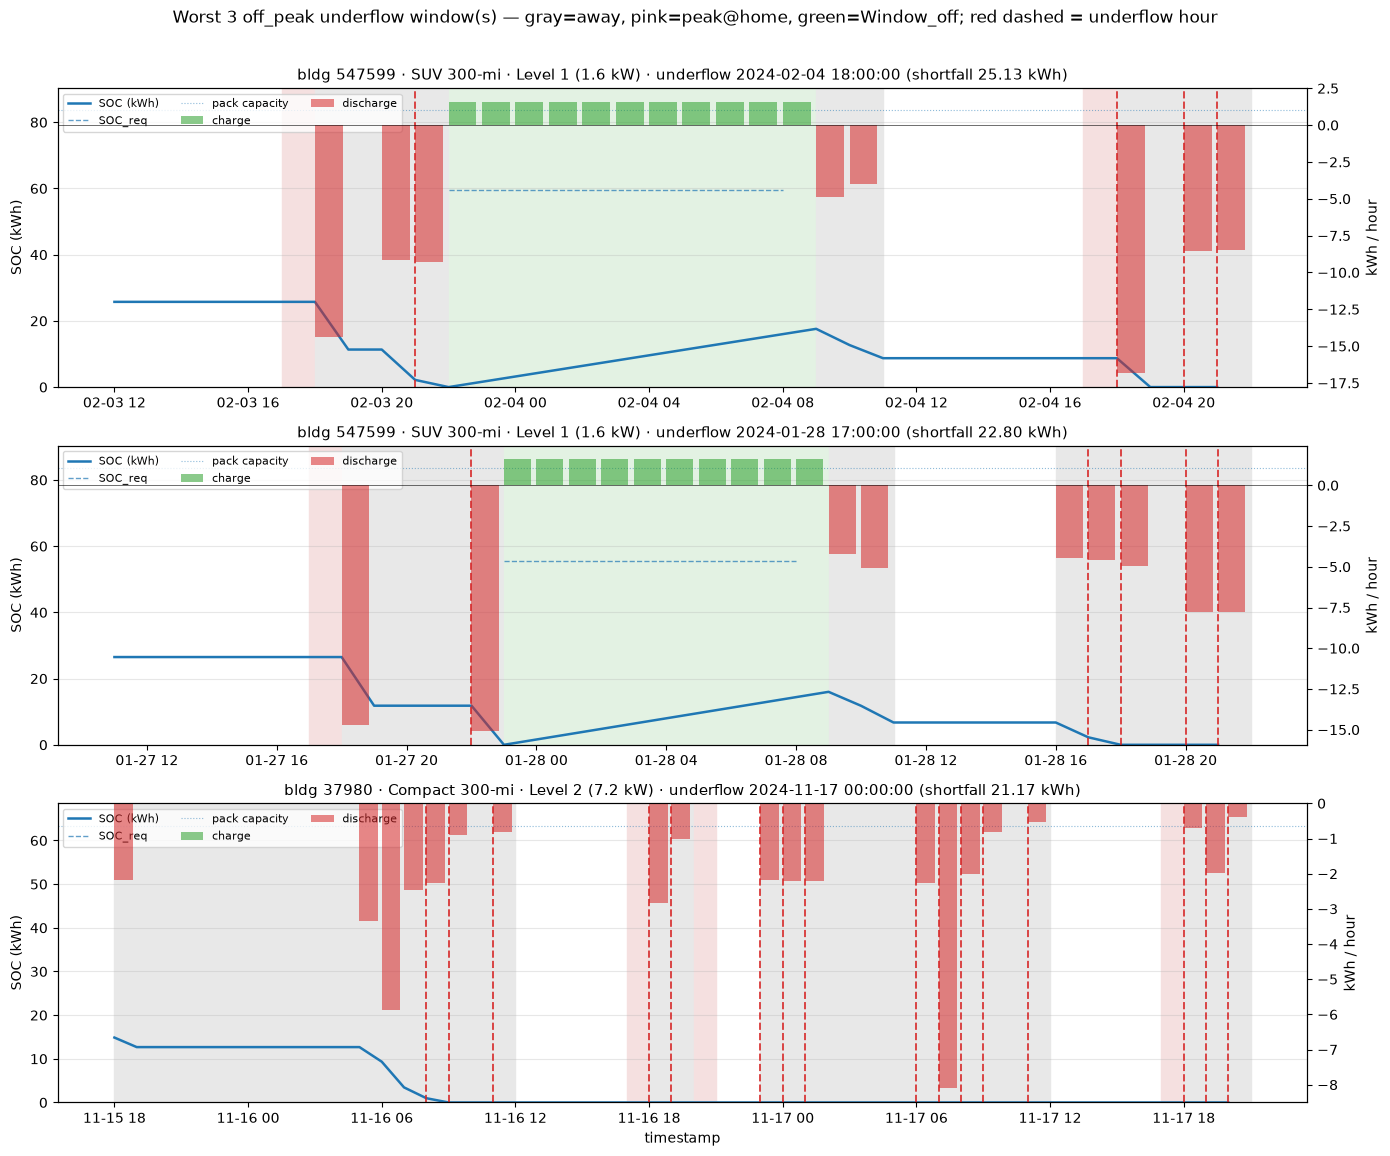

In [47]:
# SOC / charge / discharge around the worst off_peak underflow events
n_events = detail_events.height
if n_events == 0:
    print("No off_peak underflow hours to plot.")
else:
    fig, axes = plt.subplots(n_events, 1, figsize=(14, 3.8 * n_events), sharex=False)
    if n_events == 1:
        axes = [axes]

    for ax, event in zip(axes, detail_events.iter_rows(named=True)):
        key = (event["bldg_id"], event["vehicle_id"], event["calendar_date"])
        frame = underflow_plot_frames[key]
        capacity = float(event["battery_capacity_kwh"])
        ts = frame["timestamp"].to_numpy()
        soc = frame["soc_kwh"].to_numpy()
        charge = frame["charge_kwh"].to_numpy()
        discharge = frame["discharge_kwh"].to_numpy()
        at_home = frame["at_home"].to_list()
        is_off_peak = frame["is_off_peak"].to_list()
        charge_allowed = frame["charge_allowed"].to_list()
        underflow = frame["soc_underflow"].to_list()
        soc_target = frame["soc_target_kwh"].to_numpy()

        # Background: away (gray), peak-at-home (pink), Window_off (pale green)
        for i in range(len(ts)):
            t0, t1 = ts[i], ts[i] + np.timedelta64(1, "h")
            if not at_home[i]:
                ax.axvspan(t0, t1, color="#e8e8e8", zorder=0)
            elif not is_off_peak[i]:
                ax.axvspan(t0, t1, color="#f5e0e0", zorder=0)
            elif charge_allowed[i]:
                ax.axvspan(t0, t1, color="#e3f2e3", zorder=0)

        ax.plot(ts, soc, color="#1f77b4", lw=1.8, label="SOC (kWh)")
        # SOC_req only where the policy is targeting (charge_allowed hours)
        target_plot = np.where(np.asarray(charge_allowed), soc_target, np.nan)
        ax.plot(ts, target_plot, color="#1f77b4", lw=1.0, ls="--", alpha=0.7, label="SOC_req")
        ax.axhline(capacity, color="#1f77b4", lw=0.8, ls=":", alpha=0.5, label="pack capacity")

        ax2 = ax.twinx()
        ax2.bar(ts, charge, width=np.timedelta64(50, "m"), align="edge",
                color="#2ca02c", alpha=0.55, label="charge")
        ax2.bar(ts, -discharge, width=np.timedelta64(50, "m"), align="edge",
                color="#d62728", alpha=0.55, label="discharge")
        ax2.set_ylabel("kWh / hour")
        ax2.axhline(0, color="k", lw=0.4)

        for i, flag in enumerate(underflow):
            if flag:
                ax.axvline(ts[i], color="#d62728", lw=1.4, ls="--", alpha=0.85)

        ax.set_ylim(0, capacity * 1.08)
        ax.set_ylabel("SOC (kWh)")
        ax.set_title(
            f"bldg {event['bldg_id']} · {event['option_short']} · "
            f"{event['charger_level']} ({event['charger_power_kw']} kW) · "
            f"underflow {event['first_underflow_ts']} "
            f"(shortfall {event['total_shortfall_kwh']:.2f} kWh)",
            fontsize=11,
        )
        ax.grid(True, axis="y", alpha=0.3)

        # Combined legend
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8, ncol=3)

    axes[-1].set_xlabel("timestamp")
    fig.suptitle(
        f"Worst {n_events} off_peak underflow window(s) — gray=away, pink=peak@home, "
        "green=Window_off; red dashed = underflow hour",
        fontsize=12,
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


### Is the underflow physically unavoidable?

`cost_minimizing` is a **perfect-foresight LP**, and it is always feasible because it may *shed*
trip energy (`shed_load_kwh`) when charging cannot cover the draw. `soc_underflow` is then derived
from the **full planned** discharge, so under this policy:

> an underflow hour ⟺ the LP shed energy there ⟺ **no charging schedule could have served that
> trip** at the vehicle's assigned power, home hours, pack size, and starting SOC.

So yes — for those vehicles the trips are genuinely infeasible, not just badly timed.

**With §8 duty-conditional chargers this list should now be empty.** A level is only assigned when
immediate home charging covers the trips under perfect SOC foresight, and the LP is at least as
capable as immediate charging, so it can always serve the draw. Any vehicle appearing below would
mean the §8 feasibility check and this LP disagree — worth investigating. The counterfactual
re-solve below still runs whenever affected vehicles exist, attributing the cause across powers:

| Power | Meaning |
|---|---|
| config L1 / L2 | scenario `level1/level2_charger_power_kw` (default 1.6 / 7.2) |
| 5.69 kW | ResStock TRG average-draw Level 2 |
| 11.5 kW | 48 A Level 2 headroom check |

- feasible at config L2 but not at the assigned power → **Level 1 assignment** is the cause
- infeasible at config L2 but feasible at 7.2 → the **configured L2 rating** binds
- infeasible even at 7.2 → **structural**: it would have underflowed under the old 7.2 kW config too
  (very long driving days, few home hours, or a pack too small for the day's duty miles)



In [48]:
# Attribute cost_minimizing underflow: re-solve each affected vehicle's LP at other powers
from utils.EVs.ChargingSimulator import DEFAULT_LEVEL2_CHARGER_KW
from utils.EVs.charging import compute_hourly_soc, schedule_cost_minimizing_charging

CM_MAX_VEHICLES = 20  # cap LP re-solves (one full-year LP per vehicle per power)
# Include the scenario's configured L1/L2 powers plus the old 7.2 default and a
# higher headroom check. Deduplicate if the config already matches one of those.
_cfg_l1 = float(config.level1_charger_power_kw)
_cfg_l2 = float(config.level2_charger_power_kw)
COUNTERFACTUAL_KW = list(dict.fromkeys([
    _cfg_l1,
    _cfg_l2,
    RESSTOCK_LEVEL1_CHARGER_KW,
    RESSTOCK_LEVEL2_CHARGER_KW,
    DEFAULT_LEVEL2_CHARGER_KW,
    11.5,
]))
shed_penalty = (
    config.shed_load_penalty_usd_per_kwh
    if config.shed_load_penalty_usd_per_kwh is not None
    else 1_000_000.0
)

cm_soc = fleet_soc_by_strategy["cost_minimizing"]
cm_underflow = cm_soc.filter(pl.col("soc_underflow")).join(
    ev_attributes.select(
        "bldg_id", "vehicle_id", "battery_capacity_kwh", "option_short",
        "max_daily_miles", "charger_level", "charger_power_kw",
    ),
    on=["bldg_id", "vehicle_id"],
    how="left",
)
cm_shed_total = float(cm_soc["shed_load_kwh"].sum()) if "shed_load_kwh" in cm_soc.columns else float("nan")
cm_keys = cm_underflow.select("bldg_id", "vehicle_id").unique().sort(["bldg_id", "vehicle_id"])
print(
    f"cost_minimizing: {cm_underflow.height} underflow hour(s) across {cm_keys.height} vehicle(s); "
    f"LP shed {cm_shed_total:,.2f} kWh of trip energy"
)
print("Underflow under a perfect-foresight LP == physically unservable trip energy.\n")
display(
    cm_underflow.group_by("charger_level", "charger_power_kw")
    .agg(
        pl.col("bldg_id").n_unique().alias("n_vehicles"),
        pl.len().alias("underflow_hours"),
        (pl.col("discharge_kwh") - pl.col("soc_kwh")).sum().round(2).alias("shortfall_kwh"),
    )
    .sort("charger_level")
)

test_keys = cm_keys.head(CM_MAX_VEHICLES)
if test_keys.height < cm_keys.height:
    print(f"Re-solving the first {test_keys.height} of {cm_keys.height} affected vehicles")

cm_rows = []
for bldg_id, vehicle_id in test_keys.iter_rows():
    veh_mask = (pl.col("bldg_id") == bldg_id) & (pl.col("vehicle_id") == vehicle_id)
    veh = cm_soc.filter(veh_mask).sort("timestamp")
    attrs = ev_attributes.filter(veh_mask).row(0, named=True)
    capacity = float(attrs["battery_capacity_kwh"])
    assigned_kw = float(attrs["charger_power_kw"])
    at_home = veh["at_home"].to_numpy()
    discharge = veh["discharge_kwh"].to_numpy()
    # generate_soc starts a vehicle full when config.initial_soc_kwh is None.
    start_soc = capacity if config.initial_soc_kwh is None else float(config.initial_soc_kwh)
    first_uf_ts = veh.filter(pl.col("soc_underflow"))["timestamp"][0]

    row = {
        "bldg_id": bldg_id,
        "vehicle_id": vehicle_id,
        "charger_level": attrs["charger_level"],
        "assigned_kw": assigned_kw,
        "capacity_kwh": round(capacity, 1),
        "option_short": attrs["option_short"],
        "max_daily_duty_mi": round(float(attrs["max_daily_miles"]), 1),
        "home_hours_yr": int(at_home.sum()),
        "annual_draw_kwh": round(float(discharge.sum()), 1),
        "first_underflow_ts": first_uf_ts,
        "uf_hours_assigned": int(veh["soc_underflow"].sum()),
    }
    for kw in COUNTERFACTUAL_KW:
        charge_cf, shed_cf = schedule_cost_minimizing_charging(
            at_home,
            discharge,
            battery_capacity_kwh=capacity,
            charger_power_kw=kw,
            initial_soc_kwh=start_soc,
            hourly_price_usd_per_kwh=fleet_tou_prices,
            shed_load_penalty_usd_per_kwh=shed_penalty,
        )
        _soc_cf, uf_cf = compute_hourly_soc(discharge, charge_cf, initial_soc_kwh=start_soc)
        row[f"uf_hrs@{kw}"] = int(uf_cf.sum())
        row[f"shed_kwh@{kw}"] = round(float(shed_cf.sum()), 2)
    cm_rows.append(row)

def _attribute(row: dict) -> str:
    """Which charger-power change (if any) explains this vehicle's infeasibility."""
    uf_at_cfg_l2 = row[f"uf_hrs@{_cfg_l2}"]
    uf_l2_old = row[f"uf_hrs@{DEFAULT_LEVEL2_CHARGER_KW}"]
    is_l1 = abs(row["assigned_kw"] - _cfg_l1) < 1e-9
    if uf_l2_old > 0:
        # Would have underflowed under the old 7.2 kW config too — not a charger-change effect.
        return (
            "structural (infeasible at 11.5 kW too)"
            if row["uf_hrs@11.5"] > 0
            else "structural (needs > 7.2 kW)"
        )
    if uf_at_cfg_l2 == 0:
        # Configured L2 power suffices, so the vehicle's own lower rating is what binds.
        return f"Level 1 assignment ({_cfg_l1} kW)" if is_l1 else "unexpected (feasible at assigned kW)"
    # Infeasible at configured L2 but fine at 7.2: L2 rating binds (and L1 if assigned L1).
    if is_l1:
        return f"L1 + configured L2 rating ({_cfg_l2} kW)"
    return f"configured L2 rating ({_cfg_l2} kW; old default was 7.2)"


if not cm_rows:
    # Expected under §8: a level is only assigned if immediate home charging covers the
    # trips, and the LP is at least as capable, so there is nothing left to attribute.
    cm_counterfactual = None
    print(
        "No cost_minimizing underflow to attribute — §8 assigns only charger levels that "
        "cover each vehicle's trips under perfect SOC foresight "
        f"(charger_buffer_fraction={config.charger_buffer_fraction})."
    )
else:
    cm_counterfactual = pl.DataFrame(cm_rows)
    cm_counterfactual = cm_counterfactual.with_columns(
        pl.Series("cause", [_attribute(r) for r in cm_counterfactual.iter_rows(named=True)])
    )
    display(cm_counterfactual)

    print("Attribution across affected vehicles:")
    display(
        cm_counterfactual.group_by("cause", "charger_level")
        .agg(
            pl.len().alias("n_vehicles"),
            pl.col("uf_hours_assigned").sum().alias("underflow_hours"),
        )
        .sort("n_vehicles", descending=True)
    )
    print(
        "Read the uf_hrs@ columns as: underflow hours this same vehicle would see if its charger "
        "were rated at that power (same trips, pack, and starting SOC)."
    )



cost_minimizing: 0 underflow hour(s) across 0 vehicle(s); LP shed nan kWh of trip energy
Underflow under a perfect-foresight LP == physically unservable trip energy.



charger_level,charger_power_kw,n_vehicles,underflow_hours,shortfall_kwh
str,f64,u32,u32,f64


No cost_minimizing underflow to attribute — §8 assigns only charger levels that cover each vehicle's trips under perfect SOC foresight (charger_buffer_fraction=0.2).


## 11. Fleet charging vs base residential load

July-week 2×2 panels and annual peak bars, shown two ways:

1. **EV charging only** (same as §9)
2. **Base residential + EV** stacked

Load curves: `res_2024_amy2018_2_sb` for the 2024 TMY3 EV sample (no published TMY3
hourly loads here). Timestamps remapped 2018 → 2024 by calendar month/day/hour.
2024 baseline electricity has no EV end-use.



In [49]:
LOAD_RELEASE = "res_2024_amy2018_2_sb"
PATH_LOADS_DIR = (
    Path("/ebs/data/nrel/resstock")
    / LOAD_RELEASE
    / "load_curve_hourly"
    / f"state={STATE}"
    / "upgrade=00"
)
ELEC_COL = "out.electricity.total.energy_consumption"

ev_bldg_ids = ev_attributes["bldg_id"].unique().to_list()
load_paths = [PATH_LOADS_DIR / f"{bid}-0.parquet" for bid in ev_bldg_ids]
missing = [p for p in load_paths if not p.exists()]
assert not missing, f"Missing load curves for {len(missing)} EV buildings (e.g. {missing[:3]})"

print(
    f"Loading base residential electricity for {len(load_paths):,} EV buildings "
    f"from {PATH_LOADS_DIR}"
)

# Sum unweighted kWh across EV buildings (same aggregation as fleet_charge_kwh)
base_residential_hourly = (
    pl.scan_parquet(load_paths)
    .select(
        "timestamp",
        pl.col(ELEC_COL).alias("base_elec_kwh"),
    )
    .group_by("timestamp")
    .agg(pl.col("base_elec_kwh").sum())
    .sort("timestamp")
    .with_columns(
        # Align AMY2018 clock to the 2024 NHTS simulation calendar
        pl.datetime(
            2024,
            pl.col("timestamp").dt.month(),
            pl.col("timestamp").dt.day(),
            pl.col("timestamp").dt.hour(),
        ).alias("timestamp"),
    )
    .collect()
)

base_residential_week = base_residential_hourly.filter(
    (pl.col("timestamp") >= FLEET_WINDOW_START) & (pl.col("timestamp") <= FLEET_WINDOW_END)
).sort("timestamp")

print(
    f"Base residential hours: {base_residential_hourly.height:,}  "
    f"July-week hours: {base_residential_week.height:,}  "
    f"week mean={base_residential_week['base_elec_kwh'].mean():.1f} kWh/h  "
    f"week max={base_residential_week['base_elec_kwh'].max():.1f} kWh/h"
)

# Combined annual series for peak bars (inner-join drops 2024-02-29; AMY2018 has no leap day)
combined_annual_by_strategy = {}
combined_summary_rows = []
base_annual_max = float(base_residential_hourly["base_elec_kwh"].max())

for strategy in strategies_order:
    annual = fleet_annual_load_by_strategy[strategy].join(
        base_residential_hourly, on="timestamp", how="inner"
    ).with_columns(
        (pl.col("base_elec_kwh") + pl.col("fleet_charge_kwh")).alias("total_elec_kwh")
    )
    combined_annual_by_strategy[strategy] = annual
    total = annual["total_elec_kwh"]
    total_peak = annual.filter(pl.col("is_peak"))["total_elec_kwh"]
    hour_of_max = annual.sort("total_elec_kwh", descending=True)["timestamp"][0]
    combined_summary_rows.append({
        "strategy": strategy,
        "annual_max_hourly_base_kwh": round(base_annual_max, 2),
        "annual_max_hourly_ev_kwh": round(float(annual["fleet_charge_kwh"].max()), 2),
        "annual_max_hourly_total_kwh": round(float(total.max()), 2),
        "annual_max_peak_hour_total_kwh": round(
            float(total_peak.max()) if total_peak.len() else 0.0, 2
        ),
        "hour_of_annual_max_total": hour_of_max,
    })

display(pl.DataFrame(combined_summary_rows))


Loading base residential electricity for 178 EV buildings from /ebs/data/nrel/resstock/res_2024_amy2018_2_sb/load_curve_hourly/state=MD/upgrade=00
Base residential hours: 8,760  July-week hours: 168  week mean=447.4 kWh/h  week max=687.3 kWh/h


strategy,annual_max_hourly_base_kwh,annual_max_hourly_ev_kwh,annual_max_hourly_total_kwh,annual_max_peak_hour_total_kwh,hour_of_annual_max_total
str,f64,f64,f64,f64,datetime[μs]
"""immediate""",945.39,132.63,1001.17,1001.17,2024-01-05 20:00:00
"""off_peak""",945.39,290.54,983.52,897.97,2024-01-17 21:00:00
"""off_peak_immediate""",945.39,273.84,1099.77,897.97,2024-01-06 21:00:00
"""cost_minimizing""",945.39,97.66,991.03,897.97,2024-01-07 07:00:00


=== EV charging only ===


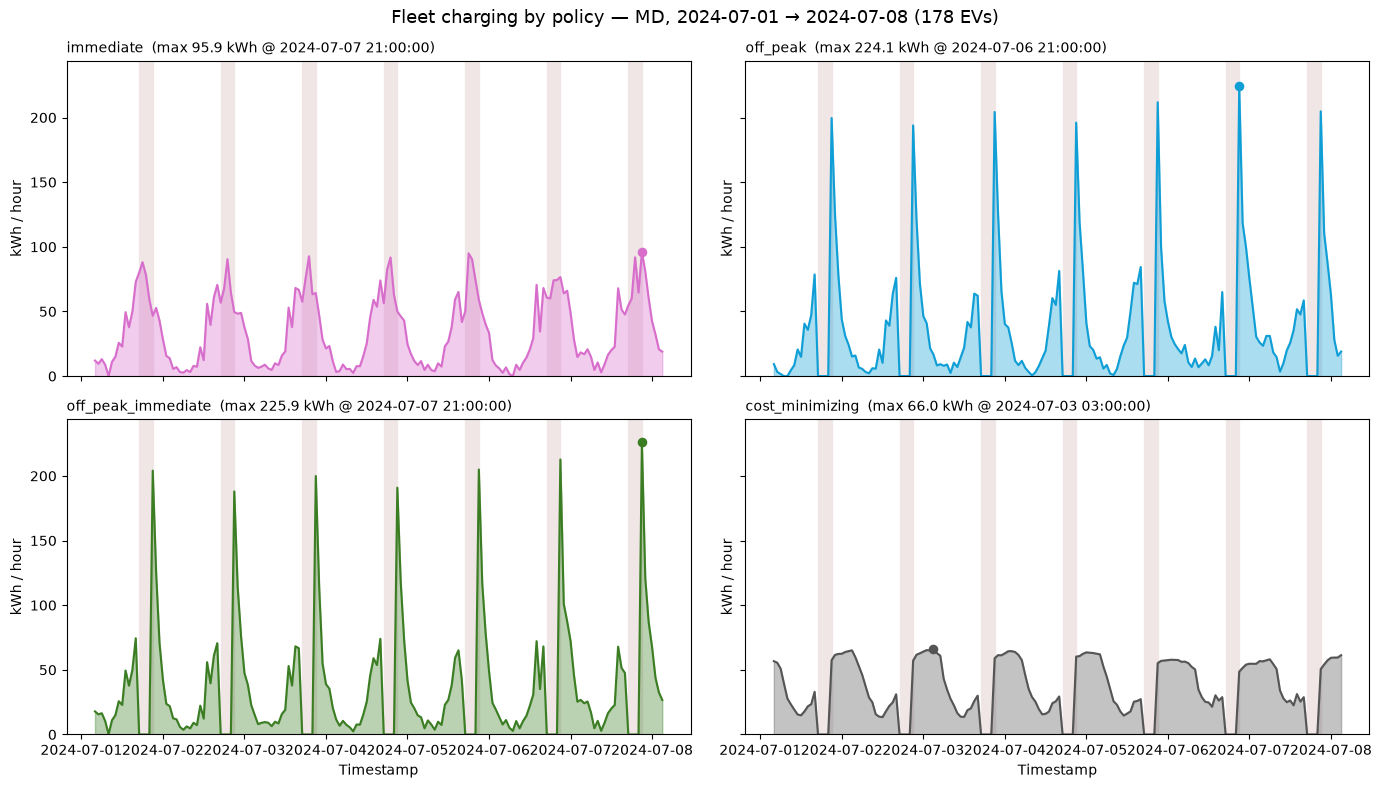

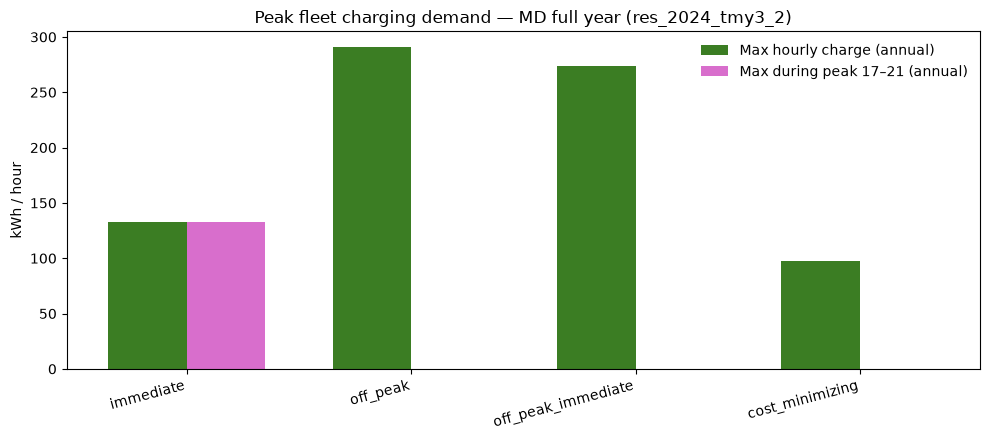

Hour of annual max fleet charge by strategy


strategy,annual_max_hourly_charge_kwh,hour_of_annual_max_charge
str,f64,datetime[μs]
"""immediate""",132.63,2024-01-17 20:00:00
"""off_peak""",290.54,2024-02-04 21:00:00
"""off_peak_immediate""",273.84,2024-01-17 21:00:00
"""cost_minimizing""",97.66,2024-01-18 03:00:00


=== Base residential + EV charging ===


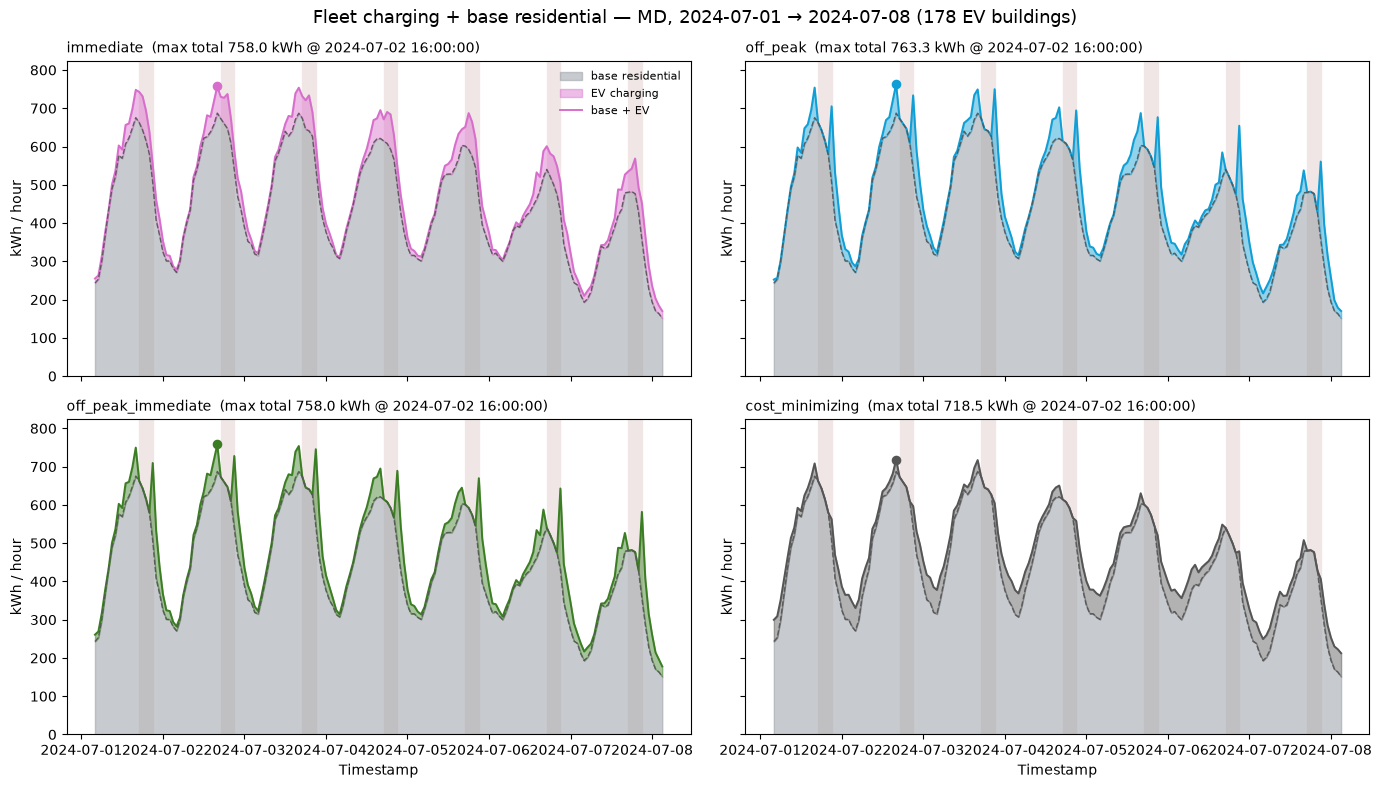

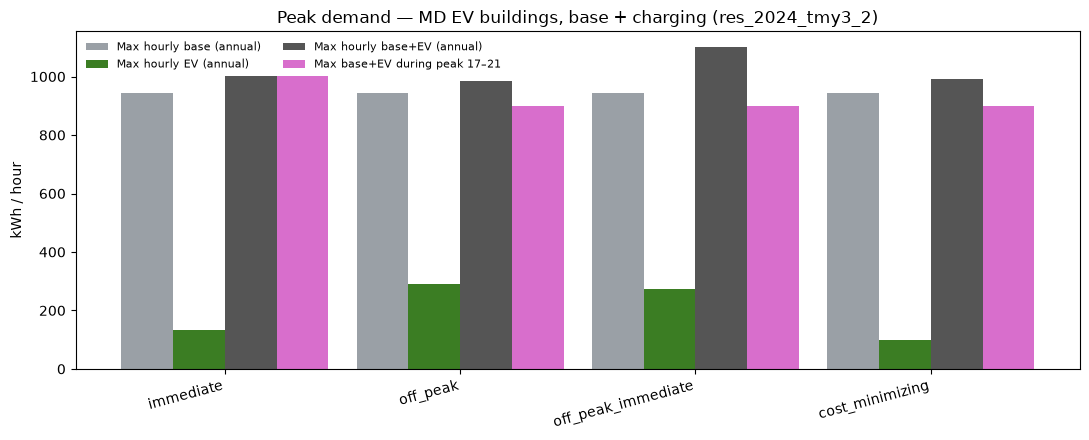

Hour of annual max base+EV load by strategy


strategy,annual_max_hourly_total_kwh,hour_of_annual_max_total
str,f64,datetime[μs]
"""immediate""",1001.17,2024-01-05 20:00:00
"""off_peak""",983.52,2024-01-17 21:00:00
"""off_peak_immediate""",1099.77,2024-01-06 21:00:00
"""cost_minimizing""",991.03,2024-01-07 07:00:00


In [50]:
COLOR_BASE = "#9AA0A6"


def plot_fleet_ev_only(
    load_by_strategy: dict[str, pl.DataFrame],
    summary_rows: list[dict],
    *,
    title_week: str,
    title_bars: str,
) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
    fig.suptitle(title_week, fontsize=13)
    ymax = max(float(load["fleet_charge_kwh"].max()) for load in load_by_strategy.values()) * 1.08

    for ax, strategy in zip(axes.ravel(), strategies_order, strict=False):
        load = load_by_strategy[strategy]
        ts = load["timestamp"].to_numpy()
        vals = load["fleet_charge_kwh"].to_numpy()
        for i, is_peak in enumerate(load["is_peak"].to_list()):
            if is_peak:
                ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)
        ax.fill_between(ts, vals, color=STRATEGY_COLORS[strategy], alpha=0.35)
        ax.plot(ts, vals, color=STRATEGY_COLORS[strategy], linewidth=1.5)
        imax = int(np.argmax(vals))
        ax.scatter([ts[imax]], [vals[imax]], color=STRATEGY_COLORS[strategy], s=35, zorder=3)
        ax.set_ylim(0, ymax)
        ax.set_title(
            f"{strategy}  (max {vals[imax]:.1f} kWh @ {load['timestamp'][imax]})",
            loc="left",
            fontsize=10,
        )
        ax.set_ylabel("kWh / hour")

    axes[1, 0].set_xlabel("Timestamp")
    axes[1, 1].set_xlabel("Timestamp")
    fig.tight_layout()
    plt.show()

    summary = pl.DataFrame(summary_rows).sort(
        pl.col("strategy").replace({s: i for i, s in enumerate(strategies_order)})
    )
    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(summary.height)
    width = 0.35
    ax.bar(
        x - width / 2,
        summary["annual_max_hourly_charge_kwh"].to_numpy(),
        width,
        label="Max hourly charge (annual)",
        color=COLOR_GREEN,
    )
    ax.bar(
        x + width / 2,
        summary["annual_max_peak_hour_charge_kwh"].to_numpy(),
        width,
        label="Max during peak 17–21 (annual)",
        color=COLOR_PINK,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(summary["strategy"].to_list(), rotation=15, ha="right")
    ax.set_ylabel("kWh / hour")
    ax.set_title(title_bars)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

    print("Hour of annual max fleet charge by strategy")
    display(summary.select("strategy", "annual_max_hourly_charge_kwh", "hour_of_annual_max_charge"))


def plot_fleet_ev_plus_base(
    load_by_strategy: dict[str, pl.DataFrame],
    base_week: pl.DataFrame,
    combined_summary_rows: list[dict],
    *,
    title_week: str,
    title_bars: str,
) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
    fig.suptitle(title_week, fontsize=13)

    ymax = 0.0
    for strategy in strategies_order:
        load = load_by_strategy[strategy].join(
            base_week.select("timestamp", "base_elec_kwh"), on="timestamp", how="inner"
        )
        ymax = max(ymax, float((load["base_elec_kwh"] + load["fleet_charge_kwh"]).max()))
    ymax *= 1.08

    for ax, strategy in zip(axes.ravel(), strategies_order, strict=False):
        load = (
            load_by_strategy[strategy]
            .join(base_week.select("timestamp", "base_elec_kwh"), on="timestamp", how="inner")
            .sort("timestamp")
        )
        ts = load["timestamp"].to_numpy()
        base = load["base_elec_kwh"].to_numpy()
        ev = load["fleet_charge_kwh"].to_numpy()
        total = base + ev

        for i, is_peak in enumerate(load["is_peak"].to_list()):
            if is_peak:
                ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

        ax.fill_between(ts, 0, base, color=COLOR_BASE, alpha=0.55, label="base residential")
        ax.fill_between(
            ts, base, total, color=STRATEGY_COLORS[strategy], alpha=0.45, label="EV charging"
        )
        ax.plot(ts, total, color=STRATEGY_COLORS[strategy], linewidth=1.4, label="base + EV")
        ax.plot(ts, base, color="#555555", linewidth=1.0, linestyle="--", alpha=0.9)

        imax = int(np.argmax(total))
        ax.scatter([ts[imax]], [total[imax]], color=STRATEGY_COLORS[strategy], s=35, zorder=3)
        ax.set_ylim(0, ymax)
        ax.set_title(
            f"{strategy}  (max total {total[imax]:.1f} kWh @ {load['timestamp'][imax]})",
            loc="left",
            fontsize=10,
        )
        ax.set_ylabel("kWh / hour")

    axes[0, 0].legend(frameon=False, fontsize=8, loc="upper right")
    axes[1, 0].set_xlabel("Timestamp")
    axes[1, 1].set_xlabel("Timestamp")
    fig.tight_layout()
    plt.show()

    summary_combined = pl.DataFrame(combined_summary_rows).sort(
        pl.col("strategy").replace({s: i for i, s in enumerate(strategies_order)})
    )
    fig, ax = plt.subplots(figsize=(11, 4.5))
    x = np.arange(summary_combined.height)
    width = 0.22
    ax.bar(
        x - 1.5 * width,
        summary_combined["annual_max_hourly_base_kwh"].to_numpy(),
        width,
        label="Max hourly base (annual)",
        color=COLOR_BASE,
    )
    ax.bar(
        x - 0.5 * width,
        summary_combined["annual_max_hourly_ev_kwh"].to_numpy(),
        width,
        label="Max hourly EV (annual)",
        color=COLOR_GREEN,
    )
    ax.bar(
        x + 0.5 * width,
        summary_combined["annual_max_hourly_total_kwh"].to_numpy(),
        width,
        label="Max hourly base+EV (annual)",
        color="#555555",
    )
    ax.bar(
        x + 1.5 * width,
        summary_combined["annual_max_peak_hour_total_kwh"].to_numpy(),
        width,
        label="Max base+EV during peak 17–21",
        color=COLOR_PINK,
    )
    ax.set_xticks(x)
    ax.set_xticklabels(summary_combined["strategy"].to_list(), rotation=15, ha="right")
    ax.set_ylabel("kWh / hour")
    ax.set_title(title_bars)
    ax.legend(frameon=False, fontsize=8, ncols=2)
    fig.tight_layout()
    plt.show()

    print("Hour of annual max base+EV load by strategy")
    display(
        summary_combined.select(
            "strategy", "annual_max_hourly_total_kwh", "hour_of_annual_max_total"
        )
    )


week_label = (
    f"{STATE}, {FLEET_WINDOW_START.date()} → {(FLEET_WINDOW_END - timedelta(hours=3)).date()}"
)

print("=== EV charging only ===")
plot_fleet_ev_only(
    fleet_load_by_strategy,
    fleet_summary_rows,
    title_week=f"Fleet charging by policy — {week_label} ({ev_attributes.height} EVs)",
    title_bars=f"Peak fleet charging demand — {STATE} full year ({config.release})",
)

print("=== Base residential + EV charging ===")
plot_fleet_ev_plus_base(
    fleet_load_by_strategy,
    base_residential_week,
    combined_summary_rows,
    title_week=(
        f"Fleet charging + base residential — {week_label} "
        f"({ev_attributes.height} EV buildings)"
    ),
    title_bars=f"Peak demand — {STATE} EV buildings, base + charging ({config.release})",
)


### ResStock 2025 MD — published July-week loads

Aggregate **NREL’s** hourly EV charging and base residential electricity for MD buildings
with `in.electric_vehicle_ownership == Yes`. This is ResStock’s published end-use output —
**not** a re-run of our NHTS / charging-policy pipeline.

- EV: `out.electricity.ev_charging.energy_consumption..kwh`
- Base: `out.electricity.total` − EV charging
- Window: first week of July (AMY2018 clock remapped to the notebook’s 2024 July labels)


In [51]:
# Published ResStock 2025 loads for NREL EV owners (same July week as §9/§10)
PATH_LOADS_DIR_2025 = (
    Path("/ebs/data/nrel/resstock")
    / RELEASE_2025
    / "load_curve_hourly"
    / f"state={STATE}"
    / "upgrade=00"
)
ELEC_TOTAL_2025 = "out.electricity.total.energy_consumption..kwh"
ELEC_EV_2025 = "out.electricity.ev_charging.energy_consumption..kwh"

ev_bldg_ids_2025 = bldg_ev_2025.filter(pl.col("has_ev"))["bldg_id"].unique().to_list()
load_paths_2025 = [PATH_LOADS_DIR_2025 / f"{bid}-0.parquet" for bid in ev_bldg_ids_2025]
missing_2025 = [p for p in load_paths_2025 if not p.exists()]
assert not missing_2025, (
    f"Missing 2025 load curves for {len(missing_2025)} EV buildings (e.g. {missing_2025[:3]})"
)

print(
    f"Loading published loads for {len(load_paths_2025):,} NREL EV buildings "
    f"from {PATH_LOADS_DIR_2025}"
)

nrel_hourly_2025 = (
    pl.scan_parquet(load_paths_2025)
    .select(
        "timestamp",
        pl.col(ELEC_EV_2025).cast(pl.Float64).alias("ev_charge_kwh"),
        (
            pl.col(ELEC_TOTAL_2025).cast(pl.Float64)
            - pl.col(ELEC_EV_2025).cast(pl.Float64)
        ).alias("base_elec_kwh"),
    )
    .group_by("timestamp")
    .agg(
        pl.col("ev_charge_kwh").sum(),
        pl.col("base_elec_kwh").sum(),
    )
    .sort("timestamp")
    .with_columns(
        pl.datetime(
            2024,
            pl.col("timestamp").dt.month(),
            pl.col("timestamp").dt.day(),
            pl.col("timestamp").dt.hour(),
        ).alias("timestamp"),
    )
    .with_columns(
        (pl.col("base_elec_kwh") + pl.col("ev_charge_kwh")).alias("total_elec_kwh"),
        pl.col("timestamp").dt.hour().is_in(list(fleet_peak_hours)).alias("is_peak"),
    )
    .collect()
)

nrel_week_2025 = nrel_hourly_2025.filter(
    (pl.col("timestamp") >= FLEET_WINDOW_START) & (pl.col("timestamp") <= FLEET_WINDOW_END)
).sort("timestamp")

print(
    f"July-week hours: {nrel_week_2025.height:,}  "
    f"EV mean={nrel_week_2025['ev_charge_kwh'].mean():.1f}  "
    f"EV max={nrel_week_2025['ev_charge_kwh'].max():.1f}  "
    f"base max={nrel_week_2025['base_elec_kwh'].max():.1f}  "
    f"total max={nrel_week_2025['total_elec_kwh'].max():.1f} kWh/h"
)

# Peak EV charging (published ResStock end-use)
week_peak_row = nrel_week_2025.sort("ev_charge_kwh", descending=True).row(0, named=True)
annual_peak_row = nrel_hourly_2025.sort("ev_charge_kwh", descending=True).row(0, named=True)
peak_hours_annual = nrel_hourly_2025.filter(pl.col("is_peak"))
peak_window_row = peak_hours_annual.sort("ev_charge_kwh", descending=True).row(0, named=True)

print(f"\nPeak EV charging load — {RELEASE_2025} MD ({len(ev_bldg_ids_2025)} NREL EVs)")
print(
    f"  July-week max hourly EV:     {week_peak_row['ev_charge_kwh']:.2f} kWh/h "
    f"@ {week_peak_row['timestamp']}"
)
print(
    f"  Annual max hourly EV:        {annual_peak_row['ev_charge_kwh']:.2f} kWh/h "
    f"@ {annual_peak_row['timestamp']}"
)
print(
    f"  Annual max during peak 17–21: {peak_window_row['ev_charge_kwh']:.2f} kWh/h "
    f"@ {peak_window_row['timestamp']}"
)

total_peak_row = nrel_hourly_2025.sort("total_elec_kwh", descending=True).row(0, named=True)
print(
    f"  Annual max base+EV:          {total_peak_row['total_elec_kwh']:.2f} kWh/h "
    f"@ {total_peak_row['timestamp']} "
    f"(base={total_peak_row['base_elec_kwh']:.2f}, EV={total_peak_row['ev_charge_kwh']:.2f})"
)

display(
    nrel_week_2025.select(
        "ev_charge_kwh", "base_elec_kwh", "total_elec_kwh"
    ).describe()
)



Loading published loads for 127 NREL EV buildings from /ebs/data/nrel/resstock/res_2025_amy2018_1/load_curve_hourly/state=MD/upgrade=00
July-week hours: 168  EV mean=31.3  EV max=116.8  base max=557.4  total max=636.8 kWh/h

Peak EV charging load — res_2025_amy2018_1 MD (127 NREL EVs)
  July-week max hourly EV:     116.79 kWh/h @ 2024-07-05 19:00:00
  Annual max hourly EV:        164.76 kWh/h @ 2024-01-02 21:00:00
  Annual max during peak 17–21: 148.80 kWh/h @ 2024-01-02 20:00:00
  Annual max base+EV:          797.86 kWh/h @ 2024-01-04 19:00:00 (base=665.26, EV=132.60)


statistic,ev_charge_kwh,base_elec_kwh,total_elec_kwh
str,f64,f64,f64
"""count""",168.0,168.0,168.0
"""null_count""",0.0,0.0,0.0
"""mean""",31.262884,352.833296,384.096181
"""std""",26.700816,114.480074,132.160644
"""min""",1.49617,109.14478,116.55452
"""25%""",10.08616,262.34731,275.57046
"""50%""",20.23163,344.26464,371.406291
"""75%""",49.68157,453.062906,492.714289
"""max""",116.79164,557.357212,636.826182


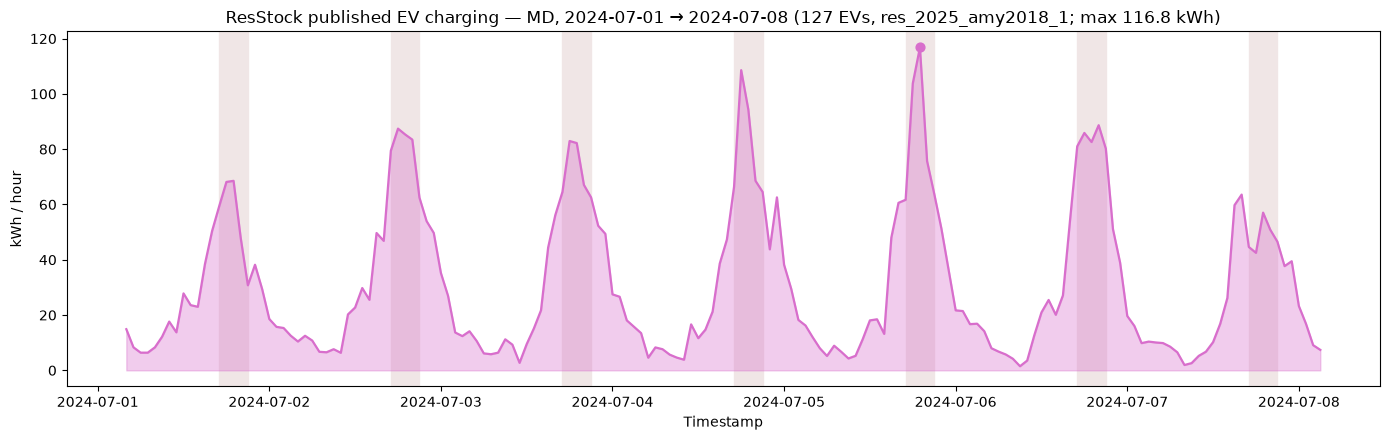

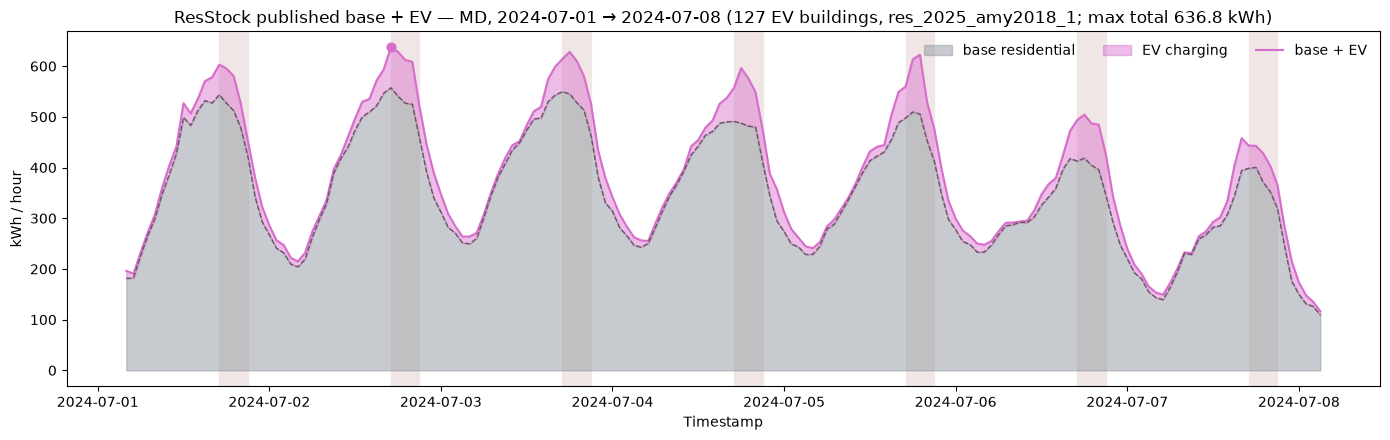

In [52]:
week_label_2025 = (
    f"{STATE}, {FLEET_WINDOW_START.date()} → {(FLEET_WINDOW_END - timedelta(hours=3)).date()}"
)
n_ev_2025 = len(ev_bldg_ids_2025)
ts = nrel_week_2025["timestamp"].to_numpy()
ev = nrel_week_2025["ev_charge_kwh"].to_numpy()
base = nrel_week_2025["base_elec_kwh"].to_numpy()
total = nrel_week_2025["total_elec_kwh"].to_numpy()
is_peak = nrel_week_2025["is_peak"].to_list()

def _shade_peak(ax):
    for i, peak in enumerate(is_peak):
        if peak:
            ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

# 1) EV charging only
fig, ax = plt.subplots(figsize=(14, 4.5))
_shade_peak(ax)
ax.fill_between(ts, ev, color=COLOR_PINK, alpha=0.35)
ax.plot(ts, ev, color=COLOR_PINK, linewidth=1.6)
imax = int(np.argmax(ev))
ax.scatter([ts[imax]], [ev[imax]], color=COLOR_PINK, s=40, zorder=3)
ax.set_ylabel("kWh / hour")
ax.set_xlabel("Timestamp")
ax.set_title(
    f"ResStock published EV charging — {week_label_2025} "
    f"({n_ev_2025} EVs, {RELEASE_2025}; max {ev[imax]:.1f} kWh)",
    fontsize=12,
)
fig.tight_layout()
plt.show()

# 2) Base residential + EV charging
fig, ax = plt.subplots(figsize=(14, 4.5))
_shade_peak(ax)
ax.fill_between(ts, 0, base, color=COLOR_BASE, alpha=0.55, label="base residential")
ax.fill_between(ts, base, total, color=COLOR_PINK, alpha=0.45, label="EV charging")
ax.plot(ts, total, color=COLOR_PINK, linewidth=1.5, label="base + EV")
ax.plot(ts, base, color="#555555", linewidth=1.0, linestyle="--", alpha=0.9)
imax = int(np.argmax(total))
ax.scatter([ts[imax]], [total[imax]], color=COLOR_PINK, s=40, zorder=3)
ax.set_ylabel("kWh / hour")
ax.set_xlabel("Timestamp")
ax.set_title(
    f"ResStock published base + EV — {week_label_2025} "
    f"({n_ev_2025} EV buildings, {RELEASE_2025}; max total {total[imax]:.1f} kWh)",
    fontsize=12,
)
ax.legend(frameon=False, ncols=3)
fig.tight_layout()
plt.show()


## 12. July-week loads — demo building + all-building base

First week of July 2024 (Mon 7/1 04:00 → Mon 7/8 03:00). Three charging policies — each vehicle uses its **§8 assigned L1/L2** power:

| Strategy | Behavior |
|---|---|
| `immediate` | Charge at the assigned home charger whenever home and not full |
| `off_peak_immediate` | Charge at the assigned charger whenever home and off-peak (config default) |
| `cost_minimizing` | Perfect-foresight LP on TOU prices (peak \$0.20, off-peak \$0.10) |

1. **Demo building** auto-selected from the fleet so `immediate` charges during peak hours on July 1 while `off_peak_immediate` waits for off-peak — travel schedule printed for verification, then 24-hour charge/discharge curves
2. **Aggregate:** ResStock base residential + fleet EV charging, shown for **all** MD buildings and again for **EV buildings only**

Reuses `fleet_soc_by_strategy` / `fleet_load_by_strategy` (§10).



In [53]:
# Ensure July window vars exist (from §8 or §9)
if "WINDOW_START" not in globals():
    WINDOW_START = FLEET_WINDOW_START
if "WINDOW_END" not in globals():
    WINDOW_END = FLEET_WINDOW_END

# Pick a building where immediate vs off_peak_immediate actually diverge on July 1.
# Prefer: daytime driving + immediate charges during peak hours (opi waits until off-peak).
PLOT_STRATEGIES = ["immediate", "off_peak_immediate", "cost_minimizing"]
PLOT_COLORS = {
    "immediate": COLOR_PINK,
    "off_peak_immediate": COLOR_GREEN,
    "cost_minimizing": "#0F9ED5",
}
COLOR_DISCHARGE = "#555555"

CHARGE_DAY_START = WINDOW_START  # July 1 04:00
CHARGE_DAY_END = CHARGE_DAY_START + timedelta(hours=23)
peak_hour_list = list(
    fleet_peak_hours
    if "fleet_peak_hours" in globals()
    else (peak_hours if "peak_hours" in globals() else (17, 18, 19, 20, 21))
)

imm_day = (
    fleet_soc_by_strategy["immediate"]
    .filter(
        (pl.col("timestamp") >= CHARGE_DAY_START)
        & (pl.col("timestamp") <= CHARGE_DAY_END)
    )
    .select("bldg_id", "vehicle_id", "timestamp", "charge_kwh", "discharge_kwh", "at_home")
    .with_columns(pl.col("timestamp").dt.hour().alias("clock_hour"))
)
opi_day = (
    fleet_soc_by_strategy["off_peak_immediate"]
    .filter(
        (pl.col("timestamp") >= CHARGE_DAY_START)
        & (pl.col("timestamp") <= CHARGE_DAY_END)
    )
    .select(
        "bldg_id",
        "vehicle_id",
        "timestamp",
        pl.col("charge_kwh").alias("charge_kwh_opi"),
    )
)

demo_candidates = (
    imm_day.join(opi_day, on=["bldg_id", "vehicle_id", "timestamp"], how="inner")
    .with_columns(
        (pl.col("charge_kwh") - pl.col("charge_kwh_opi")).abs().alias("abs_diff"),
        pl.col("clock_hour").is_in(peak_hour_list).alias("is_peak"),
    )
    .group_by("bldg_id")
    .agg(
        pl.col("abs_diff").sum().alias("charge_l1"),
        pl.col("charge_kwh").filter(pl.col("is_peak")).sum().alias("imm_peak_charge"),
        pl.col("charge_kwh_opi").filter(pl.col("is_peak")).sum().alias("opi_peak_charge"),
        pl.col("discharge_kwh").sum().alias("day_discharge"),
        pl.col("charge_kwh").sum().alias("imm_charge"),
        pl.col("charge_kwh_opi").sum().alias("opi_charge"),
    )
    .filter(pl.col("charge_l1") > 0.5)
    .filter(pl.col("imm_peak_charge") > 0.5)  # immediate uses peak hours
    .filter(pl.col("opi_peak_charge") < 0.05)  # off_peak_immediate avoids peak
    .filter(pl.col("day_discharge") > 1.0)  # actually drove that day
    .sort("charge_l1", descending=True)
)

assert demo_candidates.height >= 1, (
    "No building found where immediate charges on-peak and off_peak_immediate does not "
    "on the July 1 travel day — check fleet_soc_by_strategy."
)

DEMO_BLDG = demo_candidates["bldg_id"][0]
print(
    f"Selected demo building {DEMO_BLDG} "
    f"(L1 charge diff={demo_candidates['charge_l1'][0]:.1f} kWh; "
    f"imm peak={demo_candidates['imm_peak_charge'][0]:.1f} kWh; "
    f"opi peak={demo_candidates['opi_peak_charge'][0]:.1f} kWh)"
)
display(demo_candidates.head(8))

demo_trips = trip_schedules.filter(pl.col("bldg_id") == DEMO_BLDG)
demo_attrs = ev_attributes.filter(pl.col("bldg_id") == DEMO_BLDG)

# Rebuild July-week windows from fleet SOC for the selected building
window_by_strategy = {
    strategy: (
        fleet_soc_by_strategy[strategy]
        .filter(pl.col("bldg_id") == DEMO_BLDG)
        .filter(
            (pl.col("timestamp") >= WINDOW_START) & (pl.col("timestamp") <= WINDOW_END)
        )
        .sort("timestamp")
        .with_columns(
            pl.col("timestamp").dt.hour().alias("clock_hour"),
            pl.col("timestamp").dt.hour().is_in(peak_hour_list).alias("is_peak"),
        )
    )
    for strategy in PLOT_STRATEGIES
}

demo_week_trips = (
    demo_trips.filter(
        (pl.col("travel_date") >= WINDOW_START) & (pl.col("travel_date") < WINDOW_END)
    )
    .sort("travel_date", "tour_id", "trip_departure_date", "trip_departure_hour")
    .select(
        "bldg_id",
        "vehicle_id",
        "travel_date",
        "tour_id",
        "trip_departure_date",
        "trip_departure_hour",
        "trip_arrival_date",
        "trip_arrival_hour",
        "trip_miles_driven",
        "tour_departure_date",
        "tour_departure_hour",
        "tour_arrival_date",
        "tour_arrival_hour",
    )
)

print(
    f"Building {DEMO_BLDG} — travel schedule "
    f"{WINDOW_START.date()} → {(WINDOW_END - timedelta(hours=3)).date()}"
)
print(
    f"  {demo_week_trips.height:,} trip legs  |  "
    f"{demo_week_trips['travel_date'].n_unique()} travel days  |  "
    f"{demo_week_trips['trip_miles_driven'].sum():.1f} miles"
)
display(demo_attrs.select(
    "bldg_id", "vehicle_id", "ev_option_name", "battery_capacity_kwh", "kwh_per_mile",
    "max_daily_miles", "charger_level", "charger_power_kw"
))
display(demo_week_trips)

demo_week_daily = (
    demo_week_trips.group_by("travel_date")
    .agg(
        pl.len().alias("n_trips"),
        pl.col("tour_id").n_unique().alias("n_tours"),
        pl.col("trip_miles_driven").sum().round(1).alias("daily_miles"),
        pl.col("trip_departure_hour").min().alias("first_dep_hour"),
        pl.col("trip_arrival_hour").max().alias("last_arr_hour"),
    )
    .sort("travel_date")
)
print("Daily totals")
display(demo_week_daily)



Selected demo building 515541 (L1 charge diff=36.3 kWh; imm peak=18.2 kWh; opi peak=0.0 kWh)


bldg_id,charge_l1,imm_peak_charge,opi_peak_charge,day_discharge,imm_charge,opi_charge
i32,f64,f64,f64,f64,f64,f64
515541,36.322123,18.161062,0.0,18.161062,18.161062,18.161062
299943,28.712406,14.356203,0.0,14.356203,14.356203,14.356203
115699,26.783012,13.391506,0.0,13.391506,13.391506,13.391506
530389,25.064723,12.532362,0.0,19.732362,19.732362,19.732362
84408,23.49726,11.74863,0.0,11.74863,11.74863,11.74863
179227,22.347075,11.173537,0.0,11.173537,11.173537,11.173537
221371,21.722027,10.861014,0.0,10.861014,10.861014,10.861014
365209,19.293902,9.646951,0.0,16.846951,16.846951,16.846951


Building 515541 — travel schedule 2024-07-01 → 2024-07-08
  14 trip legs  |  7 travel days  |  401.9 miles


bldg_id,vehicle_id,ev_option_name,battery_capacity_kwh,kwh_per_mile,max_daily_miles,charger_level,charger_power_kw
i64,i64,str,f64,f64,f64,str,f64
515541,1,"""Midsize, Battery Electric Vehi…",65.441,0.229449,150.277252,"""Level 2""",7.2


bldg_id,vehicle_id,travel_date,tour_id,trip_departure_date,trip_departure_hour,trip_arrival_date,trip_arrival_hour,trip_miles_driven,tour_departure_date,tour_departure_hour,tour_arrival_date,tour_arrival_hour
i64,i64,datetime[μs],i64,datetime[μs],i64,datetime[μs],i64,f64,datetime[μs],i64,datetime[μs],i64
515541,1,2024-07-02 00:00:00,1,2024-07-02 00:00:00,10,2024-07-02 00:00:00,11,36.268548,2024-07-02 00:00:00,10,2024-07-02 00:00:00,19
515541,1,2024-07-02 00:00:00,1,2024-07-02 00:00:00,18,2024-07-02 00:00:00,19,44.337386,2024-07-02 00:00:00,10,2024-07-02 00:00:00,19
515541,1,2024-07-03 00:00:00,1,2024-07-03 00:00:00,9,2024-07-03 00:00:00,12,36.021349,2024-07-03 00:00:00,9,2024-07-03 00:00:00,18
515541,1,2024-07-03 00:00:00,1,2024-07-03 00:00:00,16,2024-07-03 00:00:00,18,40.908855,2024-07-03 00:00:00,9,2024-07-03 00:00:00,18
515541,1,2024-07-04 00:00:00,1,2024-07-04 00:00:00,11,2024-07-04 00:00:00,13,38.64991,2024-07-04 00:00:00,11,2024-07-04 00:00:00,18
…,…,…,…,…,…,…,…,…,…,…,…,…
515541,1,2024-07-06 00:00:00,1,2024-07-06 00:00:00,13,2024-07-06 00:00:00,14,0.796195,2024-07-06 00:00:00,13,2024-07-06 00:00:00,14
515541,1,2024-07-07 00:00:00,1,2024-07-07 00:00:00,13,2024-07-07 00:00:00,14,0.903527,2024-07-07 00:00:00,13,2024-07-07 00:00:00,14
515541,1,2024-07-07 00:00:00,1,2024-07-07 00:00:00,13,2024-07-07 00:00:00,14,0.750008,2024-07-07 00:00:00,13,2024-07-07 00:00:00,14


Daily totals


travel_date,n_trips,n_tours,daily_miles,first_dep_hour,last_arr_hour
datetime[μs],u32,u32,f64,i64,i64
2024-07-02 00:00:00,2,1,80.6,10,19
2024-07-03 00:00:00,2,1,76.9,9,18
2024-07-04 00:00:00,2,1,75.2,11,18
2024-07-05 00:00:00,2,1,83.5,9,18
2024-07-06 00:00:00,2,1,1.7,13,14
2024-07-07 00:00:00,2,1,1.7,13,14
2024-07-08 00:00:00,2,1,82.4,11,18


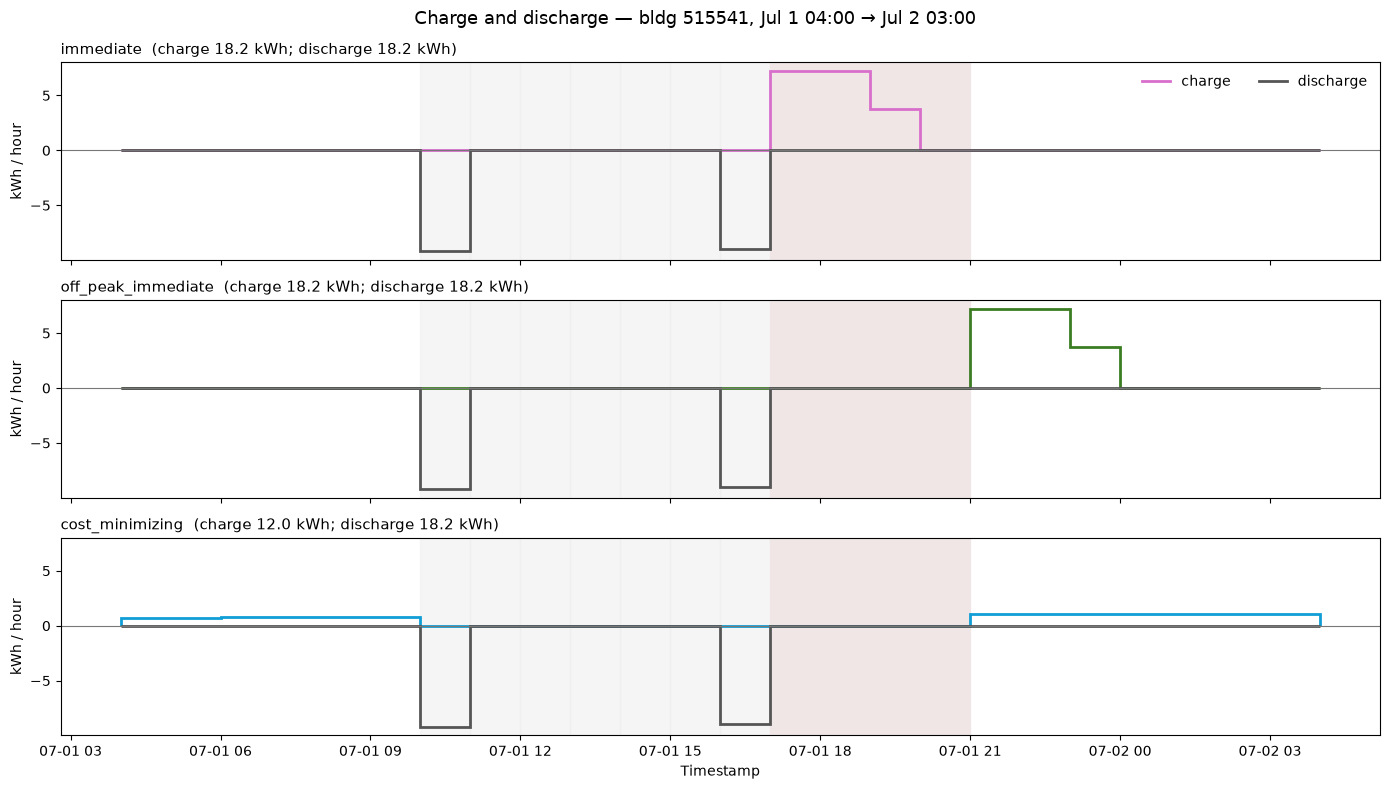

In [54]:
# Individual building: charge and discharge curves over one 24-hour travel day
fig, axes = plt.subplots(len(PLOT_STRATEGIES), 1, figsize=(14, 8), sharex=True, sharey=True)
fig.suptitle(
    f"Charge and discharge — bldg {DEMO_BLDG}, "
    f"{CHARGE_DAY_START:%b %-d %H:%M} → {CHARGE_DAY_END:%b %-d %H:%M}",
    fontsize=13,
)

for ax, strategy in zip(axes, PLOT_STRATEGIES, strict=True):
    day = (
        window_by_strategy[strategy]
        .filter(
            (pl.col("timestamp") >= CHARGE_DAY_START)
            & (pl.col("timestamp") <= CHARGE_DAY_END)
        )
        .sort("timestamp")
    )
    ts = day["timestamp"].to_numpy()
    edges = np.append(ts, ts[-1] + np.timedelta64(1, "h"))
    charge = day["charge_kwh"].to_numpy()
    discharge = day["discharge_kwh"].to_numpy()

    for i, t in enumerate(ts):
        if bool(day["is_peak"][i]):
            ax.axvspan(t, t + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)
        if not bool(day["at_home"][i]):
            ax.axvspan(
                t,
                t + np.timedelta64(1, "h"),
                color="#eeeeee",
                alpha=0.55,
                zorder=0,
            )

    ax.stairs(
        charge,
        edges,
        color=PLOT_COLORS[strategy],
        linewidth=2.0,
        label="charge",
        zorder=2,
    )
    ax.stairs(
        -discharge,
        edges,
        color=COLOR_DISCHARGE,
        linewidth=2.0,
        label="discharge",
        zorder=2,
    )
    ax.axhline(0, color="#777777", linewidth=0.8)
    ax.set_ylabel("kWh / hour")
    ax.set_title(
        f"{strategy}  (charge {charge.sum():.1f} kWh; "
        f"discharge {discharge.sum():.1f} kWh)",
        loc="left",
        fontsize=11,
    )

axes[0].legend(frameon=False, ncols=2, loc="upper right")
axes[-1].set_xlabel("Timestamp")
fig.tight_layout()
plt.show()


In [55]:
# Base residential electricity for July week:
#   1) ALL MD buildings
#   2) EV buildings only (same set as fleet charging)
# PATH_LOADS_DIR / ELEC_COL come from §11; fall back if that cell was skipped.
if "PATH_LOADS_DIR" not in globals():
    PATH_LOADS_DIR = (
        Path("/ebs/data/nrel/resstock")
        / "res_2024_amy2018_2_sb"
        / "load_curve_hourly"
        / f"state={STATE}"
        / "upgrade=00"
    )
if "ELEC_COL" not in globals():
    ELEC_COL = "out.electricity.total.energy_consumption"
if "COLOR_BASE" not in globals():
    COLOR_BASE = "#9AA0A6"

all_load_paths = sorted(PATH_LOADS_DIR.glob("*-0.parquet"))
ev_bldg_ids = ev_attributes["bldg_id"].unique().to_list()
ev_load_paths = [PATH_LOADS_DIR / f"{bid}-0.parquet" for bid in ev_bldg_ids]
missing_ev = [path for path in ev_load_paths if not path.exists()]
assert not missing_ev, (
    f"Missing load curves for {len(missing_ev)} EV buildings (e.g. {missing_ev[:3]})"
)

print(
    f"Loading July-week base residential from {PATH_LOADS_DIR}\n"
    f"  all buildings: {len(all_load_paths):,}\n"
    f"  EV buildings:  {len(ev_load_paths):,}"
)


def _july_week_base(paths: list[Path]) -> pl.DataFrame:
    """Sum ResStock electricity over paths for the July fleet window."""
    return (
        pl.scan_parquet(paths)
        .select("timestamp", pl.col(ELEC_COL).alias("base_elec_kwh"))
        .filter(
            (pl.col("timestamp") >= datetime(2018, 7, 1, 0, 0, 0))
            & (pl.col("timestamp") <= datetime(2018, 7, 8, 3, 0, 0))
        )
        .group_by("timestamp")
        .agg(pl.col("base_elec_kwh").sum())
        .sort("timestamp")
        .with_columns(
            pl.datetime(
                2024,
                pl.col("timestamp").dt.month(),
                pl.col("timestamp").dt.day(),
                pl.col("timestamp").dt.hour(),
            ).alias("timestamp"),
        )
        .collect()
        .filter(
            (pl.col("timestamp") >= FLEET_WINDOW_START)
            & (pl.col("timestamp") <= FLEET_WINDOW_END)
        )
        .sort("timestamp")
    )


base_all_buildings_week = _july_week_base(all_load_paths)
# Prefer §11 series when present (same EV set); otherwise build from EV load paths.
if "base_residential_week" in globals():
    base_ev_buildings_week = base_residential_week
else:
    base_ev_buildings_week = _july_week_base(ev_load_paths)

for label, frame, n_bldg in [
    ("all buildings", base_all_buildings_week, len(all_load_paths)),
    ("EV buildings", base_ev_buildings_week, len(ev_load_paths)),
]:
    print(
        f"{label}: hours={frame.height:,}  "
        f"mean={frame['base_elec_kwh'].mean():.0f} kWh/h  "
        f"max={frame['base_elec_kwh'].max():.0f} kWh/h  "
        f"(n={n_bldg:,})"
    )



Loading July-week base residential from /ebs/data/nrel/resstock/res_2024_amy2018_2_sb/load_curve_hourly/state=MD/upgrade=00
  all buildings: 9,995
  EV buildings:  178


all buildings: hours=168  mean=19179 kWh/h  max=30007 kWh/h  (n=9,995)
EV buildings: hours=168  mean=447 kWh/h  max=687 kWh/h  (n=178)


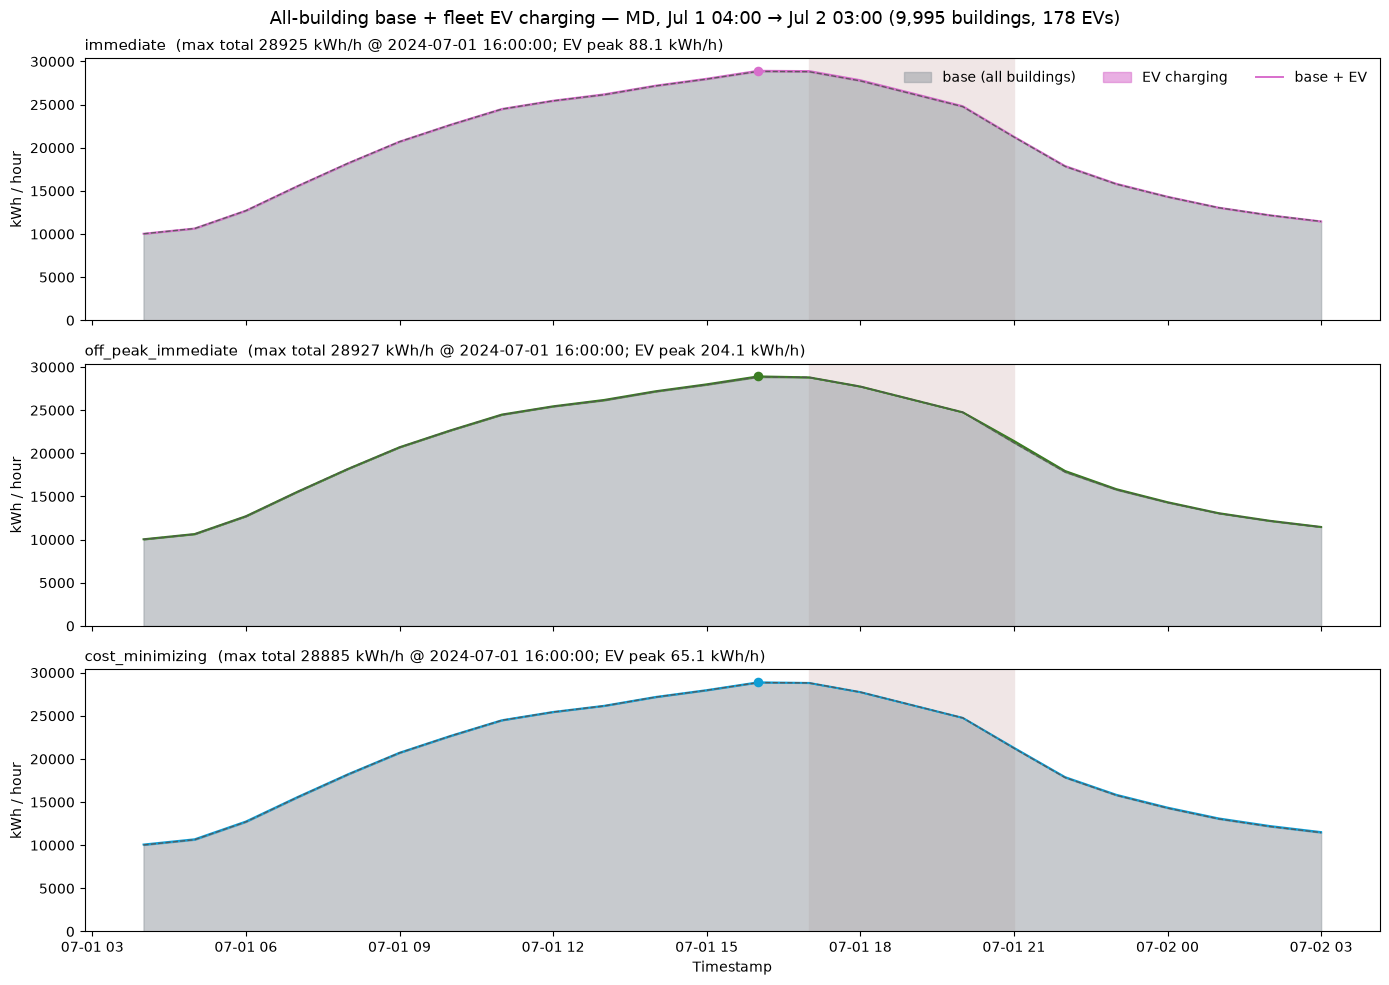

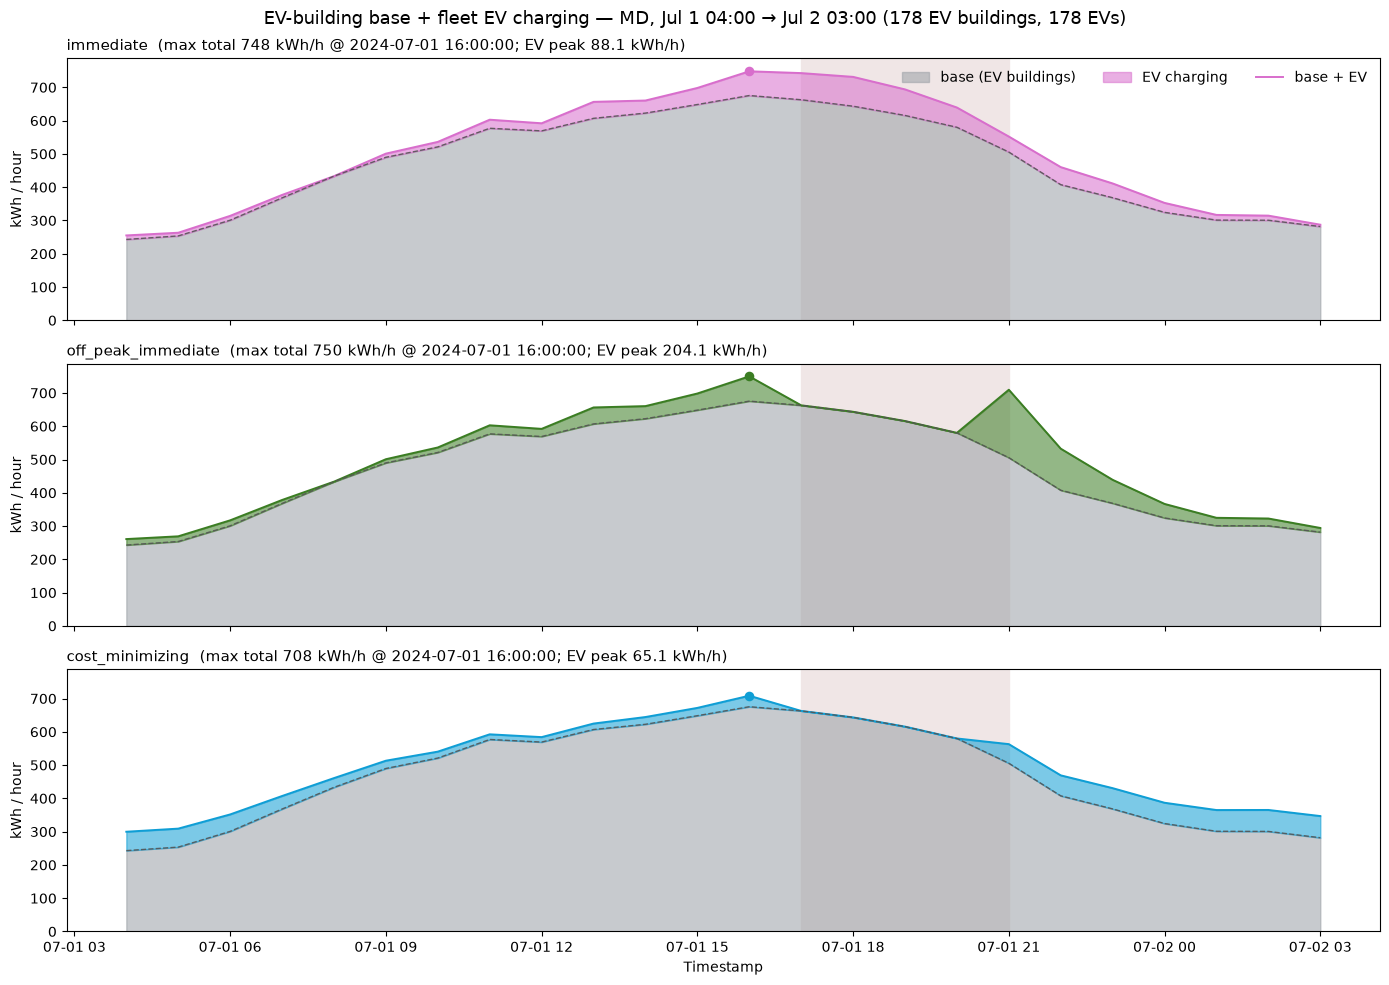

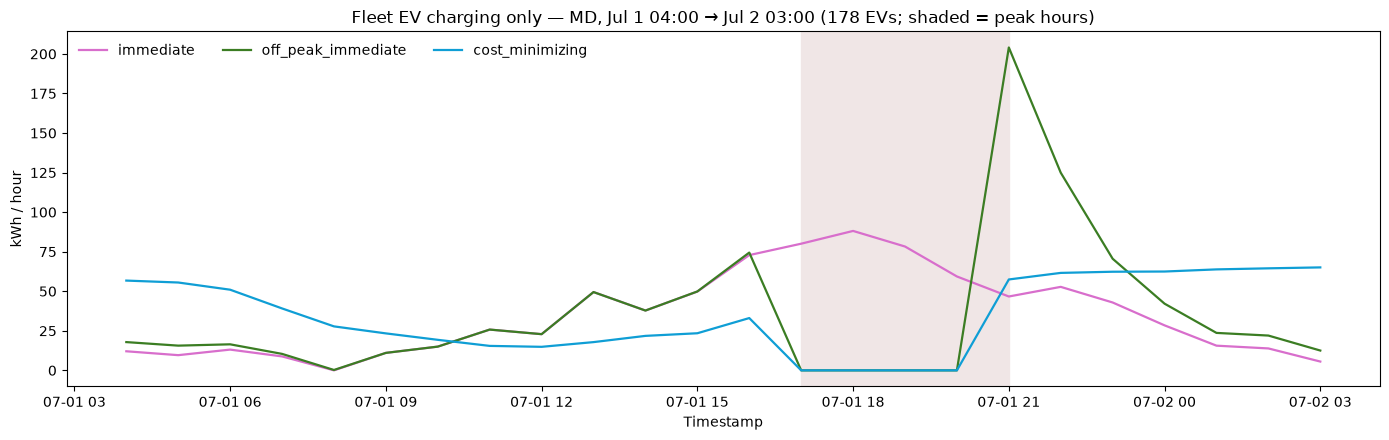

24-hour totals (Jul 1 04:00 → Jul 2 03:00) — base scopes × charging policies


scope,strategy,day_base_kwh,day_ev_kwh,day_total_kwh,day_ev_peak_hour_kwh,ev_share_of_total,max_hourly_ev_kwh,max_hourly_total_kwh
str,str,f64,f64,f64,f64,f64,f64,f64
"""all buildings""","""immediate""",483971.0,839.8,484811.0,305.8,0.0017,88.12,28925.1
"""all buildings""","""off_peak_immediate""",483971.0,846.7,484818.0,0.0,0.0017,204.07,28926.7
"""all buildings""","""cost_minimizing""",483971.0,836.5,484808.0,0.0,0.0017,65.07,28885.3
"""EV buildings""","""immediate""",11301.0,839.8,12140.0,305.8,0.0692,88.12,748.3
"""EV buildings""","""off_peak_immediate""",11301.0,846.7,12147.0,0.0,0.0697,204.07,749.9
"""EV buildings""","""cost_minimizing""",11301.0,836.5,12137.0,0.0,0.0689,65.07,708.5


In [56]:
# Aggregate: base + fleet EV charging under the three policies (same 24h travel day)
if "CHARGE_DAY_START" not in globals():
    CHARGE_DAY_START = FLEET_WINDOW_START
if "CHARGE_DAY_END" not in globals():
    CHARGE_DAY_END = CHARGE_DAY_START + timedelta(hours=23)

day_label = f"{CHARGE_DAY_START:%b %-d %H:%M} → {CHARGE_DAY_END:%b %-d %H:%M}"


def _slice_day(frame: pl.DataFrame) -> pl.DataFrame:
    return frame.filter(
        (pl.col("timestamp") >= CHARGE_DAY_START) & (pl.col("timestamp") <= CHARGE_DAY_END)
    ).sort("timestamp")


def plot_base_plus_ev(
    base_week: pl.DataFrame,
    *,
    title: str,
    base_label: str,
) -> dict[str, pl.DataFrame]:
    base_day = _slice_day(base_week)
    fig, axes = plt.subplots(len(PLOT_STRATEGIES), 1, figsize=(14, 10), sharex=True, sharey=True)
    fig.suptitle(title, fontsize=13)

    ymax = 0.0
    combined = {}
    for strategy in PLOT_STRATEGIES:
        load = (
            _slice_day(fleet_load_by_strategy[strategy])
            .join(base_day, on="timestamp", how="inner")
            .sort("timestamp")
            .with_columns(
                (pl.col("base_elec_kwh") + pl.col("fleet_charge_kwh")).alias("total_elec_kwh")
            )
        )
        combined[strategy] = load
        ymax = max(ymax, float(load["total_elec_kwh"].max()))
    ymax *= 1.05

    for ax, strategy in zip(axes, PLOT_STRATEGIES, strict=True):
        load = combined[strategy]
        ts = load["timestamp"].to_numpy()
        base = load["base_elec_kwh"].to_numpy()
        ev = load["fleet_charge_kwh"].to_numpy()
        total = load["total_elec_kwh"].to_numpy()

        for i, is_peak in enumerate(load["is_peak"].to_list()):
            if is_peak:
                ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)

        ax.fill_between(ts, 0, base, color=COLOR_BASE, alpha=0.55, label=base_label)
        ax.fill_between(
            ts, base, total, color=PLOT_COLORS[strategy], alpha=0.55, label="EV charging"
        )
        ax.plot(ts, total, color=PLOT_COLORS[strategy], linewidth=1.4, label="base + EV")
        ax.plot(ts, base, color="#555555", linewidth=1.0, linestyle="--", alpha=0.9)

        imax = int(np.argmax(total))
        ax.scatter([ts[imax]], [total[imax]], color=PLOT_COLORS[strategy], s=35, zorder=3)
        ax.set_ylim(0, ymax)
        ax.set_ylabel("kWh / hour")
        ax.set_title(
            f"{strategy}  (max total {total[imax]:.0f} kWh/h @ {load['timestamp'][imax]}; "
            f"EV peak {float(np.max(ev)):.1f} kWh/h)",
            loc="left",
            fontsize=11,
        )
        if strategy == PLOT_STRATEGIES[0]:
            ax.legend(frameon=False, ncols=3, loc="upper right")

    axes[-1].set_xlabel("Timestamp")
    fig.tight_layout()
    plt.show()
    return combined


combined_all = plot_base_plus_ev(
    base_all_buildings_week,
    title=(
        f"All-building base + fleet EV charging — {STATE}, {day_label} "
        f"({len(all_load_paths):,} buildings, {ev_attributes.height} EVs)"
    ),
    base_label="base (all buildings)",
)

combined_ev = plot_base_plus_ev(
    base_ev_buildings_week,
    title=(
        f"EV-building base + fleet EV charging — {STATE}, {day_label} "
        f"({ev_attributes['bldg_id'].n_unique():,} EV buildings, {ev_attributes.height} EVs)"
    ),
    base_label="base (EV buildings)",
)

# EV charging alone on the same 24h window (easier to see policy differences)
fig, ax = plt.subplots(figsize=(14, 4.5))
ref = _slice_day(fleet_load_by_strategy[PLOT_STRATEGIES[0]])
ts = ref["timestamp"].to_numpy()
for i, is_peak in enumerate(ref["is_peak"].to_list()):
    if is_peak:
        ax.axvspan(ts[i], ts[i] + np.timedelta64(1, "h"), color="#f0e6e6", zorder=0)
for strategy in PLOT_STRATEGIES:
    load = _slice_day(fleet_load_by_strategy[strategy])
    ax.plot(
        load["timestamp"].to_numpy(),
        load["fleet_charge_kwh"].to_numpy(),
        color=PLOT_COLORS[strategy],
        linewidth=1.6,
        label=strategy,
    )
ax.set_ylabel("kWh / hour")
ax.set_xlabel("Timestamp")
ax.set_title(
    f"Fleet EV charging only — {STATE}, {day_label} "
    f"({ev_attributes.height} EVs; shaded = peak hours)"
)
ax.legend(frameon=False, ncols=3)
fig.tight_layout()
plt.show()


def _day_summary(combined: dict[str, pl.DataFrame], scope: str) -> pl.DataFrame:
    rows = []
    for strategy in PLOT_STRATEGIES:
        load = combined[strategy]
        base_sum = float(load["base_elec_kwh"].sum())
        ev_sum = float(load["fleet_charge_kwh"].sum())
        peak_ev = float(load.filter(pl.col("is_peak"))["fleet_charge_kwh"].sum())
        rows.append({
            "scope": scope,
            "strategy": strategy,
            "day_base_kwh": round(base_sum, 0),
            "day_ev_kwh": round(ev_sum, 1),
            "day_total_kwh": round(base_sum + ev_sum, 0),
            "day_ev_peak_hour_kwh": round(peak_ev, 1),
            "ev_share_of_total": round(ev_sum / (base_sum + ev_sum), 4),
            "max_hourly_ev_kwh": round(float(load["fleet_charge_kwh"].max()), 2),
            "max_hourly_total_kwh": round(float(load["total_elec_kwh"].max()), 1),
        })
    return pl.DataFrame(rows)


summary = pl.concat([
    _day_summary(combined_all, "all buildings"),
    _day_summary(combined_ev, "EV buildings"),
])
print(f"24-hour totals ({day_label}) — base scopes × charging policies")
display(summary)
